# LLM Evaluation Framework

A **provider-agnostic RAG evaluation framework** benchmarked on HotpotQA.
Supports any OpenAI-compatible endpoint (OpenAI, Azure OpenAI, Ollama, Groq, Together AI, etc.).

**13 metrics** including RAGAS faithfulness and a novel 2-tier completeness cascade.

> See [README.md](../README.md) for full documentation and quickstart guide.


---
## Before You Run — Choose Your Setup Path

| | Google Colab | Local (Jupyter) |
|---|---|---|
| **Credentials** | Colab Secrets manager (key icon, left sidebar) | `.env` file (copy `.env.example → .env`) |
| **HotpotQA data** | Upload to Google Drive | Download to `./data/` folder |
| **Azure with IP restrictions** | ❌ Won't work — use local | ✓ Works |
| **OpenAI / Groq / Ollama** | ✓ Works | ✓ Works |

**Cell 2 auto-detects your environment** and loads credentials from the right source — no code changes needed.

### Colab Secrets to add (key icon → "Add new secret")

| Secret name | Example value |
|---|---|
| `OPENAI_API_KEY` | `sk-...` |
| `OPENAI_BASE_URL` | `https://api.openai.com/v1` |
| `OPENAI_API_VERSION` | `2025-04-01-preview` *(Azure only — leave blank for OpenAI)* |
| `OPENAI_GENERATION_MODEL` | `gpt-4o` |
| `OPENAI_EMBEDDING_MODEL` | `text-embedding-3-small` |
| `HOTPOTQA_DATA_PATH` | `/content/drive/MyDrive/data/hotpot_train_v1.1.json` |

> **HotpotQA data (Colab):** Upload `hotpot_train_v1.1.json` to your Google Drive at the path above.
> Download the file from [hotpotqa.github.io](https://hotpotqa.github.io/) → `hotpot_train_v1.1.json` (~500 MB).

### Local `.env` setup

```bash
cp .env.example .env
# Fill in your provider credentials — see docs/provider-setup.md
```

---

---
# 📦 CELL 1: Install Required Packages

This installs all dependencies needed for the enhanced RAG system.

**New packages added:**
- `rank-bm25`: For keyword search (hybrid retrieval)
- `sentence-transformers`: For groundedness/completeness checks

**Run this once per environment.**

In [3]:
# =============================================================================
# CELL 1: PACKAGE INSTALLATION
# =============================================================================

import sys
print("Installing required packages...")
print("This will take 2-3 minutes on first run...\n")

# Core packages
!pip install -q openai>=1.0.0 pandas numpy scikit-learn

# NLP & Metrics
!pip install -q sentence-transformers nltk rouge-score rank-bm25

# Visualization
!pip install -q matplotlib seaborn plotly

# Utils
!pip install -q tqdm python-dateutil

print("✓ All packages installed!\n")

# Download NLTK data (for sentence splitting)
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
print("✓ NLTK data downloaded")
print("\n" + "="*80)
print("✓ SETUP COMPLETE - Ready to proceed!")
print("="*80)

Installing required packages...
This will take 2-3 minutes on first run...

zsh:1: 1.0.0 not found
✓ All packages installed!

✓ NLTK data downloaded

✓ SETUP COMPLETE - Ready to proceed!


---
# 📚 CELL 2: Environment & Imports

Detects whether you are running in Google Colab or locally,
then loads credentials from the right source (Colab Secrets or `.env`).

In [4]:
# =============================================================================
# CELL 2: IMPORTS & ENVIRONMENT SETUP
# =============================================================================

import json
import os
import time
import pickle
import hashlib
from pathlib import Path
from typing import List, Dict, Any, Optional, Tuple
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from tqdm import tqdm
import random 

# ---------------------------------------------------------------------------
# Environment detection — Colab vs local
# ---------------------------------------------------------------------------
try:
    from google.colab import userdata, drive  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # -- Mount Google Drive (needed for HotpotQA data file) ------------------
    print('Mounting Google Drive...')
    drive.mount('/content/drive')

    def _colab_secret(key, default=''):
        try:
            return userdata.get(key) or default
        except Exception:
            return default

    # -- Load API credentials from Colab Secrets -----------------------------
    os.environ.setdefault('OPENAI_API_KEY',          _colab_secret('OPENAI_API_KEY'))
    os.environ.setdefault('OPENAI_BASE_URL',         _colab_secret('OPENAI_BASE_URL', 'https://api.openai.com/v1'))
    os.environ.setdefault('OPENAI_API_VERSION',      _colab_secret('OPENAI_API_VERSION', ''))
    os.environ.setdefault('OPENAI_GENERATION_MODEL', _colab_secret('OPENAI_GENERATION_MODEL', 'gpt-4o'))
    os.environ.setdefault('OPENAI_EMBEDDING_MODEL',  _colab_secret('OPENAI_EMBEDDING_MODEL', 'text-embedding-3-small'))
    os.environ.setdefault('EMBEDDING_CHOICE',        _colab_secret('EMBEDDING_CHOICE', 'small'))

    # -- Data path: reads from Secrets, falls back to standard Drive location -
    _default_data_path = '/content/drive/MyDrive/data/hotpot_train_v1.1.json'
    os.environ.setdefault('HOTPOTQA_DATA_PATH', _colab_secret('HOTPOTQA_DATA_PATH', _default_data_path))

    print('✓ Running in Google Colab')
    print(f'  Credentials : Colab Secrets')
    print(f'  Data path   : {os.environ["HOTPOTQA_DATA_PATH"]}')
    print(f'  Provider    : {"Azure OpenAI" if os.environ.get("OPENAI_API_VERSION") else "OpenAI-compatible"}')

else:
    from dotenv import load_dotenv
    load_dotenv()
    print('✓ Running locally')
    print(f'  Credentials : .env file')
    print(f'  Data path   : {os.environ.get("HOTPOTQA_DATA_PATH", "./data/hotpot_train_v1.1.json")}')
    print(f'  Provider    : {"Azure OpenAI" if os.environ.get("OPENAI_API_VERSION") else "OpenAI-compatible"}')

# OpenAI
from openai import OpenAI

# NLP & Metrics
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer
from rank_bm25 import BM25Okapi

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import platform

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

print('\n✓ All imports successful')

# =============================================================================
# WORKING DIRECTORY & CHECKPOINT FOLDER
# =============================================================================

if IN_COLAB:
    REPO_ROOT      = Path('/content/llm-eval-framework')
    CHECKPOINT_DIR = '/content/checkpoints'
    OUTPUT_DIR     = '/content/outputs'
else:
    NOTEBOOK_DIR   = Path().resolve()
    REPO_ROOT      = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
    CHECKPOINT_DIR = str(REPO_ROOT / 'checkpoints')
    OUTPUT_DIR     = str(REPO_ROOT / 'outputs')

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set working directory to repo root so all relative paths (./data/, etc.) resolve correctly
os.chdir(REPO_ROOT)

print('\n' + '=' * 70)
print('PATHS')
print('=' * 70)
print(f'Working directory : {REPO_ROOT}')
print(f'Checkpoint folder : {CHECKPOINT_DIR}')
print(f'Output folder     : {OUTPUT_DIR}')
print('=' * 70 + '\n')


✓ Running locally
  Credentials : .env file
  Data path   : ./data/hotpot_train_v1.1.json
  Provider    : Azure OpenAI

✓ All imports successful

PATHS
Working directory : /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework
Checkpoint folder : /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/checkpoints
Output folder     : /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs



---
# 📦 CELL 3: Load Framework Modules

All core classes live in `src/` — import them here.
Browse the source files for implementation details and inline documentation.

In [5]:
# =============================================================================
# CELL 3: FRAMEWORK IMPORTS
# =============================================================================

import sys, gc
from pathlib import Path

# Make src/ importable whether running from notebooks/ or repo root
_repo_root = Path().resolve()
if _repo_root.name == 'notebooks':
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from src.config          import Config
from src.metrics         import EvalMetrics
from src.vector_store    import VectorStore
from src.rag_system      import EnhancedRAGSystem
from src.cost_tracker    import CostTracker, CostConfig
from src.quality_guard   import QualityGuard
from src.investigator    import LowQualityInvestigator

print("✓ Framework modules loaded")
print(f"  Config            — provider: {'Azure OpenAI' if Config.API_VERSION else 'OpenAI-compatible'}")
print(f"  EvalMetrics       — 13 metrics including RAGAS faithfulness + completeness cascade")
print(f"  VectorStore       — BM25 + dense hybrid retrieval")
print(f"  EnhancedRAGSystem — temp=0.2, top-k=20, quality gates")
print(f"  CostTracker       — generation vs evaluation cost separation")
print(f"  QualityGuard      — real-time embedding-based quality gate")
print(f"  LowQualityInvestigator — 16-pattern classifier + k-means clustering")


✓ Framework modules loaded
  Config            — provider: Azure OpenAI
  EvalMetrics       — 13 metrics including RAGAS faithfulness + completeness cascade
  VectorStore       — BM25 + dense hybrid retrieval
  EnhancedRAGSystem — temp=0.2, top-k=20, quality gates
  CostTracker       — generation vs evaluation cost separation
  QualityGuard      — real-time embedding-based quality gate
  LowQualityInvestigator — 16-pattern classifier + k-means clustering


---
# ⚙️ CELL 4: Settings

Adjust these before running. Everything else (model names, embedding dimensions,
prompt templates, metric weights) is pre-configured in `src/config.py`.

| Variant | Intent | Best for |
|---------|--------|----------|
| `baseline` | Natural, unguided | Benchmarking LLM defaults |
| `concise` | Precision-first, minimal tokens | APIs, cost-sensitive apps |
| `detailed` | Comprehensive, self-contained | Support, education |
| `citation` | Attribution-enforced | Legal, medical, finance |

**Key design choices (see README for rationale):**
- Temperature **0.2** — biggest single driver of F1 and faithfulness on HotpotQA
- Top-K **20** — multi-hop questions need evidence from 2+ documents
- Hybrid retrieval **60/40** — BM25 catches entity names that embeddings miss
- Completeness **cascade** — LLM judge fires on ~20% of answers where embeddings are unreliable

In [6]:
# =============================================================================
# CELL 4: SETTINGS — adjust these before running
# =============================================================================

# ── Evaluation scope ─────────────────────────────────────────────────────────
Config.NUM_EVAL_QUESTIONS    = 100    # start small (10-50), scale to 2000
Config.RANDOM_SEED           = 42

# ── What to run ──────────────────────────────────────────────────────────────
Config.RUN_PROMPT_COMPARISON    = True   # evaluate all 4 prompt variants
Config.RUN_BASELINE_TEST        = True   # no-context baseline
Config.RUN_CORRELATION_ANALYSIS = True   # context quality vs answer quality

# ── Checkpointing ─────────────────────────────────────────────────────────────
Config.FORCE_RESTART              = False  # True → ignore eval checkpoint, start fresh
Config.FORCE_REBUILD_VECTOR_STORE = False  # True → rebuild vector store from scratch

# ── Quality gate thresholds (for flagging, not filtering) ────────────────────
Config.MIN_GROUNDEDNESS = 0.5
Config.MIN_COMPLETENESS = 0.4

print("✓ Settings configured")
print(f"  Questions  : {Config.NUM_EVAL_QUESTIONS}")
print(f"  Provider   : {'Azure OpenAI' if Config.API_VERSION else 'OpenAI-compatible'}")
print(f"  Embedding  : {Config.EMBEDDING_CHOICE} → {Config.EMBEDDING_MODEL}")
print(f"  Data path  : {Config.DATA_FILE_PATH}")
print(f"  Output dir : {Config.OUTPUT_DIR}")


✓ Settings configured
  Questions  : 100
  Provider   : Azure OpenAI
  Embedding  : small → text-embedding-3-small
  Data path  : data/hotpot_train_v1.1.json
  Output dir : ./outputs


---
# 🔌 CELL 5: Initialize LLM Clients

Provider is auto-detected from your `.env` (or Colab Secrets):
- `OPENAI_API_VERSION` **set** → `AzureOpenAI` client
- `OPENAI_API_VERSION` **blank** → `OpenAI` client (OpenAI direct, Ollama, Groq, etc.)

See `docs/provider-setup.md` for step-by-step setup for each provider.

In [7]:
# =============================================================================
# CELL 6: INITIALIZE LLM CLIENTS
# =============================================================================

import os
from openai import AzureOpenAI, OpenAI
from dotenv import load_dotenv

# Reload .env to pick up any changes without restarting the kernel
load_dotenv(override=True)

if Config.API_VERSION:
    # Azure OpenAI — build default_headers from env vars
    apim_header_name = os.environ.get("OPENAI_APIM_HEADER_NAME", "")
    apim_key         = os.environ.get("OPENAI_APIM_SUBSCRIPTION_KEY", "")
    extra_headers = {}
    if apim_header_name and apim_key:
        extra_headers[apim_header_name] = apim_key

    client = AzureOpenAI(
        api_key         = os.environ.get("OPENAI_API_KEY", Config.API_KEY),
        azure_endpoint  = os.environ.get("OPENAI_BASE_URL", Config.BASE_URL),
        api_version     = os.environ.get("OPENAI_API_VERSION", Config.API_VERSION),
        default_headers = extra_headers if extra_headers else None,
    )
    provider = "Azure OpenAI"
else:
    client = OpenAI(
        api_key  = os.environ.get("OPENAI_API_KEY", Config.API_KEY),
        base_url = os.environ.get("OPENAI_BASE_URL", Config.BASE_URL),
    )
    provider = "OpenAI-compatible"

# One client covers both generation and embeddings
embedding_client  = client
generation_client = client

print(f"✓ {provider} client initialized")
print(f"  Endpoint    : {os.environ.get('OPENAI_BASE_URL', Config.BASE_URL)}")
print(f"  Gen model   : {Config.GENERATION_MODEL}")
print(f"  Emb model   : {Config.EMBEDDING_MODEL}")
if Config.API_VERSION:
    print(f"  API version : {Config.API_VERSION}")
if extra_headers:
    for k in extra_headers:
        print(f"  Header sent : {k}")


✓ Azure OpenAI client initialized
  Endpoint    : https://your-gateway.example.com/YourGatewayPath
  Gen model   : gpt-4o
  Emb model   : text-embedding-3-small
  API version : 2025-04-01-preview
  Header sent : YourGatewayPath-Subscription-Key


In [8]:
# =============================================================================
# QUICK CLIENT TEST: Verify Both Embedding & Generation Clients
# =============================================================================

print("="*80)
print("🧪 QUICK CLIENT TEST")
print("="*80)
print("\nTesting both embedding_client and generation_client...")
print("="*80 + "\n")

# =============================================================================
# TEST 1: Embedding Client
# =============================================================================

print("TEST 1: Embedding Client")
print("-"*80)

try:
    print("Calling embedding API...")
    
    embedding_response = embedding_client.embeddings.create(
        input=["test"],
        model=Config.EMBEDDING_MODEL
    )
    
    print("✅ Embedding client works!")
    print(f"   Model: {Config.EMBEDDING_MODEL}")
    print(f"   Embedding dimensions: {len(embedding_response.data[0].embedding)}")
    print(f"   First 5 values: {embedding_response.data[0].embedding[:5]}")
    
except Exception as e:
    print("❌ Embedding client failed!")
    print(f"   Error: {e}")

print()

# =============================================================================
# TEST 2: Generation Client (WITHOUT temperature)
# =============================================================================

print("TEST 2: Generation Client (NO temperature)")
print("-"*80)

try:
    print("Calling generation API without temperature...")
    
    generation_response = generation_client.chat.completions.create(
        model=Config.GENERATION_MODEL,
        messages=[{"role": "user", "content": "Say 'hello' once."}],
        max_tokens=10
    )
    
    print("✅ Generation client works (no temperature)!")
    print(f"   Model: {Config.GENERATION_MODEL}")
    print(f"   Response: {generation_response.choices[0].message.content}")
    print(f"   Tokens used: {generation_response.usage.total_tokens}")
    
except Exception as e:
    print("❌ Generation client failed (no temperature)!")
    print(f"   Error: {e}")

print()

# =============================================================================
# TEST 3: Generation Client (WITH temperature)
# =============================================================================

print("TEST 3: Generation Client (WITH temperature)")
print("-"*80)

try:
    print("Calling generation API WITH temperature=0.2...")
    
    generation_response_temp = generation_client.chat.completions.create(
        model=Config.GENERATION_MODEL,
        messages=[{"role": "user", "content": "Say 'hello' once."}],
        max_tokens=10,
        temperature=0.2
    )
    
    print("✅ Generation client works WITH temperature!")
    print(f"   Model: {Config.GENERATION_MODEL}")
    print(f"   Response: {generation_response_temp.choices[0].message.content}")
    print(f"   Tokens used: {generation_response_temp.usage.total_tokens}")
    print()
    print("   → Temperature parameter IS supported!")
    
except Exception as e:
    print("❌ Generation client failed WITH temperature!")
    print(f"   Error: {e}")
    print()
    print("   → Temperature parameter NOT supported")

print()

# =============================================================================
# SUMMARY
# =============================================================================

print("="*80)
print("📋 TEST SUMMARY")
print("="*80)
print()
print("Configuration:")
print(f"  Endpoint:         {Config.BASE_URL}")
print(f"  API Version:      {Config.API_VERSION}")
print(f"  Embedding Model:  {Config.EMBEDDING_MODEL}")
print(f"  Generation Model: {Config.GENERATION_MODEL}")
print("="*80)

🧪 QUICK CLIENT TEST

Testing both embedding_client and generation_client...

TEST 1: Embedding Client
--------------------------------------------------------------------------------
Calling embedding API...
✅ Embedding client works!
   Model: text-embedding-3-small
   Embedding dimensions: 1536
   First 5 values: [-0.00986480712890625, 0.0015592575073242188, 0.0156707763671875, -0.0548095703125, -0.00640869140625]

TEST 2: Generation Client (NO temperature)
--------------------------------------------------------------------------------
Calling generation API without temperature...
✅ Generation client works (no temperature)!
   Model: gpt-4o
   Response: Hello.
   Tokens used: 16

TEST 3: Generation Client (WITH temperature)
--------------------------------------------------------------------------------
Calling generation API WITH temperature=0.2...
✅ Generation client works WITH temperature!
   Model: gpt-4o
   Response: Hello.
   Tokens used: 16

   → Temperature parameter IS suppo

---
# 📂 CELL 7: Load HotpotQA Data

Loads and samples the HotpotQA training set using **question-centric sampling**: the document library is built to guarantee every sampled question has its supporting documents included — no retrieval misses from missing documents.

> **Resource estimates (API embeddings, small model):**
>
> | Questions | Documents | Vector store build | Cost |
> |---|---|---|---|
> | 50 | ~5k | ~2 min | <$0.001 |
> | 500 | ~50k | ~45 min | ~$0.001 |
> | 2,000 | ~180k | ~3 hrs | ~$0.004 |
>
> Set `EMBEDDING_CHOICE=local` in `.env` for free local embeddings (no API cost, ~10% lower quality).

In [9]:
# =============================================================================
# CELL 8A: LOAD HOTPOTQA DATA
# =============================================================================

print("Loading HotpotQA data...")

# Load JSON data
with open(Config.DATA_FILE_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"✓ Loaded {len(data)} questions\n")

# Build document library (same as your original code)
print("Building document library...")
document_library = {}
doc_id = 0

for item in data:
    context = item.get('context', [])
    for doc_title, doc_sentences in context:
        # Join sentences into full paragraph
        full_doc = ' '.join(doc_sentences)
        
        document_library[doc_id] = {
            'title': doc_title,
            'content': full_doc,
            'sentences': doc_sentences,
            'doc_id': doc_id
        }
        doc_id += 1

# Save a copy of questions before they get overwritten
hotpot_questions = data.copy() 

print(f"✓ Built library with {len(document_library):,} documents")
print(f"  Average document length: {np.mean([len(d['content']) for d in document_library.values()]):.0f} chars")

Loading HotpotQA data...
✓ Loaded 90447 questions

Building document library...
✓ Built library with 899,667 documents
  Average document length: 546 chars


In [10]:
# =============================================================================
# CELL 8B: QUESTION-CENTRIC SAMPLING
# =============================================================================

from difflib import SequenceMatcher

def fuzzy_match_title(query_title, available_titles, threshold=0.85):
    """Find best matching title using fuzzy matching."""
    query_lower = query_title.lower().strip()
    
    best_match = None
    best_score = 0
    
    for title in available_titles:
        title_lower = title.lower().strip()
        
        # Exact match
        if query_lower == title_lower:
            return title, 1.0
        
        # Substring match
        if query_lower in title_lower or title_lower in query_lower:
            score = min(len(query_lower), len(title_lower)) / max(len(query_lower), len(title_lower))
            if score > best_score:
                best_score = score
                best_match = title
        
        # Fuzzy match
        similarity = SequenceMatcher(None, query_lower, title_lower).ratio()
        if similarity > best_score and similarity >= threshold:
            best_score = similarity
            best_match = title
    
    return best_match, best_score

print("="*80)
print("DATASET SAMPLING (QUESTION-CENTRIC)")
print("="*80)

USE_SAMPLING = Config.USE_SAMPLING
NUM_QUESTIONS = Config.NUM_EVAL_QUESTIONS
random.seed(Config.RANDOM_SEED)

if USE_SAMPLING:
    print(f"\n📊 Question-centric sampling")
    print(f"   Target: {NUM_QUESTIONS:,} questions")
    print(f"   Source: {len(data):,} questions, {len(document_library):,} docs")
    
    # Diagnostic: Check data structure
    print(f"\n🔍 Data check:")
    print(f"   Type: {type(data)}")
    print(f"   Length: {len(data):,}")
    if len(data) > 0:
        sample_item = data[0]
        print(f"   Has 'context': {'context' in sample_item}")
        if 'context' in sample_item:
            print(f"   Sample context length: {len(sample_item['context'])} docs")
    
    # Step 1: Sample questions
    sampled_questions = random.sample(data, min(NUM_QUESTIONS, len(data)))
    print(f"\n✓ Sampled {len(sampled_questions):,} questions")
    
    # Step 2: Collect needed document titles FROM SAMPLED QUESTIONS ONLY
    needed_titles = set()
    for item in sampled_questions:
        if 'context' in item:
            for title, sentences in item['context']:
                needed_titles.add(title)
    
    print(f"✓ Sampled questions need {len(needed_titles):,} unique documents")
    print(f"   Expected: ~{len(sampled_questions) * 10:,} (10 docs/question)")
    
    # ⭐ SANITY CHECK
    if len(needed_titles) > len(sampled_questions) * 10:
        print(f"\n⚠️  WARNING: {len(needed_titles):,} titles for {len(sampled_questions):,} questions is unusually high!")
        print(f"   Expected: ~{len(sampled_questions) * 10:,} titles")
        print(f"   Check: Are you collecting from the RIGHT data?")
    
    # Step 3: Build title index
    title_to_doc = {}
    available_titles = []
    for doc_id, doc in document_library.items():
        doc_title = doc['title']
        title_to_doc[doc_title] = (doc_id, doc)
        available_titles.append(doc_title)
    
    print(f"✓ Indexed {len(available_titles):,} available documents")
    
    # Step 4: Match needed titles to available documents
    print(f"\n🔍 Matching titles...")
    sampled_document_library = {}
    title_mapping = {}
    found_count = 0
    missing_titles = []
    fuzzy_matches = []
    
    for needed_title in needed_titles:
        # Try exact match
        if needed_title in title_to_doc:
            doc_id, doc = title_to_doc[needed_title]
            sampled_document_library[doc_id] = doc
            title_mapping[needed_title] = needed_title
            found_count += 1
        else:
            # Try fuzzy match
            matched_title, score = fuzzy_match_title(needed_title, available_titles)
            
            if matched_title and score >= 0.85:
                doc_id, doc = title_to_doc[matched_title]
                sampled_document_library[doc_id] = doc
                title_mapping[needed_title] = matched_title
                found_count += 1
                
                if score < 1.0:
                    fuzzy_matches.append({
                        'needed': needed_title,
                        'found': matched_title,
                        'score': score
                    })
            else:
                missing_titles.append(needed_title)
    
    print(f"✓ Found {found_count:,} / {len(needed_titles):,} documents ({found_count/len(needed_titles)*100:.1f}%)")
    
    if fuzzy_matches:
        print(f"   Fuzzy matches: {len(fuzzy_matches)}")
    
    if missing_titles:
        print(f"   ⚠️  Missing: {len(missing_titles):,} ({missing_titles[:3]})")
    
    # Step 5: Filter questions with complete context
    print(f"\n🎯 Filtering questions...")
    final_questions = []
    questions_dropped = 0
    
    for item in sampled_questions:
        if 'context' in item:
            question_titles = {title for title, _ in item['context']}
            all_found = all(title in title_mapping for title in question_titles)
            
            if all_found:
                final_questions.append(item)
            else:
                questions_dropped += 1
    
    print(f"✓ Kept {len(final_questions):,} questions with complete context")
    if questions_dropped > 0:
        print(f"   Dropped {questions_dropped} questions with missing docs")
    
    # Save original for comparison
    hotpot_questions = final_questions.copy()
    
    # Replace globals
    document_library = sampled_document_library
    data = final_questions
    
    print("\n" + "="*80)
    print("SAMPLING COMPLETE")
    print("="*80)
    print(f"  Questions:       {len(data):,}")
    print(f"  Documents:       {len(document_library):,}")
    print(f"  Docs/Question:   {len(document_library)/len(data):.1f}")
    print(f"  Expected ratio:  ~8-10 docs/question")
    print(f"  Match rate:      {found_count/len(needed_titles)*100:.1f}%")
    print(f"  Seed:            {Config.RANDOM_SEED}")
    print("="*80 + "\n")
    
    # ⭐ FINAL SANITY CHECK
    if len(document_library) > len(data) * 10:
        print("⚠️  WARNING: Document count seems too high!")
        print(f"   {len(document_library):,} docs for {len(data):,} questions")
        print(f"   Expected: ~{len(data) * 3:,} docs (3 per question)")
        print(f"   Something may be wrong with sampling!")
        print()

else:
    print("\n✓ Using full dataset")
    print(f"  Questions: {len(data):,}")
    print(f"  Documents: {len(document_library):,}\n")
    
    # Save copy
    hotpot_questions = data.copy()

DATASET SAMPLING (QUESTION-CENTRIC)

📊 Question-centric sampling
   Target: 100 questions
   Source: 90,447 questions, 899,667 docs

🔍 Data check:
   Type: <class 'list'>
   Length: 90,447
   Has 'context': True
   Sample context length: 10 docs

✓ Sampled 100 questions
✓ Sampled questions need 999 unique documents
   Expected: ~1,000 (10 docs/question)
✓ Indexed 899,667 available documents

🔍 Matching titles...
✓ Found 999 / 999 documents (100.0%)

🎯 Filtering questions...
✓ Kept 100 questions with complete context

SAMPLING COMPLETE
  Questions:       100
  Documents:       999
  Docs/Question:   10.0
  Expected ratio:  ~8-10 docs/question
  Match rate:      100.0%
  Seed:            42



---
## Embedding Model Validation

Verifies your embedding model is reachable and estimates vector store build time.

In [11]:
# =============================================================================
# CELL 8C: TEST EMBEDDING MODEL & ESTIMATE BUILD TIME
# =============================================================================

print("="*80)
print("EMBEDDING MODEL VALIDATION & TIME ESTIMATE")
print("="*80)

num_documents = len(document_library)
print(f"\nDataset: {num_documents:,} documents\n")

# =========================================================================
# Test Selected Embedding Model
# =========================================================================

print(f"Testing selected model: {Config.EMBEDDING_CHOICE.upper()}")
print("-"*80)

if Config.EMBEDDING_PROVIDER == "api":
    print(f"Model: {Config.EMBEDDING_MODEL}")
    print("Testing API connection...\n")
    try:
        test_response = embedding_client.embeddings.create(
            input=["Test sentence for validation"],
            model=Config.EMBEDDING_MODEL
        )
        dims = len(test_response.data[0].embedding)
        print(f"✅ Model '{Config.EMBEDDING_MODEL}' is AVAILABLE!")
        print(f"   Dimensions: {dims}")
        if dims != Config.EMBEDDING_DIMENSIONS:
            print(f"   ⚠️  Dimension mismatch! Using {dims} instead of {Config.EMBEDDING_DIMENSIONS}")
    except Exception as e:
        print(f"❌ Model '{Config.EMBEDDING_MODEL}' is NOT AVAILABLE!")
        print(f"   Error: {e}")
        raise

elif Config.EMBEDDING_PROVIDER == "local":
    print(f"Model: {Config.EMBEDDING_MODEL}")
    print("Loading local SentenceTransformer model...\n")
    try:
        from sentence_transformers import SentenceTransformer
        test_model = SentenceTransformer(Config.EMBEDDING_MODEL)
        test_embedding = test_model.encode(["Test sentence"])
        dims = len(test_embedding[0])
        print(f"✅ Local model '{Config.EMBEDDING_MODEL}' loaded successfully!")
        print(f"   Dimensions: {dims}")
        del test_model
    except Exception as e:
        print(f"❌ Failed to load local model: {e}")
        raise

print()

# =========================================================================
# Time & Cost Estimate
# =========================================================================

print("="*80)
print("TIME ESTIMATE FOR VECTOR STORE BUILD")
print("="*80)

estimate = Config.estimate_embedding_time(num_documents)

print(f"\nSelected Model: {estimate['model']}")
print(f"Provider      : {estimate['provider']}")
print(f"Bottleneck    : {estimate['bottleneck']}")
print()
print(f"📊 Estimated build time : {estimate['total_time_formatted']}")
print(f"💰 Estimated cost       : ${estimate['cost_usd']:.4f}")

if estimate['quota_limited']:
    print(f"\n⚠️  Quota-limited — most time is waiting for quota reset, not actual work.")
    if 'cycles_needed' in estimate:
        print(f"   Cycles needed: {estimate['cycles_needed']}")
else:
    print("\n✅ No quota limits — continuous embedding, no waits.")

# =========================================================================
# Comparison Table
# =========================================================================

print()
print("="*80)
print("COMPARISON: ALL EMBEDDING OPTIONS")
print("="*80)
print(f"\n{'Option':<8} {'Model':<30} {'Time':<12} {'Cost':<10} {'Quota'}")
print("-"*70)

for choice in ["large", "small", "local"]:
    original = Config.EMBEDDING_CHOICE
    Config.EMBEDDING_CHOICE = choice
    est = Config.estimate_embedding_time(num_documents)
    Config.EMBEDDING_CHOICE = original

    marker = "→" if choice == Config.EMBEDDING_CHOICE else " "
    print(f"{marker} {choice:<6} {est['model']:<30} {est['total_time_formatted']:<12} "
          f"${est['cost_usd']:.4f}    {'Yes' if est['quota_limited'] else 'No'}")

print()
print(f"Currently selected: {Config.EMBEDDING_CHOICE.upper()}")
print("To change: update EMBEDDING_CHOICE in Cell 4, re-run from there.")
print("="*80)
print("\n✅ Embedding model validated.")


EMBEDDING MODEL VALIDATION & TIME ESTIMATE

Dataset: 999 documents

Testing selected model: SMALL
--------------------------------------------------------------------------------
Model: text-embedding-3-small
Testing API connection...

✅ Model 'text-embedding-3-small' is AVAILABLE!
   Dimensions: 1536

TIME ESTIMATE FOR VECTOR STORE BUILD

Selected Model: text-embedding-3-small
Provider      : API
Bottleneck    : TPM quota (240,000)

📊 Estimated build time : 7m 56s
💰 Estimated cost       : $0.0040

⚠️  Quota-limited — most time is waiting for quota reset, not actual work.
   Cycles needed: 0

COMPARISON: ALL EMBEDDING OPTIONS

Option   Model                          Time         Cost       Quota
----------------------------------------------------------------------
  large  text-embedding-3-small         15m 52s      $0.0260    Yes
→ small  text-embedding-3-small         7m 56s       $0.0040    Yes
  local  all-mpnet-base-v2              19s          $0.0000    No

Currently selected: 

---
# 🏗️ CELL 9: Build Vector Store

Builds **hybrid retrieval** — semantic (dense embeddings) + keyword (BM25) — with adaptive checkpointing so a long build can be safely interrupted and resumed.

| Strategy | Weight | Strength |
|---|---|---|
| Dense (embedding) | 60% | Semantic similarity, paraphrase matching |
| Sparse (BM25) | 40% | Exact entity names, dates, proper nouns |

> ⚠️ **First run takes 2–45 minutes** depending on dataset size and embedding provider.  
> Subsequent runs load from cache instantly (`FORCE_REBUILD_VECTOR_STORE = False`).

In [12]:
# =============================================================================
# CELL 10B: LOAD OR BUILD VECTOR STORE (WITH DOC ID VALIDATION)
# =============================================================================

print("="*80)
print("VECTOR STORE: LOAD OR BUILD")
print("="*80)

# Configuration
FORCE_REBUILD = Config.FORCE_REBUILD_VECTOR_STORE

# Get documents list
documents_list = list(document_library.values())
num_docs = len(documents_list)

print(f"\n📊 Dataset Info:")
print(f"   Documents to embed: {num_docs:,}")
print(f"   Embedding model:    {Config.EMBEDDING_MODEL}")
print(f"   Embedding provider: {Config.EMBEDDING_PROVIDER}")
print(f"   Dimensions:         {Config.EMBEDDING_DIMENSIONS}")
print(f"   Force rebuild:      {'YES (ignoring cache)' if FORCE_REBUILD else 'NO (will use cache if available)'}")

# File paths
vector_store_file = f'vector_store_{num_docs}_docs_{Config.EMBEDDING_CHOICE}.pkl'
checkpoint_file = f'checkpoint_{num_docs}_docs_{Config.EMBEDDING_CHOICE}.pkl'

print(f"\n📁 Files:")
print(f"   Vector store: {vector_store_file}")
print(f"   Checkpoint:   {checkpoint_file}")

# =====================================================================
# CACHE VALIDATION WITH DOCUMENT ID CHECK
# =====================================================================

cache_valid = False
load_from_cache = False

if os.path.exists(vector_store_file) and not FORCE_REBUILD:
    print("\n" + "="*80)
    print("🔍 FOUND EXISTING VECTOR STORE CACHE")
    print("="*80)
    print(f"File: {vector_store_file}\n")
    
    try:
        import pickle
        
        print("Validating cache...")
        
        # Load cache
        with open(vector_store_file, 'rb') as f:
            cache_data = pickle.load(f)
        
        cache_valid = True
        issues = []
        
        # Check 1: Document count
        if len(cache_data['documents']) != num_docs:
            issues.append(f"Document count: cache has {len(cache_data['documents']):,}, need {num_docs:,}")
            cache_valid = False
        
        # Check 2: Model name
        cache_model = cache_data.get('model', 'unknown')
        if cache_model != Config.EMBEDDING_MODEL:
            issues.append(f"Model: cache has '{cache_model}', need '{Config.EMBEDDING_MODEL}'")
            cache_valid = False
        
        # Check 3: Embedding dimensions
        cache_dims = cache_data['embeddings'].shape[1]
        if cache_dims != Config.EMBEDDING_DIMENSIONS:
            issues.append(f"Dimensions: cache has {cache_dims}, need {Config.EMBEDDING_DIMENSIONS}")
            cache_valid = False
        
        # Check 4: Document IDs match (CRITICAL FOR RE-SAMPLING)
        if cache_valid:  # Only check if previous checks passed
            print("   Checking document IDs...")
            
            # Extract doc IDs from cache
            cached_doc_ids = {meta['doc_id'] for meta in cache_data['metadata']}
            
            # Extract doc IDs from current documents
            current_doc_ids = {doc['doc_id'] for doc in documents_list}
            
            # Compare
            if cached_doc_ids == current_doc_ids:
                print("   ✓ Document IDs match (same documents)")
            else:
                # Calculate overlap
                overlap = len(cached_doc_ids & current_doc_ids)
                overlap_pct = overlap / len(current_doc_ids) * 100
                
                issues.append(f"Document IDs: {overlap:,}/{num_docs:,} match ({overlap_pct:.1f}%)")
                cache_valid = False
                
                # Show sample of mismatches
                missing_in_cache = current_doc_ids - cached_doc_ids
                extra_in_cache = cached_doc_ids - current_doc_ids
                
                if missing_in_cache:
                    sample_missing = list(missing_in_cache)[:3]
                    issues.append(f"  Missing from cache: {len(missing_in_cache):,} docs (e.g., {sample_missing})")
                if extra_in_cache:
                    sample_extra = list(extra_in_cache)[:3]
                    issues.append(f"  Extra in cache: {len(extra_in_cache):,} docs (e.g., {sample_extra})")
        
        # Display validation results
        if cache_valid:
            print("\n✅ CACHE VALID - Loading from disk\n")
            print("Cache Details:")
            print(f"  Model: {cache_model}")
            print(f"  Documents: {len(cache_data['documents']):,}")
            print(f"  Dimensions: {cache_dims}")
            
            # Show file info
            file_size = os.path.getsize(vector_store_file) / (1024**2)
            print(f"  Size: {file_size:.1f} MB")
            
            timestamp = cache_data.get('timestamp', 0)
            print(f"  Created: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(timestamp))}")
            
            print("="*80)
            print("✅ LOADING FROM CACHE (skipping embedding!)")
            print("="*80 + "\n")
            
            load_from_cache = True
            
        else:
            print("\n❌ CACHE INVALID - Cannot use\n")
            print("Issues found:")
            for issue in issues:
                print(f"  • {issue}")
            print(f"\n🔄 Cache will be ignored and rebuilt")
            print(f"   (Old cache file will be kept for safety)\n")
    
    except Exception as e:
        print(f"\n⚠️  Error loading cache: {e}")
        print(f"   Building new vector store...\n")
        cache_valid = False
        load_from_cache = False

elif os.path.exists(vector_store_file) and FORCE_REBUILD:
    print("\n" + "="*80)
    print("🔄 CACHE FOUND BUT FORCE_REBUILD=True")
    print("="*80)
    print(f"   Ignoring cache and rebuilding...")
    print(f"   (Cache will be overwritten)\n")
    load_from_cache = False

else:
    print("\n" + "="*80)
    print("🔨 NO CACHE FOUND - Building new vector store")
    print("="*80 + "\n")
    load_from_cache = False

# =====================================================================
# LOAD FROM CACHE OR BUILD NEW
# =====================================================================

start_time = time.time()

if load_from_cache:
    # Create vector store instance
    vector_store = VectorStore(
        embedding_client=embedding_client,  # ← Passed to __init__
        embedding_model=Config.EMBEDDING_MODEL,
        config=Config
    )
    
    # Load cached data
    vector_store.embeddings = cache_data['embeddings']
    vector_store.documents = cache_data['documents']
    vector_store.metadata = cache_data['metadata']
    vector_store.tokenized_docs = cache_data['tokenized_docs']
    vector_store.bm25 = cache_data['bm25']
    
    # ⭐ CRITICAL: Explicitly re-inject client after cache load
    # Pickle cannot serialize client objects, so we must ensure it's set
    client_ok = vector_store.set_clients(embedding_client)
    
    if client_ok:
        print(f"✓ Loaded {len(vector_store.documents):,} documents")
        print(f"  Embedding dimensions: {vector_store.embeddings.shape}")
        print(f"  Embedding client: ✓ Verified working")
        print(f"  Ready for RAG evaluation!\n")
    else:
        print(f"✓ Loaded {len(vector_store.documents):,} documents")
        print(f"  Embedding dimensions: {vector_store.embeddings.shape}")
        print(f"  ⚠️  Warning: Client verification failed (manual fix may be needed)")
        print(f"  Ready for RAG evaluation!\n")


else:
    # Build new vector store
    if not FORCE_REBUILD and os.path.exists(vector_store_file):
        print("="*80)
        print("🔨 REBUILDING VECTOR STORE (cache invalid)")
        print("="*80 + "\n")
    
    vector_store = VectorStore(
        embedding_client=embedding_client,
        embedding_model=Config.EMBEDDING_MODEL,
        config=Config
    )
    
    # Build embeddings
    vector_store.add_documents(documents_list, checkpoint_file)
    
    # Save cache
    print(f"\n💾 Saving vector store to cache...")
    vector_store.save(vector_store_file)
    
    # Clean up checkpoint files
    import glob
    checkpoint_pattern = checkpoint_file.replace('.pkl', '*')
    for old_checkpoint in glob.glob(checkpoint_pattern):
        try:
            os.remove(old_checkpoint)
            print(f"   ✓ Removed checkpoint: {os.path.basename(old_checkpoint)}")
        except:
            pass
    
    print()

elapsed_time = (time.time() - start_time) / 60

# =====================================================================
# FINAL STATUS
# =====================================================================

print("="*80)
print("✅ VECTOR STORE READY")
print("="*80)
print(f"  Documents:         {len(vector_store.documents):,}")
print(f"  Embeddings shape:  {vector_store.embeddings.shape}")
print(f"  Embedding model:   {Config.EMBEDDING_MODEL}")
print(f"  Retrieval strategy: {Config.RETRIEVAL_STRATEGY}")
print(f"  Top-K:             {Config.TOP_K}")
print(f"  Load/Build time:   {elapsed_time:.1f} minutes")
print("="*80 + "\n")

VECTOR STORE: LOAD OR BUILD

📊 Dataset Info:
   Documents to embed: 999
   Embedding model:    text-embedding-3-small
   Embedding provider: api
   Dimensions:         1536
   Force rebuild:      NO (will use cache if available)

📁 Files:
   Vector store: vector_store_999_docs_small.pkl
   Checkpoint:   checkpoint_999_docs_small.pkl

🔍 FOUND EXISTING VECTOR STORE CACHE
File: vector_store_999_docs_small.pkl

Validating cache...
   Checking document IDs...
   ✓ Document IDs match (same documents)

✅ CACHE VALID - Loading from disk

Cache Details:
  Model: text-embedding-3-small
  Documents: 999
  Dimensions: 1536
  Size: 13.7 MB
  Created: 2026-05-21 16:45:44
✅ LOADING FROM CACHE (skipping embedding!)

✓ Loaded 999 documents
  Embedding dimensions: (999, 1536)
  Embedding client: ✓ Verified working
  Ready for RAG evaluation!

✅ VECTOR STORE READY
  Documents:         999
  Embeddings shape:  (999, 1536)
  Embedding model:   text-embedding-3-small
  Retrieval strategy: hybrid
  Top-K:   

---
# 🤖 CELL 10: RAG System — Instantiate & Quick Test

Creates the `EnhancedRAGSystem` and runs 3 questions end-to-end to confirm the full pipeline works before committing to the full evaluation.

**Pipeline:** question → hybrid retrieval (top-20 docs) → context truncation → LLM generation (temp=0.2) → QualityGuard validation → answer + metrics

In [13]:
# =============================================================================
# CELL 10: INSTANTIATE RAG SYSTEM & QUICK SANITY TEST
# =============================================================================

# Memory optimisation for large vector stores
sys.setrecursionlimit(50000)
gc.set_threshold(700, 15, 15)

quality_guard = QualityGuard(
    embedding_client=embedding_client,
    embedding_model=Config.EMBEDDING_MODEL,
    config=Config,
)

rag_system = EnhancedRAGSystem(
    vector_store=vector_store,
    generation_client=generation_client,
    quality_guard=quality_guard,
    config=Config,
)
print("\u2713 RAG system ready")
print(f"  Temperature : {Config.TEMPERATURE}")
print(f"  Top-K       : {Config.TOP_K}")
print(f"  Retrieval   : {Config.RETRIEVAL_STRATEGY} "
      f"({Config.HYBRID_SEMANTIC_WEIGHT:.0%} semantic / "
      f"{Config.HYBRID_KEYWORD_WEIGHT:.0%} keyword)")

# ── Quick sanity test — 3 questions ─────────────────────────────────────────
print("\nRunning quick sanity test (3 questions)...")
print("=" * 70)

for i, q_data in enumerate(data[:3], 1):
    question = q_data['question']
    gold     = q_data['answer']
    answer, docs, quality_metrics = rag_system.answer_question(question)
    f1_raw = EvalMetrics.calculate_f1(answer, gold)
    f1       = float(f1_raw[0]) if isinstance(f1_raw, tuple) else float(f1_raw)
    grounded = quality_metrics.get('groundedness', 0)
    grounded = float(grounded[0]) if isinstance(grounded, (tuple, list)) else float(grounded)
    print(f"\n[{i}] {question}")
    print(f"  Answer : {answer[:120]}")
    print(f"  Gold   : {gold}")
    print(f"  F1={f1:.2f}  Grounded={grounded:.2f}")

print("\n" + "=" * 70)
print("\u2713 Sanity test complete — if answers look reasonable, proceed to Cell 11")


✓ RAG system ready
  Temperature : 0.2
  Top-K       : 20
  Retrieval   : hybrid (60% semantic / 40% keyword)

Running quick sanity test (3 questions)...

[1] Which Emmett's Mark actor also played in the HBO series "The Wire"?
  Answer : John Doman
  Gold   : John Doman
  F1=1.00  Grounded=0.67

[2] Who directed the upcoming British action comedy film which has Johnny English as the first part? 
  Answer : David Kerr
  Gold   : David Kerr
  F1=1.00  Grounded=0.30

[3] What conference has the most valuable NBA franchise according to Forbes?
  Answer : Eastern Conference
  Gold   : Western Conference
  F1=0.50  Grounded=0.57

✓ Sanity test complete — if answers look reasonable, proceed to Cell 11


---
# 📊 Metrics & Quality Framework Reference

## 13 Evaluation Metrics

| # | Metric | Method | Cost |
|---|--------|--------|------|
| 1 | **Exact Match** | Token normalization | Free |
| 2 | **F1 Score** | Bag-of-words overlap | Free |
| 3 | **Contains Match** | Gold answer substring in prediction | Free |
| 4 | **ROUGE-L** | Longest common subsequence | Free |
| 5 | **Answer Relevance** | cosine_sim(answer, question) | Embedding |
| 6 | **Context Relevance** | cosine_sim(context, question) | Embedding |
| 7 | **Groundedness** | MiniMax avg_i max_j sim(ans_sent_i, ctx_sent_j) | Embedding |
| 8 | **RAGAS Faithfulness** | Atomic claim extraction → LLM entailment | LLM |
| 9 | **Completeness** | 2-tier cascade (see below) | Embedding + conditional LLM |
| 10 | **Conciseness** | Length penalty vs question length | Free |
| 11 | **Refusal Detection** | Phrase-pattern regex | Free |
| 12 | **SNR** | Ratio of context-grounded tokens | Free |
| 13 | **Quality Score** | Weighted composite | — |

## Completeness Cascade

```
Every answer
    │
    ▼
Tier 1 — Embedding (always runs)
    │  Filter context by cosine sim to question
    │  Score = avg_i max_j sim(relevant_ctx_i, answer_sent_j)
    │
    ├── Trigger B: |completeness − groundedness| > 0.3
    │              |completeness − faithfulness| > 0.3
    ├── Trigger C: answer < N words AND ≥ M relevant context sentences
    │
    └── No trigger → use Tier 1 score   ($0.00 extra)
        Trigger fires →
            ▼
        Tier 2 — LLM-as-judge  (fires on ~20% of answers)
            Structured prompt: score 0.0–1.0 + one-sentence reason
```

## QualityGuard — Real-Time Gate

Runs **before** cost tracking so hallucinated answers don't skew aggregate metrics.

| Check | Method | Threshold |
|---|---|---|
| Groundedness | MiniMax embedding similarity | < 0.5 → flagged |
| Completeness | Inverse MiniMax | < 0.4 → flagged |

## Cost Separation

```
GENERATION COST  — what your RAG system costs in production
  LLM answer generation (prompt + context + answer tokens)

EVALUATION COST  — what this monitoring framework adds
  Embeddings : retrieval, completeness Tier 1, groundedness
  LLM judge  : RAGAS faithfulness, completeness Tier 2 (~20% of queries)
```

---
# 🔍 Failure Diagnosis — 16 Patterns + Clustering

`LowQualityInvestigator` classifies low-quality answers in three layers:

## Layer 1 — Rule-Based Patterns (all flagged answers)

| Pattern | Metric signature | Diagnosis |
|---------|-----------------|-----------|
| P1 | High F1 + Low Groundedness | Hallucinated details |
| P2 | Low F1 + High Groundedness | Verbose / off-target |
| P3 | High F1 + Low Answer Rel (long) | Tangential answer |
| P4 | Low Context Rel + Low Groundedness | Retrieval failure |
| P5 | High Context Rel + Low Answer Rel | Generation failure |
| P6 | High Faith + Low Conciseness | Unnecessary verbosity |
| P7 | Low F1 + Low Ground + Low Faith | Hallucination (non-refusal) |
| P8 | Low quality despite good components | Filler / presentation |
| P9 | Refusal + Low Context Rel | Retrieval-driven refusal |
| P10 | Refusal + High Context Rel | Over-conservative model |
| P11 | Citation variant + no citation | Format compliance failure |
| P12 | High Ground + Low SNR | Meta-commentary noise |
| P13 | Cascade escalated + still low | Cascade unable to rescue |
| P14 | T1/T2 conflict + T2 also low | Genuine cascade conflict |
| P15 | Good F1/Faith + low quality score | Embedding metric artifact |
| P16 | Low F1 + High Ground/AnsRel (long) | Correct but buried answer |
| UNK | No matching pattern | → passes to Layer 2 |

## Layer 2 — k-Means Clustering (UNK cases only)

Groups unclassified failures by metric similarity. Cluster centroids are surfaced as candidates for new rule-based patterns.

## Layer 3 — Human Review Export

Cluster representatives exported as Markdown for reviewer annotation.

---
# 📈 CELL 11 & 12: Full Evaluation

**Cell 11** runs a pre-flight check — validates every framework component before the full run. Fix any ❌ before proceeding.

**Cell 12** runs the multi-prompt evaluation loop with checkpointing:
- Evaluates `EVAL_SAMPLE_SIZE` questions × 4 prompt variants
- Saves a checkpoint every 50 questions (safe to interrupt and resume)
- Writes results to `results/multi_prompt_eval_results_<N>.json`

> **Cost estimate (API embeddings + GPT-4o):**  
> 100 questions ≈ $0.04 generation + $0.003 evaluation overhead  
> 2,000 questions ≈ $0.84 generation + $0.05 evaluation overhead

In [20]:
# =============================================================================
# PRE-EVALUATION SYSTEM CHECK
# =============================================================================
# Validates all framework components before full evaluation run.
# Fix any ❌ before proceeding to Cell 14.
# =============================================================================

import traceback
import numpy as np

print("="*80)
print("🔍 COMPREHENSIVE PRE-EVALUATION SYSTEM CHECK")
print("="*80)
print("\nChecks: Data | Vector Store | RAG System | Quality Guard |")
print("        Prompts | EvalMetrics | Cost Tracker | NEW: Completeness Cascade")
print("="*80)

chk_passed = []
chk_failed = []

def chk_ok(label):
    chk_passed.append(label)
    
def chk_fail(label):
    chk_failed.append(label)

# =============================================================================
# CHECK 1: Data
# =============================================================================
print("\n" + "─"*60)
print("CHECK 1: Data")
print("─"*60)
try:
    assert len(data) > 0, "data is empty"
    chk_q = data[0]
    assert 'question' in chk_q, "missing 'question' key"
    assert 'answer'   in chk_q, "missing 'answer' key"
    assert 'context'  in chk_q, "missing 'context' key"
    print(f"✅ {len(data):,} questions loaded")
    print(f"   Sample Q:    {chk_q['question'][:80]}...")
    print(f"   Sample A:    {chk_q['answer']}")
    print(f"   Gold docs:   {', '.join([t for t, _ in chk_q['context'][:2]])}")
    chk_ok("Data")
except Exception as e:
    print(f"❌ Data: {e}")
    chk_fail("Data")

# =============================================================================
# CHECK 2: Vector Store
# =============================================================================
print("\n" + "─"*60)
print("CHECK 2: Vector Store")
print("─"*60)
try:
    assert vector_store is not None
    assert len(vector_store.documents) > 0
    assert vector_store.embeddings is not None
    assert vector_store.embedding_client is not None, \
        "embedding_client not re-injected after cache load — run Cell 10 fix"
    
    # Quick embedding smoke test
    chk_emb_resp = vector_store.embedding_client.embeddings.create(
        input=["smoke test"], model=vector_store.embedding_model
    )
    assert len(chk_emb_resp.data[0].embedding) > 0
    
    print(f"✅ Vector store ready")
    print(f"   Documents:   {len(vector_store.documents):,}")
    print(f"   Embeddings:  {vector_store.embeddings.shape}")
    print(f"   Model:       {vector_store.embedding_model}")
    print(f"   Strategy:    {Config.RETRIEVAL_STRATEGY}")
    print(f"   Client:      ✓ (embedding smoke test passed)")
    chk_ok("Vector Store")
except Exception as e:
    print(f"❌ Vector Store: {e}")
    chk_fail("Vector Store")

# =============================================================================
# CHECK 3: Generation Client
# =============================================================================
print("\n" + "─"*60)
print("CHECK 3: Generation Client")
print("─"*60)
try:
    chk_gen_resp = generation_client.chat.completions.create(
        model=Config.GENERATION_MODEL,
        messages=[{"role": "user", "content": "Reply with: OK"}],
        max_tokens=5
    )
    chk_gen_out = chk_gen_resp.choices[0].message.content.strip()
    print(f"✅ Generation client ready")
    print(f"   Model:       {Config.GENERATION_MODEL}")
    print(f"   Response:    '{chk_gen_out}'")
    print(f"   Max tokens:  {Config.MAX_TOKENS}")
    chk_ok("Generation Client")
except Exception as e:
    print(f"❌ Generation Client: {e}")
    chk_fail("Generation Client")

# =============================================================================
# CHECK 4: Quality Guard
# =============================================================================
print("\n" + "─"*60)
print("CHECK 4: Quality Guard")
print("─"*60)
try:
    assert quality_guard is not None
    chk_qg_info = quality_guard.get_info()
    print(f"✅ Quality Guard ready")
    print(f"   Model:       {chk_qg_info['embedding_model']}")
    print(f"   Provider:    {chk_qg_info['provider']}")

    cost_str = "FREE (local)" if chk_qg_info['provider'].startswith('local') else "API (see pricing table)" 
    print(f"   Cost:        {cost_str}")
    print(f"   Thresholds:  groundedness≥{chk_qg_info['thresholds'].get('groundedness', 0.5):.2f} | "
          f"completeness≥{chk_qg_info['thresholds'].get('completeness', 0.4):.2f}")
    chk_ok("Quality Guard")
except Exception as e:
    print(f"⚠️  Quality Guard not available (optional): {e}")
    print(f"   Evaluation will continue without quality validation")
    # Not a hard failure — quality guard is optional

# =============================================================================
# CHECK 5: EvalMetrics — Core Methods
# =============================================================================
print("\n" + "─"*60)
print("CHECK 5: EvalMetrics — Core Methods")
print("─"*60)
try:
    # F1
    chk_f1, chk_correct = EvalMetrics.calculate_f1("John Doman", "John Doman")
    assert chk_f1 == 1.0 and chk_correct, f"F1 mismatch: {chk_f1}"

    # Contains
    assert EvalMetrics.contains_match("John Doman is correct", "John Doman") == 1.0

    # Exact match
    assert EvalMetrics.exact_match("the cat", "cat") == 1.0  # articles stripped

    # Refusal detection
    assert EvalMetrics.detect_refusal("Information not available") is True
    assert EvalMetrics.detect_refusal("John Doman") is False

    # Structured parsing
    chk_parsed = EvalMetrics.parse_structured_response(
        "Answer: John Doman\nSources: Doc 1"
    )
    assert chk_parsed['answer'] == "John Doman"
    assert chk_parsed['parsed_successfully'] is True

    print(f"✅ EvalMetrics core methods verified")
    print(f"   calculate_f1:            ✓  (1.0 on exact match)")
    print(f"   contains_match:          ✓")
    print(f"   exact_match:             ✓  (article stripping works)")
    print(f"   detect_refusal:          ✓  (True/False correctly)")
    print(f"   parse_structured_response: ✓")
    chk_ok("EvalMetrics Core")
except Exception as e:
    print(f"❌ EvalMetrics Core: {e}")
    chk_fail("EvalMetrics Core")

# =============================================================================
# CHECK 6: EvalMetrics — New Cascade Methods
# =============================================================================
print("\n" + "─"*60)
print("CHECK 6: EvalMetrics — Completeness Cascade Methods (NEW)")
print("─"*60)
try:
    # Verify all new methods exist
    assert hasattr(EvalMetrics, '_split_sentences'),               "missing _split_sentences"
    assert hasattr(EvalMetrics, 'calculate_completeness_tier1'),   "missing calculate_completeness_tier1"
    assert hasattr(EvalMetrics, '_should_trigger_completeness_llm'),"missing _should_trigger_completeness_llm"
    assert hasattr(EvalMetrics, 'calculate_completeness_tier2'),   "missing calculate_completeness_tier2"
    assert hasattr(EvalMetrics, 'evaluate_completeness_cascade'),  "missing evaluate_completeness_cascade"
    print(f"✅ All cascade methods present")

    # Test _split_sentences
    chk_sents = EvalMetrics._split_sentences(
        "John Doman is an actor. He appeared in The Wire. He also starred in Emmett's Mark."
    )
    assert len(chk_sents) == 3, f"Expected 3 sentences, got {len(chk_sents)}"
    print(f"   _split_sentences:          ✓  ({len(chk_sents)} sentences extracted)")

    # Test trigger logic — Tier B
    chk_trigger, chk_reasons = EvalMetrics._should_trigger_completeness_llm(
        completeness_t1=0.3,
        groundedness=0.85,    # large gap → should trigger
        faithfulness=0.9,
        answer="John Doman",
        n_relevant_sentences=2
    )
    assert chk_trigger is True, "Tier B should have triggered"
    assert any("Tier B" in r for r in chk_reasons), "Tier B reason missing"
    print(f"   _should_trigger (Tier B):  ✓  ({len(chk_reasons)} reason(s))")

    # Test trigger logic — Tier C
    chk_trigger_c, chk_reasons_c = EvalMetrics._should_trigger_completeness_llm(
        completeness_t1=0.6,
        groundedness=0.65,    # small gap, no Tier B
        faithfulness=0.7,
        answer="Yes",         # very short answer
        n_relevant_sentences=4  # many relevant sentences
    )
    assert chk_trigger_c is True, "Tier C should have triggered"
    assert any("Tier C" in r for r in chk_reasons_c), "Tier C reason missing"
    print(f"   _should_trigger (Tier C):  ✓  (short answer + rich context)")

    # Test no trigger (clear pass)
    chk_no_trigger, chk_no_reasons = EvalMetrics._should_trigger_completeness_llm(
        completeness_t1=0.8,
        groundedness=0.82,    # close → no Tier B
        faithfulness=0.85,
        answer="Sugar Ray was formed first in 1986",  # long enough
        n_relevant_sentences=2
    )
    assert chk_no_trigger is False, "Should NOT have triggered"
    print(f"   _should_trigger (no trigger): ✓  (clear pass correctly skipped)")

    chk_ok("EvalMetrics Cascade")
except Exception as e:
    print(f"❌ EvalMetrics Cascade: {e}")
    traceback.print_exc()
    chk_fail("EvalMetrics Cascade")

# =============================================================================
# CHECK 7: Completeness Tier 1 — Live Embedding Test
# =============================================================================
print("\n" + "─"*60)
print("CHECK 7: Completeness Tier 1 — Live Embedding Test")
print("─"*60)
try:
    chk_t1_docs = [{'content': (
        "Sugar Ray is an American rock band formed in Newport Beach, California in 1986. "
        "American Standards is a post-hardcore band formed in Phoenix, Arizona in 2008. "
        "The two bands have very different musical styles."
    )}]
    chk_t1_question = "Which band was formed first, Sugar Ray or American Standards?"

    # Short answer (should score lower)
    chk_t1_short, chk_t1_meta_short = EvalMetrics.calculate_completeness_tier1(
        answer="Sugar Ray",
        question=chk_t1_question,
        context_docs=chk_t1_docs,
        embedding_client=vector_store.embedding_client,
        model=vector_store.embedding_model,
    )

    # Detailed answer (should score higher)
    chk_t1_long, chk_t1_meta_long = EvalMetrics.calculate_completeness_tier1(
        answer="Sugar Ray was formed first in 1986, while American Standards formed in 2008.",
        question=chk_t1_question,
        context_docs=chk_t1_docs,
        embedding_client=vector_store.embedding_client,
        model=vector_store.embedding_model,
    )

    assert chk_t1_short is not None, "Tier 1 returned None for short answer"
    assert chk_t1_long  is not None, "Tier 1 returned None for long answer"

    print(f"✅ Completeness Tier 1 live test passed")
    print(f"   Short answer score:   {chk_t1_short:.3f}  "
          f"(relevant sentences: {chk_t1_meta_short['n_relevant_sentences']})")
    print(f"   Detailed answer score:{chk_t1_long:.3f}  "
          f"(relevant sentences: {chk_t1_meta_long['n_relevant_sentences']})")
    print(f"   Context sentences:    {chk_t1_meta_short['n_context_sentences']}")
    print(f"   Relevance threshold:  {chk_t1_meta_short['relevance_threshold']}")

    # Refusal should score 0
    chk_t1_refusal, _ = EvalMetrics.calculate_completeness_tier1(
        answer="Information not available",
        question=chk_t1_question,
        context_docs=chk_t1_docs,
        embedding_client=vector_store.embedding_client,
        model=vector_store.embedding_model,
    )
    assert chk_t1_refusal == 0.0, f"Refusal should score 0.0, got {chk_t1_refusal}"
    print(f"   Refusal score:        {chk_t1_refusal:.3f}  ✓ (correctly 0.0)")
    chk_ok("Completeness Tier 1")
except Exception as e:
    print(f"❌ Completeness Tier 1: {e}")
    traceback.print_exc()
    chk_fail("Completeness Tier 1")

# =============================================================================
# CHECK 8: Completeness Tier 2 — LLM Judge Smoke Test
# =============================================================================
print("\n" + "─"*60)
print("CHECK 8: Completeness Tier 2 — LLM Judge Smoke Test")
print("─"*60)
try:
    chk_t2_docs = [{'content': (
        "Sugar Ray is an American rock band formed in 1986. "
        "American Standards is a post-hardcore band formed in 2008."
    )}]

    chk_t2_score, chk_t2_meta = EvalMetrics.calculate_completeness_tier2(
        answer="Sugar Ray",
        question="Which band was formed first?",
        context_docs=chk_t2_docs,
        generation_client=generation_client,
        model=Config.GENERATION_MODEL
    )

    assert chk_t2_score is not None, "Tier 2 returned None"
    assert 0.0 <= chk_t2_score <= 1.0, f"Score out of range: {chk_t2_score}"
    assert 'latency_ms'  in chk_t2_meta
    assert 'llm_reason'  in chk_t2_meta

    print(f"✅ Completeness Tier 2 LLM judge smoke test passed")
    print(f"   Score:      {chk_t2_score:.3f}")
    print(f"   Reason:     {chk_t2_meta['llm_reason'][:80]}")
    print(f"   Latency:    {chk_t2_meta['latency_ms']} ms")
    print(f"   Est tokens: {chk_t2_meta['est_input_tokens']} in / "
          f"{chk_t2_meta['est_output_tokens']} out")
    chk_ok("Completeness Tier 2")
except Exception as e:
    print(f"❌ Completeness Tier 2: {e}")
    traceback.print_exc()
    chk_fail("Completeness Tier 2")

# =============================================================================
# CHECK 9: Full Cascade — End-to-End
# =============================================================================
print("\n" + "─"*60)
print("CHECK 9: Completeness Cascade — Full End-to-End")
print("─"*60)
try:
    chk_cas_docs = [{'content': (
        "Sugar Ray is an American rock band formed in Newport Beach, California in 1986. "
        "They are best known for their hit songs Fly and Every Morning. "
        "American Standards is a post-hardcore band formed in Phoenix, Arizona in 2008."
    )}]
    chk_cas_q    = "Which band was formed first, Sugar Ray or American Standards?"
    chk_cas_ans  = "Sugar Ray"

    chk_cas_result = EvalMetrics.evaluate_completeness_cascade(
        answer=chk_cas_ans,
        question=chk_cas_q,
        context_docs=chk_cas_docs,
        embedding_client=vector_store.embedding_client,
        generation_client=generation_client,
        embedding_model=vector_store.embedding_model,
        generation_model=Config.GENERATION_MODEL,
        groundedness=0.85,    # ← forces Tier B trigger for test coverage
        faithfulness=0.90,
    )

    # Validate all expected keys present
    chk_cas_keys = [
        'completeness', 'context_coverage', 'tier1_score',
        'tier2_score', 'tier2_triggered', 'tier2_trigger_reasons',
        'tier1_meta', 'tier2_meta', 'agreement'
    ]
    for key in chk_cas_keys:
        assert key in chk_cas_result, f"Missing key: {key}"

    print(f"✅ Full cascade end-to-end test passed")
    print(f"   Context Coverage (T1): {chk_cas_result['context_coverage']:.3f}")
    print(f"   Completeness (final):  {chk_cas_result['completeness']:.3f}")
    print(f"   Tier 2 triggered:      {chk_cas_result['tier2_triggered']}")
    if chk_cas_result['tier2_triggered']:
        print(f"   Tier 2 score:          {chk_cas_result['tier2_score']:.3f}")
        print(f"   Agreement:             {chk_cas_result['agreement']}")
        for reason in chk_cas_result['tier2_trigger_reasons']:
            print(f"   Trigger reason:        {reason}")
    print(f"   Relevant sentences:    "
          f"{chk_cas_result['tier1_meta'].get('n_relevant_sentences', 'N/A')}")
    chk_ok("Completeness Cascade")
except Exception as e:
    print(f"❌ Completeness Cascade: {e}")
    traceback.print_exc()
    chk_fail("Completeness Cascade")

# =============================================================================
# CHECK 10: Cost Tracker
# =============================================================================
print("\n" + "─"*60)
print("CHECK 10: Cost Tracker — Separated Generation vs Evaluation")
print("─"*60)
try:
    chk_tracker = CostTracker()

    # Simulate a generation call
    chk_tracker.track_answer_generation(
        input_tokens=3000, output_tokens=50, model=Config.GENERATION_MODEL
    )
    # Simulate evaluation calls
    chk_tracker.track_retrieval_embedding(
        query_tokens=15, model=vector_store.embedding_model
    )
    chk_tracker.track_completeness_embedding(
        tokens=500, model=vector_store.embedding_model
    )
    chk_tracker.track_faithfulness_llm(
        input_tokens=500, output_tokens=50, model=Config.GENERATION_MODEL
    )
    chk_tracker.track_completeness_llm(
        input_tokens=3300, output_tokens=80, model=Config.GENERATION_MODEL,
        triggered=True, tier1_score=0.4, tier2_score=0.7,
        trigger_reasons=["Tier B: test"], agreement=False
    )

    chk_gen_cost  = chk_tracker.get_total_generation_cost()
    chk_eval_cost = chk_tracker.get_total_evaluation_cost()
    chk_trig_rate = chk_tracker.get_cascade_trigger_rate()
    chk_agree_rate= chk_tracker.get_cascade_agreement_rate()

    assert chk_gen_cost  > 0, "Generation cost should be > 0"
    assert chk_eval_cost > 0, "Evaluation cost should be > 0"
    assert chk_trig_rate == 1.0, f"Trigger rate should be 1.0, got {chk_trig_rate}"
    assert chk_agree_rate == 0.0, f"Agreement rate should be 0.0, got {chk_agree_rate}"

    # Test backward-compatible aliases
    chk_tracker2 = CostTracker()
    chk_tracker2.track_embedding(input_tokens=15)
    chk_tracker2.track_llm_generation(input_tokens=100, output_tokens=20)
    assert chk_tracker2.get_total_cost() > 0, "Aliases not working"

    print(f"✅ Cost Tracker verified (generation vs evaluation separated)")
    print(f"   Generation cost:   ${chk_gen_cost:.6f}")
    print(f"   Evaluation cost:   ${chk_eval_cost:.6f}")
    print(f"   Eval overhead:     "
          f"{chk_eval_cost / (chk_gen_cost + chk_eval_cost):.1%} of total")
    print(f"   Cascade trigger:   {chk_trig_rate:.0%}  ✓")
    print(f"   Cascade agreement: {chk_agree_rate:.0%}  ✓")
    print(f"   Backward aliases:  ✓")
    chk_ok("Cost Tracker")
except Exception as e:
    print(f"❌ Cost Tracker: {e}")
    traceback.print_exc()
    chk_fail("Cost Tracker")

# =============================================================================
# CHECK 11: Prompt Variants
# =============================================================================
print("\n" + "─"*60)
print("CHECK 11: Prompt Variants")
print("─"*60)
try:
    assert len(Config.PROMPT_VARIANTS) > 0, "No prompt variants defined"
    chk_prompt_issues = []

    for chk_pname, chk_ptemplate in Config.PROMPT_VARIANTS.items():
        if '{context}'  not in chk_ptemplate:
            chk_prompt_issues.append(f"{chk_pname}: missing {{context}}")
        if '{question}' not in chk_ptemplate:
            chk_prompt_issues.append(f"{chk_pname}: missing {{question}}")

    if chk_prompt_issues:
        for issue in chk_prompt_issues:
            print(f"   ⚠️  {issue}")
        chk_fail("Prompt Variants")
    else:
        for chk_pname, chk_ptemplate in Config.PROMPT_VARIANTS.items():
            print(f"   ✓ {chk_pname:<12} ({len(chk_ptemplate)} chars)")
        print(f"✅ {len(Config.PROMPT_VARIANTS)} prompt variants valid")
        chk_ok("Prompt Variants")
except Exception as e:
    print(f"❌ Prompt Variants: {e}")
    chk_fail("Prompt Variants")

# =============================================================================
# CHECK 12: Cost Estimate for Planned Run
# =============================================================================
print("\n" + "─"*60)
print("CHECK 12: Cost Estimate for Planned Evaluation Run")
print("─"*60)
try:
    chk_est_tracker  = CostTracker()
    chk_est_n        = Config.NUM_EVAL_QUESTIONS  # from Config
    chk_est_variants = len(Config.PROMPT_VARIANTS)

    chk_est = chk_est_tracker.estimate_evaluation_cost(
        num_questions=chk_est_n,
        num_prompts=chk_est_variants,
        generation_model=Config.GENERATION_MODEL,
        embedding_model=vector_store.embedding_model,
        cascade_trigger_rate=0.20
    )

    print(f"✅ Cost estimate for planned run:")
    print(f"   Questions:            {chk_est_n:,}")
    print(f"   Prompt variants:      {chk_est_variants}")
    print(f"   Generation cost:      ${chk_est['total_generation_cost']:.2f}")
    print(f"   Evaluation cost:      ${chk_est['total_evaluation_cost']:.2f}")
    print(f"   Total estimated:      ${chk_est['total_cost']:.2f}")
    print(f"   Per question:         ${chk_est['per_query_total']:.4f}")
    print(f"   (Cascade at ~20% trigger rate)")
    chk_ok("Cost Estimate")
except Exception as e:
    print(f"⚠️  Cost estimate unavailable: {e}")
    # Not a hard failure

# =============================================================================
# CHECK 13: Full Pipeline — Single Question End-to-End
# =============================================================================
print("\n" + "─"*60)
print("CHECK 13: Full Pipeline — Single Question (All Metrics)")
print("─"*60)
try:
    chk_pipe_item     = data[0]
    chk_pipe_question = chk_pipe_item['question']
    chk_pipe_gold     = chk_pipe_item['answer']

    print(f"   Question:  {chk_pipe_question[:70]}...")
    print(f"   Gold:      {chk_pipe_gold}")
    print(f"   Running pipeline...")

    # Retrieval
    chk_pipe_docs = vector_store.search(chk_pipe_question)
    chk_hit, _    = EvalMetrics.calculate_hit_rate(chk_pipe_item, chk_pipe_docs)

    # Build context
    chk_pipe_ctx = "\n\n".join([
        f"Doc {i+1} ({d.get('metadata',{}).get('title','')[:40]}): "
        f"{d.get('content','')[:200]}..."
        for i, d in enumerate(chk_pipe_docs[:5])
    ])

    # Generate
    chk_pipe_prompt = list(Config.PROMPT_VARIANTS.values())[0]
    chk_pipe_prompt = chk_pipe_prompt.replace('{context}', chk_pipe_ctx)
    chk_pipe_prompt = chk_pipe_prompt.replace('{question}', chk_pipe_question)

    chk_pipe_resp   = generation_client.chat.completions.create(
        model=Config.GENERATION_MODEL,
        messages=[{"role": "user", "content": chk_pipe_prompt}],
        max_tokens=Config.MAX_TOKENS
    )
    chk_pipe_raw    = chk_pipe_resp.choices[0].message.content.strip()
    chk_pipe_parsed = EvalMetrics.parse_structured_response(chk_pipe_raw)
    chk_pipe_ans    = chk_pipe_parsed['answer']

    # Correctness metrics
    chk_pipe_f1, chk_pipe_correct = EvalMetrics.calculate_f1(chk_pipe_ans, chk_pipe_gold)
    chk_pipe_contains  = EvalMetrics.contains_match(chk_pipe_ans, chk_pipe_gold)
    chk_pipe_refusal   = EvalMetrics.detect_refusal(chk_pipe_ans)

    # Quality metrics
    chk_pipe_quality = EvalMetrics.validate_quality(
        answer=chk_pipe_ans,
        context_docs=chk_pipe_docs,
        question=chk_pipe_question,
        gold_answer=chk_pipe_gold,
        quality_guard=quality_guard,
        generation_client=generation_client,
        config=Config
    )

    # Completeness cascade
    chk_pipe_cascade = EvalMetrics.evaluate_completeness_cascade(
        answer=chk_pipe_ans,
        question=chk_pipe_question,
        context_docs=chk_pipe_docs,
        embedding_client=vector_store.embedding_client,
        generation_client=generation_client,
        embedding_model=vector_store.embedding_model,
        generation_model=Config.GENERATION_MODEL,
        groundedness=chk_pipe_quality.get('groundedness'),
        faithfulness=chk_pipe_quality.get('faithfulness'),
    )

    print(f"\n✅ Full pipeline passed — results:")
    print(f"   Answer:          '{chk_pipe_ans}'")
    print(f"   F1:              {chk_pipe_f1:.3f}  ({'✓' if chk_pipe_correct else '✗'})")
    print(f"   Contains:        {chk_pipe_contains:.0f}")
    print(f"   Refusal:         {chk_pipe_refusal}")
    print(f"   Hit rate:        {chk_hit:.1%}")
    print(f"   Groundedness:    {chk_pipe_quality.get('groundedness', 'N/A')}")
    print(f"   Context Coverage:{chk_pipe_cascade['context_coverage']:.3f}  (Tier 1)")
    print(f"   Completeness:    {chk_pipe_cascade['completeness']:.3f}  "
          f"({'Tier 2' if chk_pipe_cascade['tier2_triggered'] else 'Tier 1'})")
    print(f"   Faithfulness:    {chk_pipe_quality.get('faithfulness', 'N/A')}")
    print(f"   Quality Score:   {chk_pipe_quality.get('quality_score', 'N/A')}")
    print(f"   T2 triggered:    {chk_pipe_cascade['tier2_triggered']}")
    if chk_pipe_cascade['tier2_triggered']:
        for reason in chk_pipe_cascade['tier2_trigger_reasons']:
            print(f"     → {reason}")
    chk_ok("Full Pipeline")
except Exception as e:
    print(f"❌ Full Pipeline: {e}")
    traceback.print_exc()
    chk_fail("Full Pipeline")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*80)
print("📋 PRE-EVALUATION CHECK SUMMARY")
print("="*80)

print(f"\n  ✅ Passed ({len(chk_passed)}): {', '.join(chk_passed)}")
if chk_failed:
    print(f"  ❌ Failed ({len(chk_failed)}): {', '.join(chk_failed)}")
    print("\n" + "="*80)
    print("⚠️  FIX ALL FAILURES BEFORE RUNNING CELL 14")
    print("="*80)
else:
    print(f"\n  🎯 All checks passed — framework ready for full evaluation")
    print(f"\n  📋 Run configuration:")
    print(f"     Questions:        {Config.NUM_EVAL_QUESTIONS:,}")
    print(f"     Prompt variants:  {len(Config.PROMPT_VARIANTS)}")
    print(f"     RAGAS faith:      {'✅' if Config.QUALITY_VALIDATION_ENABLED else '❌'}")
    print(f"     Quality valid:    {'✅' if Config.QUALITY_VALIDATION_ENABLED else '❌'}")
    print(f"     Completeness cas: ENABLED (Tier B + C triggers)")
    print("="*80)
    print("✅ ✅ ✅  READY — proceed to Cell 14")
    print("="*80)

🔍 COMPREHENSIVE PRE-EVALUATION SYSTEM CHECK

Checks: Data | Vector Store | RAG System | Quality Guard |
        Prompts | EvalMetrics | Cost Tracker | NEW: Completeness Cascade

────────────────────────────────────────────────────────────
CHECK 1: Data
────────────────────────────────────────────────────────────
✅ 100 questions loaded
   Sample Q:    Which Emmett's Mark actor also played in the HBO series "The Wire"?...
   Sample A:    John Doman
   Gold docs:   Nathan Barksdale, Pablo Schreiber

────────────────────────────────────────────────────────────
CHECK 2: Vector Store
────────────────────────────────────────────────────────────
✅ Vector store ready
   Documents:   999
   Embeddings:  (999, 1536)
   Model:       text-embedding-3-small
   Strategy:    hybrid
   Client:      ✓ (embedding smoke test passed)

────────────────────────────────────────────────────────────
CHECK 3: Generation Client
────────────────────────────────────────────────────────────
✅ Generation client ready

In [21]:
# =============================================================================
# CELL 14: MULTI-PROMPT EVALUATION LOOP
# =============================================================================

# =============================================================================
# CONFIGURATION
# =============================================================================

EVAL_SAMPLE_SIZE    = 500
CHECKPOINT_INTERVAL = 50
RESULTS_DIR         = 'results'

# Feature flags
ENABLE_QUALITY_VALIDATION    = True   # Groundedness, context coverage, faithfulness
ENABLE_RAGAS_FAITHFULNESS    = True   # LLM-as-judge faithfulness (~$3-4/500q)
ENABLE_COMPLETENESS_CASCADE  = True   # Cascade completeness (Tier 1 + Tier 2)
ENABLE_COST_TRACKING         = True

os.makedirs(RESULTS_DIR, exist_ok=True)
checkpoint_file = f'{RESULTS_DIR}/multi_prompt_eval_checkpoint_{EVAL_SAMPLE_SIZE}.json'
results_file    = f'{RESULTS_DIR}/multi_prompt_eval_results_{EVAL_SAMPLE_SIZE}.json'

print("="*80)
print("🚀 MULTI-PROMPT EVALUATION")
print("="*80)
print(f"  Questions:   {EVAL_SAMPLE_SIZE} × {len(Config.PROMPT_VARIANTS)} prompts")
print(f"  Variants:    {', '.join(Config.PROMPT_VARIANTS.keys())}")
print(f"\n  Quality Validation:      {'✅ ENABLED' if ENABLE_QUALITY_VALIDATION else '❌ Disabled'}")
if ENABLE_QUALITY_VALIDATION:
    faith_method = 'RAGAS LLM-as-judge' if ENABLE_RAGAS_FAITHFULNESS else 'Embedding MiniMax'
    print(f"  Faithfulness method:     {faith_method}")
print(f"  Completeness Cascade:    {'✅ ENABLED (Tier B + C triggers)' if ENABLE_COMPLETENESS_CASCADE else '❌ Disabled'}")
print(f"  Cost Tracking:           {'✅ ENABLED (generation vs evaluation)' if ENABLE_COST_TRACKING else '❌ Disabled'}")
print("="*80 + "\n")

# =============================================================================
# INITIALIZE TRACKING
# =============================================================================

if ENABLE_COST_TRACKING:
    cost_tracker = CostTracker()

# Resume from checkpoint if available
start_idx   = 0
all_results = []

if os.path.exists(checkpoint_file) and not Config.FORCE_RESTART:
    with open(checkpoint_file, 'r') as f:
        checkpoint_data = json.load(f)
    all_results = checkpoint_data['results']
    start_idx   = len(all_results)
    print(f"📂 Resuming from question {start_idx + 1}/{EVAL_SAMPLE_SIZE}\n")

eval_questions = data[start_idx:min(start_idx + EVAL_SAMPLE_SIZE, len(data))]

print(f"🔄 Starting evaluation...")
print(f"   Questions remaining: {len(eval_questions)}")
print(f"   Checkpoint every:    {CHECKPOINT_INTERVAL} questions\n")

start_time = time.time()
errors     = 0

# =============================================================================
# EVALUATION LOOP
# =============================================================================

for i, question_item in enumerate(tqdm(eval_questions, desc="Evaluating")):
    try:
        question    = question_item['question']
        gold_answer = question_item['answer']

        # ------------------------------------------------------------------
        # STEP 1: Retrieve documents
        # Use direct vector_store reference (not rag_system.vector_store)
        # to avoid stale embedding client after cache load
        # ------------------------------------------------------------------
        retrieved_docs = vector_store.search(
            query=question,
            top_k=Config.TOP_K,
            strategy=Config.RETRIEVAL_STRATEGY
        )

        # ------------------------------------------------------------------
        # STEP 2: Retrieval quality
        # ------------------------------------------------------------------
        hit_rate, hit_info = EvalMetrics.calculate_hit_rate(question_item, retrieved_docs)

        # ------------------------------------------------------------------
        # STEP 3: Build context string
        # ------------------------------------------------------------------
        context_parts = []
        for idx, doc in enumerate(retrieved_docs, 1):
            title    = doc.get('metadata', {}).get('title', f'Document {idx}')
            content  = doc.get('content', '')
            context_parts.append(f"Document {idx} ({title}):\n{content[:500]}")
        context = '\n\n'.join(context_parts)

        # ------------------------------------------------------------------
        # STEP 4: Generate answers for all prompt variants
        # ------------------------------------------------------------------
        variant_results = EvalMetrics.evaluate_multi_prompt(
            question_item=question_item,
            prompt_variants=Config.PROMPT_VARIANTS,
            context=context,
            generation_client=generation_client,
            config=Config,
            retrieved_docs=retrieved_docs
        )

        # Track generation cost (per variant × question)
        if ENABLE_COST_TRACKING:
            ctx_tokens = int(len(context.split()) * 1.3)
            for variant_name, v_result in variant_results.items():
                if not v_result.get('is_error', False):
                    ans_tokens = int(v_result['answer_length'] * 1.3)
                    cost_tracker.track_answer_generation(
                        input_tokens=15 + ctx_tokens,
                        output_tokens=ans_tokens,
                        model=Config.GENERATION_MODEL
                    )

        # ------------------------------------------------------------------
        # STEP 5: Quality validation (groundedness, context_coverage, faithfulness)
        # ------------------------------------------------------------------
        if ENABLE_QUALITY_VALIDATION:
            for variant_name, v_result in variant_results.items():
                if v_result.get('is_error', False):
                    continue

                quality_metrics = EvalMetrics.validate_quality(
                    answer=v_result['clean_answer'],
                    context_docs=retrieved_docs,
                    question=question,
                    gold_answer=gold_answer,
                    quality_guard=quality_guard,
                    generation_client=generation_client if ENABLE_RAGAS_FAITHFULNESS else None,
                    config=Config if ENABLE_RAGAS_FAITHFULNESS else None
                )
                v_result.update(quality_metrics)

                # Track evaluation costs — retrieval embedding (once per question)
                # and groundedness embedding (per variant)
                if ENABLE_COST_TRACKING:
                    q_tokens  = int(len(question.split()) * 1.3)
                    ans_tokens = int(v_result['answer_length'] * 1.3)
                    ctx_tokens_eval = int(len(context.split()) * 1.3)

                    cost_tracker.track_retrieval_embedding(
                        query_tokens=q_tokens,
                        model=vector_store.embedding_model
                    )
                    cost_tracker.track_groundedness_embedding(
                        tokens=ans_tokens + ctx_tokens_eval,
                        model=vector_store.embedding_model
                    )
                    if ENABLE_RAGAS_FAITHFULNESS:
                        # Approximate RAGAS faithfulness LLM cost:
                        # claim extraction + N verifications (~3 claims avg)
                        cost_tracker.track_faithfulness_llm(
                            input_tokens=int(ctx_tokens_eval + ans_tokens + 200),
                            output_tokens=60,
                            model=Config.GENERATION_MODEL
                        )

        # ------------------------------------------------------------------
        # STEP 6: Completeness cascade evaluation (NEW)
        # Runs AFTER validate_quality so groundedness + faithfulness are available
        # ------------------------------------------------------------------
        if ENABLE_COMPLETENESS_CASCADE and ENABLE_QUALITY_VALIDATION:
            for variant_name, v_result in variant_results.items():
                if v_result.get('is_error', False):
                    continue

                cascade_result = EvalMetrics.evaluate_completeness_cascade(
                    answer=v_result['clean_answer'],
                    question=question,
                    context_docs=retrieved_docs,
                    embedding_client=vector_store.embedding_client,
                    generation_client=generation_client,
                    embedding_model=vector_store.embedding_model,
                    generation_model=Config.GENERATION_MODEL,
                    # Pass already-computed scores for Tier B trigger check
                    groundedness=v_result.get('groundedness'),
                    faithfulness=v_result.get('faithfulness'),
                )

                # Store cascade outputs — overwrite 'completeness' from
                # validate_quality with the cascade final score
                v_result['completeness']          = cascade_result['completeness']
                v_result['context_coverage']      = cascade_result['context_coverage']
                v_result['tier2_triggered']       = cascade_result['tier2_triggered']
                v_result['tier2_trigger_reasons'] = cascade_result['tier2_trigger_reasons']
                v_result['agreement']             = cascade_result['agreement']

                # Track cascade costs
                if ENABLE_COST_TRACKING:
                    t1_meta = cascade_result.get('tier1_meta', {})
                    n_texts = (
                        1 +                                              # question
                        t1_meta.get('n_context_sentences', 20) +        # ctx sentences
                        max(len(v_result['clean_answer'].split()), 1)   # answer words
                    )
                    est_t1_tokens = int(n_texts * 8 * 1.3)  # ~8 tokens/sentence avg
                    cost_tracker.track_completeness_embedding(
                        tokens=est_t1_tokens,
                        model=vector_store.embedding_model
                    )

                    if cascade_result['tier2_triggered']:
                        t2_meta = cascade_result.get('tier2_meta') or {}
                        cost_tracker.track_completeness_llm(
                            input_tokens=t2_meta.get('est_input_tokens', 3300),
                            output_tokens=t2_meta.get('est_output_tokens', 80),
                            model=Config.GENERATION_MODEL,
                            triggered=True,
                            tier1_score=cascade_result['tier1_score'],
                            tier2_score=cascade_result['tier2_score'],
                            trigger_reasons=cascade_result['tier2_trigger_reasons'],
                            agreement=cascade_result['agreement']
                        )
                    else:
                        # Still update total evaluated count (no cost)
                        cost_tracker.track_completeness_llm(
                            input_tokens=0,
                            output_tokens=0,
                            model=Config.GENERATION_MODEL,
                            triggered=False
                        )

        # ------------------------------------------------------------------
        # STEP 7: Store result
        # ------------------------------------------------------------------
        all_results.append({
            'question':           question,
            'gold_answer':        gold_answer,
            'hit_rate':           hit_rate,
            'num_docs_retrieved': len(retrieved_docs),
            'variant_results':    variant_results
        })

        # ------------------------------------------------------------------
        # STEP 8: Checkpoint
        # ------------------------------------------------------------------
        if (i + 1) % CHECKPOINT_INTERVAL == 0:
            checkpoint_data = {
                'completed': len(all_results),
                'results':   all_results,
                'timestamp': str(time.time()),
            }
            if ENABLE_COST_TRACKING:
                checkpoint_data['cost_summary'] = cost_tracker.get_summary()

            with open(checkpoint_file, 'w') as f:
                json.dump(checkpoint_data, f)

            elapsed = (time.time() - start_time) / 60
            rate    = len(all_results) / elapsed if elapsed > 0 else 0
            eta     = (EVAL_SAMPLE_SIZE - len(all_results)) / rate if rate > 0 else 0

            print(f"\n✓ {len(all_results)}/{EVAL_SAMPLE_SIZE} | "
                  f"{rate:.1f} q/min | ETA: {eta:.0f}min", end='')
            if ENABLE_COST_TRACKING:
                total_so_far = cost_tracker.get_total_cost()
                print(f" | Gen: ${cost_tracker.get_total_generation_cost():.2f} | "
                      f"Eval: ${cost_tracker.get_total_evaluation_cost():.2f}", end='')
                if ENABLE_COMPLETENESS_CASCADE:
                    trig_rate = cost_tracker.get_cascade_trigger_rate()
                    if trig_rate is not None:
                        print(f" | Cascade: {trig_rate:.0%}", end='')
            print()
            gc.collect()

    except Exception as e:
        errors += 1
        print(f"\n⚠️  Error on question {i+1}: {e}")
        import traceback
        traceback.print_exc()

# =============================================================================
# AGGREGATE RESULTS
# =============================================================================

print("\n" + "="*80)
print("📊 AGGREGATING RESULTS")
print("="*80)

aggregated = {}

for variant_name in Config.PROMPT_VARIANTS.keys():

    variant_data = [
        result['variant_results'][variant_name]
        for result in all_results
        if not result['variant_results'].get(variant_name, {}).get('is_error', False)
    ]

    if not variant_data:
        continue

    # Correctness
    acc_contains = np.mean([v['correct_contains'] for v in variant_data])
    acc_f1       = np.mean([v['correct_f1'] for v in variant_data])
    avg_f1       = np.mean([v['f1_score'] for v in variant_data])

    # Behavior
    citation_rate = np.mean([v.get('has_citation', False) for v in variant_data])
    refusal_rate  = np.mean([v.get('is_refusal', False) for v in variant_data])
    avg_length    = np.mean([v['answer_length'] for v in variant_data])

    # Quality metrics — safe aggregation (exclude None values)
    def safe_mean(lst, key):
        vals = [v[key] for v in lst if v.get(key) is not None]
        return np.mean(vals) if vals else None

    quality_data = [v for v in variant_data if v.get('groundedness') is not None]

    avg_groundedness    = safe_mean(quality_data, 'groundedness')
    avg_context_coverage= safe_mean(quality_data, 'context_coverage')  # Tier 1
    avg_completeness    = safe_mean(quality_data, 'completeness')       # cascade final
    avg_faithfulness    = safe_mean(quality_data, 'faithfulness')
    avg_answer_rel      = safe_mean(quality_data, 'answer_relevancy')
    avg_context_rel     = safe_mean(quality_data, 'context_relevancy')
    avg_quality_score   = safe_mean(quality_data, 'quality_score')
    quality_valid_rate  = (np.mean([v.get('quality_valid', False) for v in quality_data])
                           if quality_data else None)

    # Cascade statistics for this variant
    cascade_data = [v for v in variant_data
                    if v.get('tier2_triggered') is not None]
    cascade_trigger_rate  = (np.mean([v['tier2_triggered'] for v in cascade_data])
                              if cascade_data else None)
    cascade_agreement_rate = None
    if cascade_data:
        triggered_cases = [v for v in cascade_data if v['tier2_triggered']]
        if triggered_cases:
            agree_vals = [v['agreement'] for v in triggered_cases
                          if v.get('agreement') is not None]
            cascade_agreement_rate = np.mean(agree_vals) if agree_vals else None

    aggregated[variant_name] = {
        'total_questions':        len(variant_data),
        'accuracy_contains':      acc_contains,
        'accuracy_f1':            acc_f1,
        'avg_f1_score':           avg_f1,
        'citation_rate':          citation_rate,
        'refusal_rate':           refusal_rate,
        'avg_answer_length':      avg_length,
        # Quality
        'avg_groundedness':       avg_groundedness,
        'avg_context_coverage':   avg_context_coverage,  # renamed Tier 1
        'avg_completeness':       avg_completeness,       # cascade final
        'avg_faithfulness':       avg_faithfulness,
        'avg_answer_relevancy':   avg_answer_rel,
        'avg_context_relevancy':  avg_context_rel,
        'avg_quality_score':      avg_quality_score,
        'quality_valid_rate':     quality_valid_rate,
        # Cascade
        'cascade_trigger_rate':   cascade_trigger_rate,
        'cascade_agreement_rate': cascade_agreement_rate,
    }

# =============================================================================
# DISPLAY RESULTS
# =============================================================================

print("\n" + "="*80)
print("📊 RESULTS SUMMARY")
print("="*80 + "\n")

print(f"{'Variant':<12} | {'F1≥0.5':<7} | {'Contains':<9} | {'Faith':<6} | "
      f"{'Ground':<7} | {'Complete':<9} | {'Quality':<8} | {'Refusal':<8} | {'Length':<6}")
print("-" * 100)

for variant_name, m in aggregated.items():
    print(
        f"{variant_name.capitalize():<12} | "
        f"{m['accuracy_f1']:>6.1%} | "
        f"{m['accuracy_contains']:>8.1%} | "
        f"{(m['avg_faithfulness'] or 0):>5.2f} | "
        f"{(m['avg_groundedness'] or 0):>6.2f} | "
        f"{(m['avg_completeness'] or 0):>8.3f} | "
        f"{(m['avg_quality_score'] or 0):>7.2f} | "
        f"{m['refusal_rate']:>7.1%} | "
        f"{m['avg_answer_length']:>5.1f}w"
    )

# Cascade summary
if ENABLE_COMPLETENESS_CASCADE:
    print(f"\n{'─'*60}")
    print(f"Completeness Cascade (Tier 2 LLM judge):")
    for variant_name, m in aggregated.items():
        trig  = m.get('cascade_trigger_rate')
        agree = m.get('cascade_agreement_rate')
        trig_str  = f"{trig:.1%}"  if trig  is not None else "N/A"
        agree_str = f"{agree:.1%}" if agree is not None else "N/A"
        print(f"  {variant_name.capitalize():<12} trigger={trig_str:<7}  agreement={agree_str}")

print(f"\nRetrieval hit rate:  {np.mean([r['hit_rate'] for r in all_results]):.1%}")

if ENABLE_COST_TRACKING:
    gen_cost  = cost_tracker.get_total_generation_cost()
    eval_cost = cost_tracker.get_total_evaluation_cost()
    total     = cost_tracker.get_total_cost()
    n         = max(len(all_results), 1)
    print(f"\nCost breakdown:")
    print(f"  Generation:  ${gen_cost:.4f}  (${gen_cost/n:.4f}/q)")
    print(f"  Evaluation:  ${eval_cost:.4f}  (${eval_cost/n:.4f}/q)")
    print(f"  Total:       ${total:.4f}  (${total/n:.4f}/q)")
    overall_trig  = cost_tracker.get_cascade_trigger_rate()
    overall_agree = cost_tracker.get_cascade_agreement_rate()
    if overall_trig is not None:
        print(f"  Cascade trigger rate (overall):   {overall_trig:.1%}")
    if overall_agree is not None:
        print(f"  Cascade agreement rate (overall): {overall_agree:.1%}")

if errors > 0:
    print(f"\n⚠️  Errors: {errors} questions failed")

# =============================================================================
# SAVE RESULTS
# =============================================================================

# Build cost summary for metadata
cost_summary_meta = None
if ENABLE_COST_TRACKING:
    cost_summary_meta = {
        'total_cost':            cost_tracker.get_total_cost(),
        'total_generation_cost': cost_tracker.get_total_generation_cost(),
        'total_evaluation_cost': cost_tracker.get_total_evaluation_cost(),
        'generation_costs':      cost_tracker.generation_costs,
        'evaluation_costs':      cost_tracker.evaluation_costs,
        'cascade_trigger_rate':  cost_tracker.get_cascade_trigger_rate(),
        'cascade_agreement_rate':cost_tracker.get_cascade_agreement_rate(),
        'cascade_stats':         cost_tracker.cascade_stats,
    }

final_data = {
    'metadata': {
        'timestamp':              str(time.time()),
        'num_questions':          len(all_results),
        'eval_sample_size':       EVAL_SAMPLE_SIZE,
        'quality_validation':     ENABLE_QUALITY_VALIDATION,
        'ragas_faithfulness':     ENABLE_RAGAS_FAITHFULNESS,
        'completeness_cascade':   ENABLE_COMPLETENESS_CASCADE,
        'faithfulness_method':    ('RAGAS LLM-as-judge'
                                   if ENABLE_RAGAS_FAITHFULNESS else 'Embedding MiniMax'),
        'completeness_method':    ('Cascade (Tier 1 embedding + Tier 2 LLM)'
                                   if ENABLE_COMPLETENESS_CASCADE else 'Embedding only'),
        'variants':               list(Config.PROMPT_VARIANTS.keys()),
        'top_k':                  Config.TOP_K,
        'retrieval_strategy':     Config.RETRIEVAL_STRATEGY,
        'generation_model':       Config.GENERATION_MODEL,
        'embedding_model':        vector_store.embedding_model,
        'errors':                 errors,
        # Cost — separated generation vs evaluation
        'total_cost':             (cost_tracker.get_total_cost()
                                   if ENABLE_COST_TRACKING else None),
        'cost_summary':           cost_summary_meta,
    },
    'aggregated_results': aggregated,
    'detailed_results':   all_results
}

with open(results_file, 'w') as f:
    json.dump(final_data, f, indent=2)

# Clean up checkpoint
if os.path.exists(checkpoint_file):
    os.remove(checkpoint_file)
    print(f"\n✓ Checkpoint cleaned up")

print("\n" + "="*80)
print("✅ EVALUATION COMPLETE")
print("="*80)
print(f"  Questions evaluated: {len(all_results)}/{EVAL_SAMPLE_SIZE}")
print(f"  Time elapsed:        {(time.time()-start_time)/60:.1f} minutes")
print(f"  Errors:              {errors}")
if ENABLE_COST_TRACKING:
    print(f"  Generation cost:     ${cost_tracker.get_total_generation_cost():.4f}")
    print(f"  Evaluation cost:     ${cost_tracker.get_total_evaluation_cost():.4f}")
    print(f"  Total cost:          ${cost_tracker.get_total_cost():.4f}")
print(f"  Results saved:       {results_file}")
print("="*80 + "\n")

🚀 MULTI-PROMPT EVALUATION
  Questions:   500 × 4 prompts
  Variants:    baseline, concise, detailed, citation

  Quality Validation:      ✅ ENABLED
  Faithfulness method:     RAGAS LLM-as-judge
  Completeness Cascade:    ✅ ENABLED (Tier B + C triggers)
  Cost Tracking:           ✅ ENABLED (generation vs evaluation)

🔄 Starting evaluation...
   Questions remaining: 100
   Checkpoint every:    50 questions



Evaluating:  50%|███████████████████████████████████                                   | 50/100 [29:04<25:05, 30.11s/it]


✓ 50/500 | 1.7 q/min | ETA: 261min | Gen: $12.00 | Eval: $28.00 | Cascade: 84%


Evaluating: 100%|█████████████████████████████████████████████████████████████████████| 100/100 [56:45<00:00, 34.05s/it]


✓ 100/500 | 1.8 q/min | ETA: 227min | Gen: $23.94 | Eval: $55.71 | Cascade: 83%

📊 AGGREGATING RESULTS

📊 RESULTS SUMMARY

Variant      | F1≥0.5  | Contains  | Faith  | Ground  | Complete  | Quality  | Refusal  | Length
----------------------------------------------------------------------------------------------------
Baseline     |  86.9% |    80.8% |  0.93 |   0.50 |    0.849 |    0.65 |    0.0% |   2.0w
Concise      |  78.0% |    76.0% |  0.88 |   0.49 |    0.763 |    0.63 |   11.0% |   2.3w
Detailed     |   0.0% |    84.0% |  0.85 |   0.68 |    0.796 |    0.76 |    8.0% |  43.5w
Citation     |  79.8% |    77.8% |  0.91 |   0.49 |    0.792 |    0.64 |    7.1% |   2.2w

────────────────────────────────────────────────────────────
Completeness Cascade (Tier 2 LLM judge):
  Baseline     trigger=98.0%    agreement=18.6%
  Concise      trigger=88.0%    agreement=20.5%
  Detailed     trigger=53.0%    agreement=28.3%
  Citation     trigger=93.9%    agreement=21.5%

Retrieval hit rate:  9

---
# 📋 CELL 13 & 14: Results Analysis

In [22]:
# =============================================================================
# Sanity Checks
# =============================================================================

import json
import numpy as np
import glob
import os

print("="*80)
print("🔍 EVALUATION RESULTS DIAGNOSTIC")
print("="*80)

# =============================================================================
# LOAD LATEST RESULTS FILE DYNAMICALLY
# =============================================================================

RESULTS_DIR = 'results'

results_files = sorted(
    glob.glob(f'{RESULTS_DIR}/multi_prompt_eval_results_*.json'),
    key=os.path.getmtime
)

if not results_files:
    print(f"\n❌ No results files found in '{RESULTS_DIR}/'")
    print(f"   Expected pattern: multi_prompt_eval_results_*.json")
    raise FileNotFoundError("No results files found")

diag_results_file = results_files[-1]  # Most recent
print(f"\n📂 Loading: {diag_results_file}")

if len(results_files) > 1:
    print(f"   (Other available: {[os.path.basename(f) for f in results_files[:-1]]})")

# Load — use eval_data to avoid conflict with notebook's data variable
try:
    with open(diag_results_file, 'r') as f:
        eval_data = json.load(f)

    print(f"✅ Loaded successfully")

    # Metadata
    if 'metadata' in eval_data:                          # ← Fix 1: eval_data not data
        print(f"\n📋 Metadata:")
        for key, value in eval_data['metadata'].items(): # ← Fix 1
            print(f"   {key}: {value}")

    # Get variants
    if 'detailed_results' in eval_data and len(eval_data['detailed_results']) > 0:
        diag_first_result = eval_data['detailed_results'][0]
        variants    = list(diag_first_result['variant_results'].keys())
        all_results = eval_data['detailed_results']
        print(f"\n✅ {len(all_results)} questions | {len(variants)} variants: {', '.join(variants)}")
    else:
        print("\n❌ No detailed results found")
        raise ValueError("No detailed results in file")

except Exception as e:
    print(f"\n❌ Error loading results: {e}")
    import traceback
    traceback.print_exc()
    raise

# =============================================================================
# CHECK 1: Sample Individual Results (First 3)
# =============================================================================

print("\n" + "="*80)
print("CHECK 1: Sample Individual Results (First 3 Questions)")
print("="*80)

for i, result in enumerate(all_results[:3]):
    print(f"\n📝 Question {i+1}: {result['question'][:80]}...")
    print(f"   Gold: {result['gold_answer']}")
    print()

    for variant in variants:
        vr = result['variant_results'][variant]
        print(f"   {variant.upper()}:")
        print(f"      Answer:  {vr.get('clean_answer', 'N/A')[:60]}...")
        print(f"      F1:      {vr.get('f1_score', 0):.2f}")

        faith = vr.get('faithfulness')
        print(f"      Faith:   {faith:.2f}" if faith is not None else "      Faith:   None ⚠️")

        quality = vr.get('quality_score')
        print(f"      Quality: {quality:.2f}" if quality is not None else "      Quality: None ⚠️")

        if vr.get('is_error'):
            print(f"      ERROR: {vr.get('error_message', 'Unknown')}")
        print()

# =============================================================================
# CHECK 2: Metric Availability Analysis
# =============================================================================

print("\n" + "="*80)
print("CHECK 2: Metric Availability Analysis")
print("="*80)

metrics_to_check = [
    'f1_score', 'groundedness', 'completeness', 'faithfulness',
    'answer_relevancy', 'context_relevancy', 'conciseness',
    'relevance_snr', 'quality_score'
]

total = len(all_results)

for variant in variants:
    print(f"\n📊 {variant.upper()}:")
    for metric in metrics_to_check:
        available = sum(
            1 for r in all_results
            if r['variant_results'][variant].get(metric) is not None
        )
        pct = (available / total) * 100
        status = "✓" if pct == 100.0 else "⚠️"
        print(f"   {metric:20s}: {available:3d}/{total} ({pct:5.1f}%) {status}")

# =============================================================================
# CHECK 3: Faithfulness Score Distribution
# =============================================================================

print("\n" + "="*80)
print("CHECK 3: Faithfulness Score Distribution")
print("="*80)

for variant in variants:
    faith_scores_diag = [
        r['variant_results'][variant]['faithfulness']
        for r in all_results
        if r['variant_results'][variant].get('faithfulness') is not None
    ]

    if faith_scores_diag:
        print(f"\n📊 {variant.upper()} Faithfulness:")
        print(f"   Count: {len(faith_scores_diag)}")
        print(f"   Mean:  {np.mean(faith_scores_diag):.3f}")
        print(f"   Std:   {np.std(faith_scores_diag):.3f}")
        print(f"   Min:   {np.min(faith_scores_diag):.3f}")
        print(f"   Max:   {np.max(faith_scores_diag):.3f}")

        bins = [0, 0.3, 0.5, 0.7, 0.9, 1.0]
        hist, _ = np.histogram(faith_scores_diag, bins=bins)

        print(f"\n   Distribution:")
        labels = ['0.0-0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '0.9-1.0']
        for label, count in zip(labels, hist):
            bar = '█' * int(count / len(faith_scores_diag) * 20)
            print(f"      {label}: {bar} {count} ({count/len(faith_scores_diag)*100:.1f}%)")
    else:
        print(f"\n⚠️  {variant.upper()}: No faithfulness scores available!")

# =============================================================================
# CHECK 4: Answer Length Analysis
# =============================================================================

print("\n" + "="*80)
print("CHECK 4: Answer Length Analysis")
print("="*80)

for variant in variants:
    diag_lengths = [
        r['variant_results'][variant]['answer_length']
        for r in all_results
        if not r['variant_results'][variant].get('is_error', False)
    ]

    if diag_lengths:
        print(f"\n📊 {variant.upper()} Answer Lengths:")
        print(f"   Mean:   {np.mean(diag_lengths):.1f} words")
        print(f"   Median: {np.median(diag_lengths):.1f} words")
        print(f"   Min:    {np.min(diag_lengths)} words")
        print(f"   Max:    {np.max(diag_lengths)} words")

        bins = [0, 5, 10, 20, 50, 100, 1000]
        hist, _ = np.histogram(diag_lengths, bins=bins)
        labels = ['0-5', '5-10', '10-20', '20-50', '50-100', '100+']

        print(f"\n   Distribution:")
        for label, count in zip(labels, hist):
            bar = '█' * int(count / len(diag_lengths) * 20)
            print(f"      {label:7s}: {bar} {count} ({count/len(diag_lengths)*100:.1f}%)")

# =============================================================================
# CHECK 5: F1 vs Faithfulness Correlation
# =============================================================================

print("\n" + "="*80)
print("CHECK 5: F1 vs Faithfulness Correlation")
print("="*80)

print("\nExpected: Higher F1 should correlate with higher Faithfulness")

for variant in variants:
    diag_f1_scores    = []
    diag_faith_scores = []

    for r in all_results:
        vr = r['variant_results'][variant]
        if vr.get('f1_score') is not None and vr.get('faithfulness') is not None:
            diag_f1_scores.append(vr['f1_score'])
            diag_faith_scores.append(vr['faithfulness'])

    if len(diag_f1_scores) > 1:
        # Guard against NaN when all faithfulness values are identical (e.g. RAGAS all = 1.0)
        if np.std(diag_faith_scores) == 0:
            print(f"\n{variant.upper()}:")
            print(f"   Samples:     {len(diag_f1_scores)}")
            print(f"   Correlation: N/A (zero variance in faithfulness — all scores identical)")
        else:
            correlation = np.corrcoef(diag_f1_scores, diag_faith_scores)[0, 1]
            print(f"\n{variant.upper()}:")
            print(f"   Samples:     {len(diag_f1_scores)}")
            print(f"   Correlation: {correlation:.3f}", end='  ')

            if correlation > 0.3:
                print("✓ Positive correlation (expected)")
            elif correlation < -0.1:
                print("⚠️  Negative correlation (unexpected!)")
            else:
                print("~ Weak correlation")

# =============================================================================
# CHECK 6: Quality Score Component Analysis
# =============================================================================

print("\n" + "="*80)
print("CHECK 6: Quality Score Components (First 5 answers)")
print("="*80)

target_variant = 'citation' if 'citation' in variants else variants[0]

diag_target_results = [
    r['variant_results'][target_variant]
    for r in all_results
    if r['variant_results'][target_variant].get('quality_score') is not None
][:5]

if diag_target_results:
    print(f"\nAnalyzing {target_variant.upper()} variant:")

    for i, vr in enumerate(diag_target_results):
        print(f"\n   Sample {i+1}:")
        diag_f1      = vr.get('f1_score', 0)
        diag_faith   = vr.get('faithfulness', 0)
        diag_concise = vr.get('conciseness')
        diag_snr     = vr.get('relevance_snr')
        diag_ans_rel = vr.get('answer_relevancy', 0)
        diag_quality = vr.get('quality_score', 0)

        print(f"      F1:              {diag_f1:.2f}")
        print(f"      Faithfulness:    {diag_faith:.2f}")
        print(f"      Conciseness:     {diag_concise:.2f}" if diag_concise is not None else "      Conciseness:     N/A ⚠️")
        print(f"      Relevance SNR:   {diag_snr:.2f}" if diag_snr is not None else "      Relevance SNR:   N/A ⚠️")
        print(f"      Answer Rel:      {diag_ans_rel:.2f}")
        print(f"      Quality Score:   {diag_quality:.2f}")

        # Manual recalculation — only if all components available
        if diag_concise is not None and diag_snr is not None:
            diag_manual_q = (
                0.35 * diag_f1 +
                0.25 * diag_faith +
                0.15 * diag_concise +
                0.15 * diag_snr +
                0.10 * diag_ans_rel
            )
            diag_diff = abs(diag_manual_q - diag_quality)
            print(f"      Manual calc:     {diag_manual_q:.2f}")
            if diag_diff > 0.05:
                print(f"      ⚠️  Mismatch! (diff: {diag_diff:.3f}) — weights may differ")
            else:
                print(f"      ✓ Formula verified (diff: {diag_diff:.3f})")
        else:
            print(f"      Manual calc:     N/A (conciseness/SNR not yet stored)")

# =============================================================================
# CHECK 7: Very Short Answer Analysis
# =============================================================================

print("\n" + "="*80)
print("CHECK 7: Very Short Answer Analysis")
print("="*80)

for variant in variants:
    diag_very_short = [
        r for r in all_results
        if r['variant_results'][variant].get('answer_length', 99) <= 3
        and not r['variant_results'][variant].get('is_error', False)
    ]

    if diag_very_short:
        print(f"\n{variant.upper()}: {len(diag_very_short)}/{total} answers ≤3 words "
              f"({len(diag_very_short)/total*100:.1f}%)")

        for i, r in enumerate(diag_very_short[:3]):
            vr = r['variant_results'][variant]
            print(f"\n   Example {i+1}:")
            print(f"      Q:     {r['question'][:70]}...")
            print(f"      A:     '{vr.get('clean_answer', 'N/A')}'")
            print(f"      F1:    {vr.get('f1_score', 0):.2f}")
            faith = vr.get('faithfulness')
            print(f"      Faith: {faith:.2f}" if faith is not None else "      Faith: N/A")

# =============================================================================
# CHECK 8: Stored Keys Investigation
# =============================================================================

print("\n" + "="*80)
print("CHECK 8: Stored Keys Investigation")
print("="*80)

diag_sample_vr = all_results[0]['variant_results'][variants[0]]
print(f"\nAll keys stored in variant result ({variants[0]}):")
for key in sorted(diag_sample_vr.keys()):
    val = diag_sample_vr[key]
    val_display = f"{val:.3f}" if isinstance(val, float) else str(val)[:50]
    print(f"   {key}: {val_display}")

# Dynamically flag missing expected metrics
expected_metrics = ['conciseness', 'relevance_snr', 'faithfulness', 'groundedness',
                    'completeness', 'quality_score', 'answer_relevancy', 'context_relevancy']
missing_metrics = [m for m in expected_metrics if m not in diag_sample_vr]

if missing_metrics:
    print(f"\n⚠️  Missing metrics: {missing_metrics}")
    print(f"   → Check Quality Guard returns these in its metrics dict")
    print(f"   → Check validate_quality() in Cell 5A passes them through")
else:
    print(f"\n✅ All expected metrics present in stored results")

# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "="*80)
print("📋 DIAGNOSTIC SUMMARY")
print("="*80)

print(f"\n📊 Overall Statistics ({len(all_results)} questions):\n")

header = f"{'Variant':<12} | {'Avg F1':<8} | {'Avg Faith':<10} | {'Avg Quality':<12} | {'Missing':<8}"
print(header)
print("-" * 60)

for variant in variants:
    diag_f1_list      = [r['variant_results'][variant].get('f1_score', 0) for r in all_results]
    diag_faith_list   = [r['variant_results'][variant]['faithfulness'] for r in all_results if r['variant_results'][variant].get('faithfulness') is not None]
    diag_quality_list = [r['variant_results'][variant]['quality_score'] for r in all_results if r['variant_results'][variant].get('quality_score') is not None]
    diag_missing      = total - len(diag_faith_list)

    diag_avg_f1      = np.mean(diag_f1_list)
    diag_avg_faith   = np.mean(diag_faith_list) if diag_faith_list else 0
    diag_avg_quality = np.mean(diag_quality_list) if diag_quality_list else 0

    print(f"{variant:<12} | {diag_avg_f1:>7.3f} | {diag_avg_faith:>9.3f} | {diag_avg_quality:>11.3f} | {diag_missing:>7}")

# Dynamic issue detection
print("\n⚠️  Issues Detected:")
issues_found = False

for variant in variants:
    diag_concise_count = sum(1 for r in all_results if r['variant_results'][variant].get('conciseness') is not None)
    diag_snr_count     = sum(1 for r in all_results if r['variant_results'][variant].get('relevance_snr') is not None)

    if diag_concise_count == 0:
        print(f"   • {variant}: conciseness missing ({diag_concise_count}/{total})")
        issues_found = True
    if diag_snr_count == 0:
        print(f"   • {variant}: relevance_snr missing ({diag_snr_count}/{total})")
        issues_found = True

# Check for refusal faithfulness inflation
for variant in variants:
    diag_refusal_faith = [
        r['variant_results'][variant].get('faithfulness', 0)
        for r in all_results
        if r['variant_results'][variant].get('is_refusal', False)
        and r['variant_results'][variant].get('faithfulness') is not None
    ]
    if diag_refusal_faith and np.mean(diag_refusal_faith) > 0.9:
        print(f"   • {variant}: refusal answers have high faithfulness ({np.mean(diag_refusal_faith):.2f}) — may indicate old embedding-based scores")
        issues_found = True

# Check faithfulness method used
diag_faith_method = eval_data.get('metadata', {}).get('faithfulness_method', 'Unknown')
print(f"\n📋 Faithfulness method used: {diag_faith_method}")

if not issues_found:
    print("   ✅ No issues detected!")

print("\n" + "="*80)
print("✅ DIAGNOSTIC COMPLETE")
print("="*80 + "\n")

🔍 EVALUATION RESULTS DIAGNOSTIC

📂 Loading: results/multi_prompt_eval_results_500.json
✅ Loaded successfully

📋 Metadata:
   timestamp: 1779472190.7020931
   num_questions: 100
   eval_sample_size: 500
   quality_validation: True
   ragas_faithfulness: True
   completeness_cascade: True
   faithfulness_method: RAGAS LLM-as-judge
   completeness_method: Cascade (Tier 1 embedding + Tier 2 LLM)
   variants: ['baseline', 'concise', 'detailed', 'citation']
   top_k: 20
   retrieval_strategy: hybrid
   generation_model: gpt-4o
   embedding_model: text-embedding-3-small
   errors: 0
   total_cost: 79.6513795
   cost_summary: {'total_cost': 79.6513795, 'total_generation_cost': 23.940570000000008, 'total_evaluation_cost': 55.710809499999996, 'generation_costs': {'llm_answer_generation': 23.940570000000008}, 'evaluation_costs': {'embedding_retrieval': 0.0001936399999999999, 'embedding_completeness': 0.00869086, 'embedding_groundedness': 0.015715000000000024, 'llm_judge_faithfulness': 27.3933, 'l

### Quality Investigator — 3-Layer Failure Diagnosis

In [23]:
# =============================================================================
# QUALITY INVESTIGATOR — 3-Layer Hybrid
# =============================================================================

# ── Layer 1: Rule-Based Classification ───────────────────────────────────────
investigator = LowQualityInvestigator()  # auto-loads latest results

inv_flagged = investigator.find_low_quality_answers(
    f1_threshold=0.3,
    groundedness_threshold=0.5,
    faithfulness_threshold=0.5,
    completeness_threshold=0.4,
    quality_score_threshold=0.55,
)
print(f"Found {len(inv_flagged)} flagged answers")

investigator.print_pattern_summary(inv_flagged)
investigator.print_worst_cases(inv_flagged, num_cases=10)

# ── Layer 2: Cluster Analysis (UNK cases only) ────────────────────────────────
inv_cluster_result = investigator.cluster_unk_answers(inv_flagged)

if inv_cluster_result:
    investigator.print_cluster_summary(inv_cluster_result)

# ── Layer 3: Export for Human Review ─────────────────────────────────────────
inv_export = investigator.export_low_quality_report(
    inv_flagged,
    output_dir='results/low_quality_analysis',
    top_worst_cases=20
)

if inv_cluster_result:
    investigator.export_cluster_cases(
        inv_cluster_result,
        output_dir='results/low_quality_analysis'
    )

print(f"\n📁 Outputs written to: results/low_quality_analysis/")
print(f"   low_quality_summary.csv      ← all flagged answers")
print(f"   pattern_summary.json         ← pattern frequency + mitigations")
print(f"   worst_cases/*.md             ← top {20} individual case reports")
if inv_cluster_result:
    print(f"   unk_clusters/*.md            ← {inv_cluster_result['k']} cluster review files")

📂 Auto-loaded: results/multi_prompt_eval_results_500.json
✅ Loaded 100 questions | 4 variants: baseline, concise, detailed, citation
Found 282 flagged answers

📊 LOW QUALITY ANSWER PATTERN SUMMARY

Total flagged: 282 / 400 (70.5%)

Code   Pattern Name                         Count      %   AvgSev   MaxSev
---------------------------------------------------------------------------
P4     Retrieval Failure                      116  41.1%    0.726    1.374
P2     Verbose / Off-Target Answer             98  34.8%    0.501    0.900
UNK    Unclassified                            27   9.6%    0.358    0.817
P9     Retrieval-Driven Refusal                26   9.2%    1.857    2.167
P8     Presentation / Filler Issue              6   2.1%    0.577    0.668
P13    Cascade Escalation Unresolved            5   1.8%    1.244    1.567
P12    Meta-Commentary Noise                    4   1.4%    0.239    0.318

────────────────────────────────────────────────────────────
Pattern breakdown by variant:


---
# 📊 CELL 15: Visualizations

Generates a 6-panel evaluation dashboard:

| Panel | What it shows |
|---|---|
| F1 ≥ 0.5 accuracy | Correct answer rate per prompt variant |
| Faithfulness | RAGAS LLM-as-judge score distribution |
| Quality score | Weighted composite metric |
| Refusal rate | How often each variant refuses to answer |
| Cost breakdown | Generation vs evaluation cost separation |
| Metric correlation | Groundedness vs faithfulness scatter |

📂 Loading: results/multi_prompt_eval_results_500.json
✅ Loaded 100 questions | Variants: baseline, concise, detailed, citation
   Faithfulness method: RAGAS LLM-as-judge


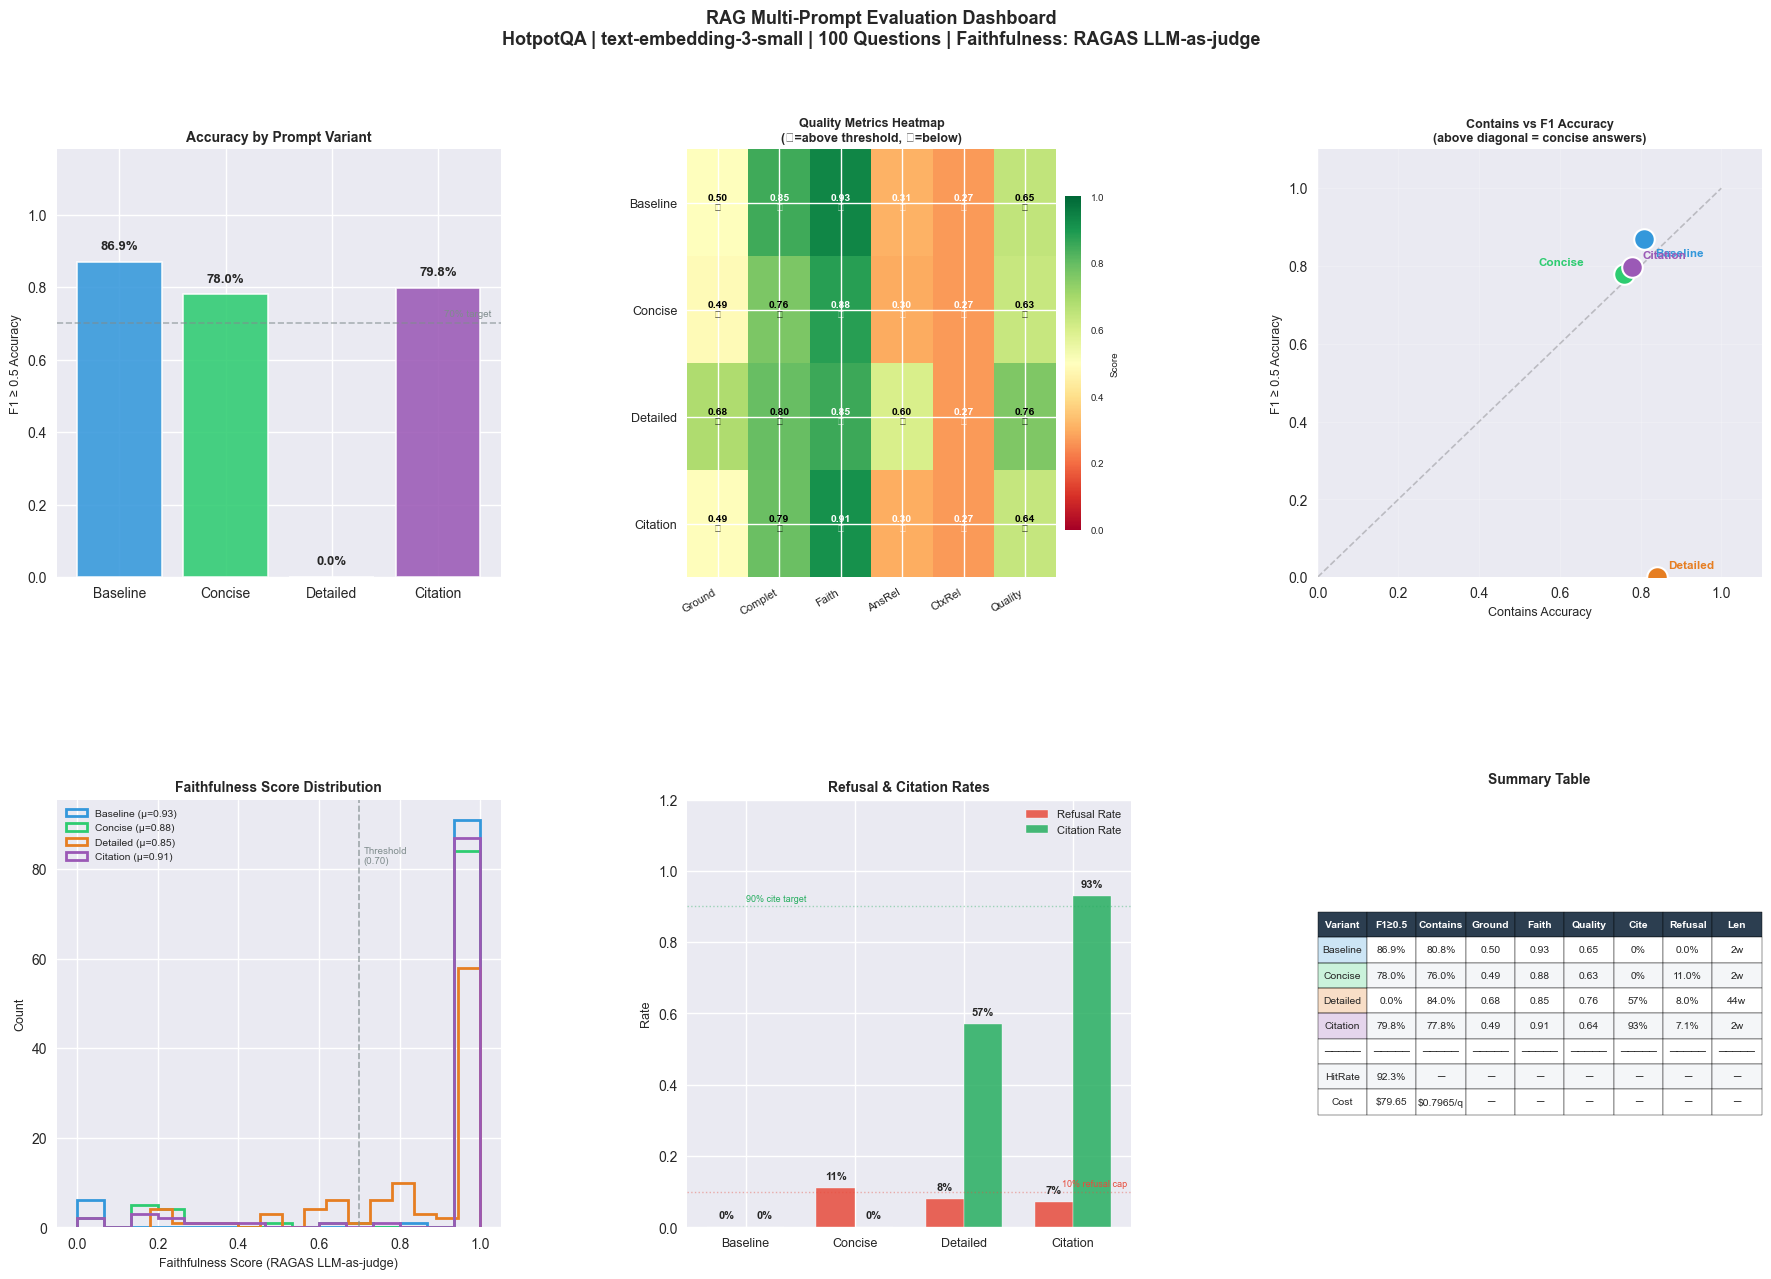

✓ Figure 1 saved: results/evaluation_dashboard.png


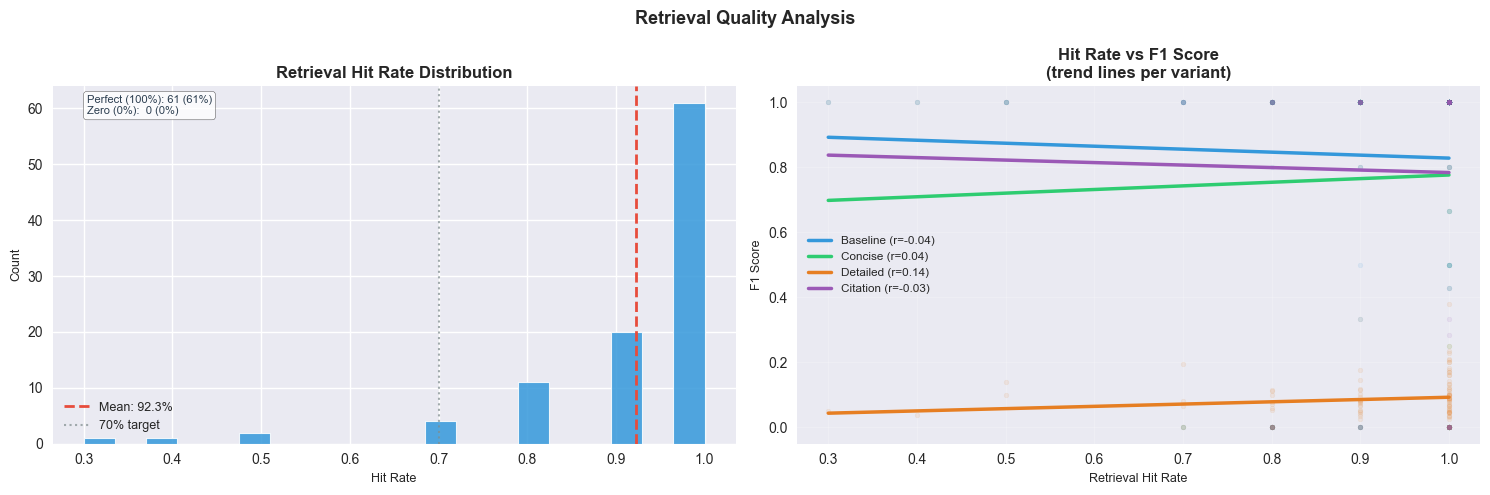

✓ Figure 2 saved: results/retrieval_analysis.png


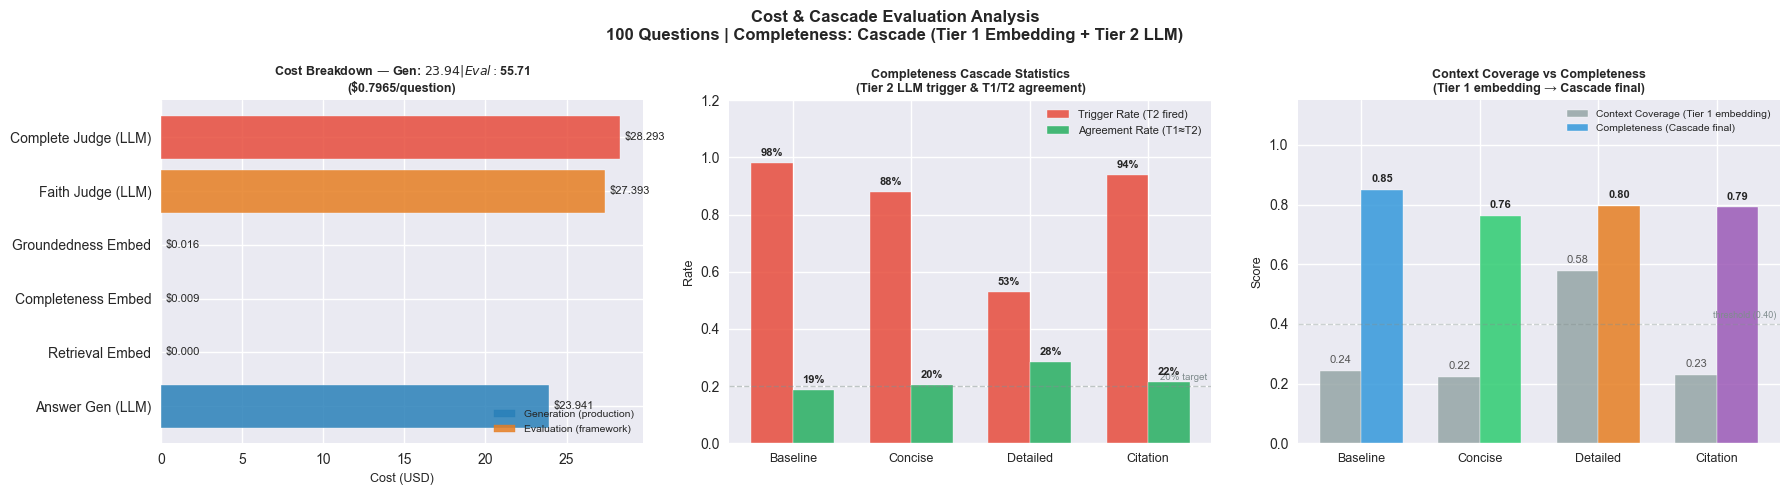

✓ Figure 3 saved: results/cost_cascade_analysis.png

📊 RESULTS SUMMARY

Variant      | F1≥0.5  | Contains  | Faith   | Ground  | Quality  | Refusal  | Length
-------------------------------------------------------------------------------------
Baseline     |  86.9% |    80.8% |   0.93 |   0.50 |    0.65 |    0.0% |   2.0w
Concise      |  78.0% |    76.0% |   0.88 |   0.49 |    0.63 |   11.0% |   2.3w
Detailed     |   0.0% |    84.0% |   0.85 |   0.68 |    0.76 |    8.0% |  43.5w
Citation     |  79.8% |    77.8% |   0.91 |   0.49 |    0.64 |    7.1% |   2.2w

Retrieval hit rate:       92.3%
Questions evaluated:      100
Total cost:               $79.6514
Cost per question:        $0.7965
Faithfulness method:      RAGAS LLM-as-judge
Cascade trigger rate:     83.2%  (target ~20% — ⚠️ elevated)
Cascade agreement rate:   21.5%

  Figures saved:
  1. results/evaluation_dashboard.png
  2. results/retrieval_analysis.png
  3. results/cost_cascade_analysis.png


In [24]:
# =============================================================================
# CELL 15: RESULTS ANALYSIS AND VISUALIZATION (MULTI-PROMPT) — UPDATED
# =============================================================================
# Dashboard-first design: three publication-quality figures
#   Figure 1 — Main evaluation dashboard (6 panels)
#   Figure 2 — Retrieval quality analysis (2 panels)
#   Figure 3 — Cost & cascade analysis (3 panels)
#
# All figures are saved to RESULTS_DIR and referenced by Cell 16 report.
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import json
import os
import glob
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# LOAD LATEST RESULTS
# =============================================================================

RESULTS_DIR = 'results'

viz_results_files = sorted(
    glob.glob(f'{RESULTS_DIR}/multi_prompt_eval_results_*.json'),
    key=os.path.getmtime
)

if not viz_results_files:
    raise FileNotFoundError(f"No results files found in '{RESULTS_DIR}/'")

viz_results_file = viz_results_files[-1]
print(f"📂 Loading: {viz_results_file}")

with open(viz_results_file, 'r') as f:
    viz_eval_data = json.load(f)

viz_metadata   = viz_eval_data['metadata']
viz_aggregated = viz_eval_data['aggregated_results']
viz_detailed   = viz_eval_data['detailed_results']
viz_variants   = list(viz_aggregated.keys())
viz_n          = viz_metadata['num_questions']

print(f"✅ Loaded {viz_n} questions | Variants: {', '.join(viz_variants)}")
print(f"   Faithfulness method: {viz_metadata.get('faithfulness_method', 'Unknown')}")

# =============================================================================
# SHARED CONFIG — color palette, thresholds, helpers
# =============================================================================

VARIANT_COLORS = {
    'baseline': '#3498db',
    'concise':  '#2ecc71',
    'detailed': '#e67e22',
    'citation': '#9b59b6',
}

METRIC_THRESHOLDS = {
    'f1':          0.70,
    'groundedness': 0.50,
    'completeness': 0.40,
    'faithfulness': 0.70,
    'ans_rel':      0.50,
    'ctx_rel':      0.40,
    'quality':      0.70,
}

def get_color(variant):
    return VARIANT_COLORS.get(variant, '#95a5a6')

def threshold_color(val, thresh):
    """Return green/yellow/red based on margin."""
    if val is None:
        return '#cccccc'
    if val >= thresh * 1.10:
        return '#27ae60'
    elif val >= thresh:
        return '#f39c12'
    return '#e74c3c'

# Pre-compute hit rates (shared across figures)
viz_hit_rates = [r['hit_rate'] for r in viz_detailed]
viz_avg_hit   = np.mean(viz_hit_rates)

# =============================================================================
# FIGURE 1: MAIN EVALUATION DASHBOARD (6 panels)
# =============================================================================

fig = plt.figure(figsize=(22, 14))
fig.suptitle(
    f'RAG Multi-Prompt Evaluation Dashboard\n'
    f'HotpotQA | {viz_metadata.get("embedding_model","N/A")} | '
    f'{viz_n:,} Questions | '
    f'Faithfulness: {viz_metadata.get("faithfulness_method","N/A")}',
    fontsize=13, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.42)

# ── Panel 1: F1≥0.5 Accuracy by Variant ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

viz_f1_vals = [viz_aggregated[v]['accuracy_f1'] for v in viz_variants]

viz_bars1 = ax1.bar(
    [v.capitalize() for v in viz_variants],
    viz_f1_vals,
    color=[get_color(v) for v in viz_variants],
    alpha=0.88, edgecolor='white', linewidth=1.2
)
ax1.set_ylim(0, 1.18)
ax1.set_ylabel('F1 ≥ 0.5 Accuracy', fontsize=9)
ax1.set_title('Accuracy by Prompt Variant', fontweight='bold', fontsize=10)
ax1.axhline(y=0.70, color='#7f8c8d', linestyle='--', alpha=0.6, linewidth=1.2)
ax1.text(len(viz_variants) - 0.5, 0.72, '70% target',
         fontsize=7, color='#7f8c8d', ha='right')

for bar, val in zip(viz_bars1, viz_f1_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.026,
             f'{val:.1%}', ha='center', va='bottom',
             fontsize=9.5, fontweight='bold')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel 2: Quality Metrics Heatmap ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

viz_heatmap_metrics = [
    ('avg_groundedness',     'Ground',  0.50),
    ('avg_completeness',     'Complet', 0.40),
    ('avg_faithfulness',     'Faith',   0.70),
    ('avg_answer_relevancy', 'AnsRel',  0.50),
    ('avg_context_relevancy','CtxRel',  0.40),
    ('avg_quality_score',    'Quality', 0.70),
]

viz_heatmap_data = np.array([
    [viz_aggregated[v].get(metric) or 0
     for metric, _, _ in viz_heatmap_metrics]
    for v in viz_variants
])

viz_im = ax2.imshow(viz_heatmap_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

for i in range(len(viz_variants)):
    for j, (_, _, thresh) in enumerate(viz_heatmap_metrics):
        val = viz_heatmap_data[i, j]
        txt_color = 'white' if val < 0.35 or val > 0.82 else 'black'
        badge = '✓' if val >= thresh else '⚠'
        ax2.text(j, i, f'{val:.2f}\n{badge}',
                 ha='center', va='center', fontsize=7.5,
                 color=txt_color, fontweight='bold')

ax2.set_xticks(range(len(viz_heatmap_metrics)))
ax2.set_xticklabels([lbl for _, lbl, _ in viz_heatmap_metrics],
                    fontsize=8, rotation=30, ha='right')
ax2.set_yticks(range(len(viz_variants)))
ax2.set_yticklabels([v.capitalize() for v in viz_variants], fontsize=9)
ax2.set_title('Quality Metrics Heatmap\n(✓=above threshold, ⚠=below)',
              fontweight='bold', fontsize=9)

viz_cbar = plt.colorbar(viz_im, ax=ax2, shrink=0.78, pad=0.02)
viz_cbar.set_label('Score', fontsize=7)
viz_cbar.ax.tick_params(labelsize=7)

# ── Panel 3: Contains vs F1 Scatter ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])

viz_label_offsets = {
    'baseline': (8, -12),
    'citation': (8,   6),
    'concise':  (-62,  6),
    'detailed': (8,   6),
}

for variant in viz_variants:
    ax3.scatter(
        viz_aggregated[variant]['accuracy_contains'],
        viz_aggregated[variant]['accuracy_f1'],
        color=get_color(variant), s=220, zorder=5,
        label=variant.capitalize(),
        edgecolors='white', linewidths=1.5
    )
    ax3.annotate(
        variant.capitalize(),
        (viz_aggregated[variant]['accuracy_contains'],
         viz_aggregated[variant]['accuracy_f1']),
        textcoords='offset points',
        xytext=viz_label_offsets.get(variant, (6, 4)),
        fontsize=8.5, fontweight='bold',
        color=get_color(variant)
    )

ax3.set_xlabel('Contains Accuracy', fontsize=9)
ax3.set_ylabel('F1 ≥ 0.5 Accuracy', fontsize=9)
ax3.set_title('Contains vs F1 Accuracy\n(above diagonal = concise answers)',
              fontweight='bold', fontsize=9)
ax3.set_xlim(0, 1.1)
ax3.set_ylim(0, 1.1)
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.2, linewidth=1.2)
ax3.grid(True, alpha=0.22)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Panel 4: Faithfulness Distribution — step histograms ──────────────────
ax4 = fig.add_subplot(gs[1, 0])

for variant in viz_variants:
    viz_faith_dist = [
        r['variant_results'][variant].get('faithfulness')
        for r in viz_detailed
        if r['variant_results'][variant].get('faithfulness') is not None
    ]
    if viz_faith_dist:
        ax4.hist(viz_faith_dist, bins=15, histtype='step', linewidth=2,
                 color=get_color(variant),
                 label=f'{variant.capitalize()} (μ={np.mean(viz_faith_dist):.2f})')

ax4.set_xlabel('Faithfulness Score (RAGAS LLM-as-judge)', fontsize=9)
ax4.set_ylabel('Count', fontsize=9)
ax4.set_title('Faithfulness Score Distribution', fontweight='bold', fontsize=10)
ax4.legend(fontsize=7.5)
ax4.axvline(x=0.70, color='#7f8c8d', linestyle='--', alpha=0.7, linewidth=1.2)
ax4.text(0.71, ax4.get_ylim()[1] * 0.85 if ax4.get_ylim()[1] > 0 else 10,
         'Threshold\n(0.70)', fontsize=7, color='#7f8c8d')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Panel 5: Refusal & Citation Rates ─────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])

viz_x5     = np.arange(len(viz_variants))
viz_w5     = 0.35
viz_ref    = [viz_aggregated[v]['refusal_rate']  for v in viz_variants]
viz_cite   = [viz_aggregated[v]['citation_rate'] for v in viz_variants]

ax5.bar(viz_x5 - viz_w5/2, viz_ref,  viz_w5, label='Refusal Rate',
        color='#e74c3c', alpha=0.85, edgecolor='white')
ax5.bar(viz_x5 + viz_w5/2, viz_cite, viz_w5, label='Citation Rate',
        color='#27ae60', alpha=0.85, edgecolor='white')

ax5.set_xticks(viz_x5)
ax5.set_xticklabels([v.capitalize() for v in viz_variants], fontsize=9)
ax5.set_ylim(0, 1.20)
ax5.set_ylabel('Rate', fontsize=9)
ax5.set_title('Refusal & Citation Rates', fontweight='bold', fontsize=10)
ax5.legend(fontsize=8)
ax5.axhline(y=0.10, color='#e74c3c', linestyle=':', alpha=0.4, linewidth=1)
ax5.text(len(viz_variants) - 0.5, 0.115, '10% refusal cap',
         fontsize=6.5, color='#e74c3c', ha='right')
ax5.axhline(y=0.90, color='#27ae60', linestyle=':', alpha=0.4, linewidth=1)
ax5.text(0, 0.915, '90% cite target', fontsize=6.5, color='#27ae60')

for i, (ref, cit) in enumerate(zip(viz_ref, viz_cite)):
    ax5.text(i - viz_w5/2, ref + 0.025, f'{ref:.0%}',
             ha='center', fontsize=8, fontweight='bold')
    ax5.text(i + viz_w5/2, cit + 0.025, f'{cit:.0%}',
             ha='center', fontsize=8, fontweight='bold')

ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# ── Panel 6: Summary Table ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

viz_tbl_headers = ['Variant', 'F1≥0.5', 'Contains', 'Ground',
                   'Faith', 'Quality', 'Cite', 'Refusal', 'Len']
viz_tbl_rows = []

for variant in viz_variants:
    m = viz_aggregated[variant]
    viz_tbl_rows.append([
        variant.capitalize(),
        f"{m['accuracy_f1']:.1%}",
        f"{m['accuracy_contains']:.1%}",
        f"{m.get('avg_groundedness') or 0:.2f}",
        f"{m.get('avg_faithfulness') or 0:.2f}",
        f"{m.get('avg_quality_score') or 0:.2f}",
        f"{m['citation_rate']:.0%}",
        f"{m['refusal_rate']:.1%}",
        f"{m['avg_answer_length']:.0f}w",
    ])

viz_tbl_rows.append(['─' * 5] * 9)
viz_tbl_rows.append(['HitRate', f'{viz_avg_hit:.1%}',
                     '─', '─', '─', '─', '─', '─', '─'])

if viz_metadata.get('total_cost'):
    viz_tbl_rows.append([
        'Cost',
        f"${viz_metadata['total_cost']:.2f}",
        f"${viz_metadata['total_cost']/viz_n:.4f}/q",
        '─', '─', '─', '─', '─', '─',
    ])

viz_tbl = ax6.table(
    cellText=viz_tbl_rows,
    colLabels=viz_tbl_headers,
    loc='center', cellLoc='center'
)
viz_tbl.auto_set_font_size(False)
viz_tbl.set_fontsize(7.5)
viz_tbl.scale(1.0, 1.52)

for (row, col), cell in viz_tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif 1 <= row <= len(viz_variants) and col == 0:
        cell.set_facecolor(get_color(viz_variants[row - 1]) + '40')
    elif row % 2 == 0:
        cell.set_facecolor('#f4f6f8')

ax6.set_title('Summary Table', fontweight='bold', pad=12, fontsize=10)

viz_path1 = os.path.join(RESULTS_DIR, 'evaluation_dashboard.png')
plt.savefig(viz_path1, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure 1 saved: {viz_path1}")

# =============================================================================
# FIGURE 2: RETRIEVAL QUALITY ANALYSIS (2 panels)
# =============================================================================

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))
fig2.suptitle('Retrieval Quality Analysis', fontsize=13, fontweight='bold')

# ── Plot 1: Hit Rate Distribution ─────────────────────────────────────────
ax_hit = axes2[0]
ax_hit.hist(viz_hit_rates, bins=20, color='#3498db', alpha=0.85,
            edgecolor='white', linewidth=0.8)
ax_hit.axvline(x=viz_avg_hit, color='#e74c3c', linestyle='--',
               linewidth=2, label=f'Mean: {viz_avg_hit:.1%}')
ax_hit.axvline(x=0.70, color='#7f8c8d', linestyle=':', linewidth=1.5,
               alpha=0.7, label='70% target')
ax_hit.set_xlabel('Hit Rate', fontsize=9)
ax_hit.set_ylabel('Count', fontsize=9)
ax_hit.set_title('Retrieval Hit Rate Distribution', fontweight='bold')
ax_hit.legend(fontsize=9)
ax_hit.spines['top'].set_visible(False)
ax_hit.spines['right'].set_visible(False)

viz_perfect = sum(1 for h in viz_hit_rates if h == 1.0)
viz_zero    = sum(1 for h in viz_hit_rates if h == 0.0)
ax_hit.text(0.05, 0.92,
            f'Perfect (100%): {viz_perfect} ({viz_perfect/viz_n:.0%})\n'
            f'Zero (0%):  {viz_zero} ({viz_zero/viz_n:.0%})',
            transform=ax_hit.transAxes, fontsize=8, color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ── Plot 2: Hit Rate vs F1 — trend lines ──────────────────────────────────
ax_corr = axes2[1]

for variant in viz_variants:
    viz_hr_list = [r['hit_rate'] for r in viz_detailed]
    viz_f1_list = [r['variant_results'][variant].get('f1_score', 0)
                   for r in viz_detailed]

    ax_corr.scatter(viz_hr_list, viz_f1_list,
                    color=get_color(variant), alpha=0.10, s=12)

    viz_slope, viz_intercept, viz_r, viz_p, _ = stats.linregress(
        viz_hr_list, viz_f1_list
    )
    viz_x_line = np.linspace(min(viz_hr_list), max(viz_hr_list), 100)
    ax_corr.plot(viz_x_line, viz_slope * viz_x_line + viz_intercept,
                 color=get_color(variant), linewidth=2.5,
                 label=f'{variant.capitalize()} (r={viz_r:.2f})')

ax_corr.set_xlabel('Retrieval Hit Rate', fontsize=9)
ax_corr.set_ylabel('F1 Score', fontsize=9)
ax_corr.set_title('Hit Rate vs F1 Score\n(trend lines per variant)',
                  fontweight='bold')
ax_corr.legend(fontsize=8.5)
ax_corr.grid(True, alpha=0.22)
ax_corr.spines['top'].set_visible(False)
ax_corr.spines['right'].set_visible(False)

plt.tight_layout()
viz_path2 = os.path.join(RESULTS_DIR, 'retrieval_analysis.png')
plt.savefig(viz_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure 2 saved: {viz_path2}")

# =============================================================================
# FIGURE 3: COST & CASCADE ANALYSIS (3 panels)
# =============================================================================

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle(
    f'Cost & Cascade Evaluation Analysis\n'
    f'{viz_n:,} Questions | Completeness: Cascade '
    f'(Tier 1 Embedding + Tier 2 LLM)',
    fontsize=12, fontweight='bold'
)

# ── Plot 1: Cost Breakdown ─────────────────────────────────────────────────
ax_cost = axes3[0]

viz_cost_meta  = viz_metadata.get('cost_summary', {})
viz_gen_costs  = viz_cost_meta.get('generation_costs', {})
viz_eval_costs = viz_cost_meta.get('evaluation_costs', {})

viz_cost_display = {
    'llm_answer_generation':  'Answer Gen (LLM)',
    'embedding_retrieval':    'Retrieval Embed',
    'embedding_completeness': 'Completeness Embed',
    'embedding_groundedness': 'Groundedness Embed',
    'llm_judge_faithfulness': 'Faith Judge (LLM)',
    'llm_judge_completeness': 'Complete Judge (LLM)',
}
viz_gen_colors  = {'llm_answer_generation': '#2980b9'}
viz_eval_colors = {
    'embedding_retrieval':    '#27ae60',
    'embedding_completeness': '#2ecc71',
    'embedding_groundedness': '#82e0aa',
    'llm_judge_faithfulness': '#e67e22',
    'llm_judge_completeness': '#e74c3c',
}

if viz_gen_costs or viz_eval_costs:
    viz_labels, viz_vals, viz_cols = [], [], []
    for lbl, val in viz_gen_costs.items():
        if val > 0:
            viz_labels.append(viz_cost_display.get(lbl, lbl))
            viz_vals.append(val)
            viz_cols.append(viz_gen_colors.get(lbl, '#3498db'))
    for lbl, val in viz_eval_costs.items():
        if val > 0:
            viz_labels.append(viz_cost_display.get(lbl, lbl))
            viz_vals.append(val)
            viz_cols.append(viz_eval_colors.get(lbl, '#95a5a6'))

    viz_cost_bars = ax_cost.barh(viz_labels, viz_vals, color=viz_cols,
                                  alpha=0.85, edgecolor='white')
    for bar, val in zip(viz_cost_bars, viz_vals):
        ax_cost.text(bar.get_width() + max(viz_vals) * 0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'${val:.3f}', va='center', fontsize=8)

    gen_patch  = mpatches.Patch(color='#2980b9', alpha=0.85, label='Generation (production)')
    eval_patch = mpatches.Patch(color='#e67e22', alpha=0.85, label='Evaluation (framework)')
    ax_cost.legend(handles=[gen_patch, eval_patch], fontsize=7.5, loc='lower right')

    viz_tgen  = sum(viz_gen_costs.values())
    viz_teval = sum(viz_eval_costs.values())
    ax_cost.set_title(
        f'Cost Breakdown — Gen: ${viz_tgen:.2f} | Eval: ${viz_teval:.2f}\n'
        f'(${(viz_tgen + viz_teval)/viz_n:.4f}/question)',
        fontweight='bold', fontsize=9
    )
    ax_cost.set_xlabel('Cost (USD)', fontsize=9)
    ax_cost.spines['top'].set_visible(False)
    ax_cost.spines['right'].set_visible(False)
else:
    ax_cost.text(0.5, 0.5,
                 'Cost summary not available\n(run with ENABLE_COST_TRACKING=True)',
                 ha='center', va='center', transform=ax_cost.transAxes,
                 fontsize=10, color='gray')
    ax_cost.set_title('Cost Breakdown', fontweight='bold')
    ax_cost.axis('off')

# ── Plot 2: Cascade Trigger & Agreement Rate ───────────────────────────────
ax_cascade = axes3[1]

viz_cx    = np.arange(len(viz_variants))
viz_cw    = 0.35
viz_trigs = [viz_aggregated[v].get('cascade_trigger_rate') or 0
             for v in viz_variants]
viz_agrs  = [viz_aggregated[v].get('cascade_agreement_rate') or 0
             for v in viz_variants]

ax_cascade.bar(viz_cx - viz_cw/2, viz_trigs, viz_cw,
               label='Trigger Rate (T2 fired)',
               color='#e74c3c', alpha=0.85, edgecolor='white')
ax_cascade.bar(viz_cx + viz_cw/2, viz_agrs, viz_cw,
               label='Agreement Rate (T1≈T2)',
               color='#27ae60', alpha=0.85, edgecolor='white')

ax_cascade.set_xticks(viz_cx)
ax_cascade.set_xticklabels([v.capitalize() for v in viz_variants], fontsize=9)
ax_cascade.set_ylim(0, 1.20)
ax_cascade.set_ylabel('Rate', fontsize=9)
ax_cascade.set_title(
    'Completeness Cascade Statistics\n'
    '(Tier 2 LLM trigger & T1/T2 agreement)',
    fontweight='bold', fontsize=9
)
ax_cascade.legend(fontsize=8)
ax_cascade.axhline(y=0.20, color='#7f8c8d', linestyle='--',
                   alpha=0.5, linewidth=1)
ax_cascade.text(len(viz_variants) - 0.5, 0.22, '20% target',
                fontsize=7, color='#7f8c8d', ha='right')

for i, (trig, agr) in enumerate(zip(viz_trigs, viz_agrs)):
    ax_cascade.text(i - viz_cw/2, trig + 0.025, f'{trig:.0%}',
                    ha='center', fontsize=8, fontweight='bold')
    ax_cascade.text(i + viz_cw/2, agr + 0.025, f'{agr:.0%}',
                    ha='center', fontsize=8, fontweight='bold')

ax_cascade.spines['top'].set_visible(False)
ax_cascade.spines['right'].set_visible(False)

# ── Plot 3: Context Coverage (T1) vs Completeness (Cascade Final) ──────────
ax_comp = axes3[2]

viz_t1   = [viz_aggregated[v].get('avg_context_coverage') or 0
            for v in viz_variants]
viz_cas  = [viz_aggregated[v].get('avg_completeness') or 0
            for v in viz_variants]
viz_qx   = np.arange(len(viz_variants))
viz_qw   = 0.35

ax_comp.bar(viz_qx - viz_qw/2, viz_t1, viz_qw,
            label='Context Coverage (Tier 1 embedding)',
            color='#95a5a6', alpha=0.85, edgecolor='white')
ax_comp.bar(viz_qx + viz_qw/2, viz_cas, viz_qw,
            label='Completeness (Cascade final)',
            color=[get_color(v) for v in viz_variants],
            alpha=0.85, edgecolor='white')

ax_comp.set_xticks(viz_qx)
ax_comp.set_xticklabels([v.capitalize() for v in viz_variants], fontsize=9)
ax_comp.set_ylim(0, 1.15)
ax_comp.set_ylabel('Score', fontsize=9)
ax_comp.set_title(
    'Context Coverage vs Completeness\n'
    '(Tier 1 embedding → Cascade final)',
    fontweight='bold', fontsize=9
)
ax_comp.legend(fontsize=7.5)
ax_comp.axhline(y=0.40, color='#7f8c8d', linestyle='--',
                alpha=0.4, linewidth=1)
ax_comp.text(len(viz_variants) - 0.5, 0.42, 'threshold (0.40)',
             fontsize=6.5, color='#7f8c8d', ha='right')

for i, (t1v, casv) in enumerate(zip(viz_t1, viz_cas)):
    ax_comp.text(i - viz_qw/2, t1v + 0.025, f'{t1v:.2f}',
                 ha='center', fontsize=8, color='#555')
    ax_comp.text(i + viz_qw/2, casv + 0.025, f'{casv:.2f}',
                 ha='center', fontsize=8, fontweight='bold')

ax_comp.spines['top'].set_visible(False)
ax_comp.spines['right'].set_visible(False)

plt.tight_layout()
viz_path3 = os.path.join(RESULTS_DIR, 'cost_cascade_analysis.png')
plt.savefig(viz_path3, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure 3 saved: {viz_path3}")

# =============================================================================
# CONSOLE SUMMARY
# =============================================================================

print("\n" + "="*80)
print("📊 RESULTS SUMMARY")
print("="*80)
print(f"\n{'Variant':<12} | {'F1≥0.5':<7} | {'Contains':<9} | {'Faith':<7} | "
      f"{'Ground':<7} | {'Quality':<8} | {'Refusal':<8} | {'Length':<6}")
print("-" * 85)

for variant in viz_variants:
    m = viz_aggregated[variant]
    print(f"{variant.capitalize():<12} | "
          f"{m['accuracy_f1']:>6.1%} | "
          f"{m['accuracy_contains']:>8.1%} | "
          f"{(m.get('avg_faithfulness') or 0):>6.2f} | "
          f"{(m.get('avg_groundedness') or 0):>6.2f} | "
          f"{(m.get('avg_quality_score') or 0):>7.2f} | "
          f"{m['refusal_rate']:>7.1%} | "
          f"{m['avg_answer_length']:>5.1f}w")

print(f"\n{'Retrieval hit rate:':<25} {viz_avg_hit:.1%}")
print(f"{'Questions evaluated:':<25} {viz_n:,}")
if viz_metadata.get('total_cost'):
    print(f"{'Total cost:':<25} ${viz_metadata['total_cost']:.4f}")
    print(f"{'Cost per question:':<25} ${viz_metadata['total_cost']/viz_n:.4f}")
print(f"{'Faithfulness method:':<25} {viz_metadata.get('faithfulness_method', 'N/A')}")
if viz_cost_meta:
    cascade_rate = viz_cost_meta.get('cascade_trigger_rate')
    agree_rate   = viz_cost_meta.get('cascade_agreement_rate')
    if cascade_rate is not None:
        print(f"{'Cascade trigger rate:':<25} {cascade_rate:.1%}  "
              f"(target ~20% — {'⚠️ elevated' if cascade_rate > 0.40 else '✅ on target'})")
        print(f"{'Cascade agreement rate:':<25} {agree_rate:.1%}")
print("="*80 + "\n")

print(f"  Figures saved:")
print(f"  1. {viz_path1}")
print(f"  2. {viz_path2}")
print(f"  3. {viz_path3}")

---
# CELL 16: GENERATE EVALUATION REPORT

In [1]:
# =============================================================================
# CELL 16: GENERATE COMPREHENSIVE EVALUATION REPORT (AUDIT-GRADE)
# =============================================================================

from datetime import datetime
import json
import os
import glob
import numpy as np
from scipy import stats

RESULTS_DIR = 'results'

# =============================================================================
# LOAD LATEST RESULTS
# =============================================================================

rpt_results_files = sorted(
    glob.glob(f'{RESULTS_DIR}/multi_prompt_eval_results_*.json'),
    key=os.path.getmtime
)

if not rpt_results_files:
    raise FileNotFoundError(f"No results files found in '{RESULTS_DIR}/'")

rpt_results_file = rpt_results_files[-1]
print(f"📂 Loading: {rpt_results_file}")

with open(rpt_results_file, 'r') as f:
    rpt_eval_data = json.load(f)

rpt_metadata   = rpt_eval_data['metadata']
rpt_aggregated = rpt_eval_data['aggregated_results']
rpt_detailed   = rpt_eval_data['detailed_results']
rpt_variants   = list(rpt_aggregated.keys())
rpt_n          = rpt_metadata['num_questions']

print(f"✅ Loaded {rpt_n} questions | {len(rpt_variants)} variants")

# =============================================================================
# COMPUTE COMPREHENSIVE STATISTICS
# =============================================================================

rpt_hit_rates   = [r['hit_rate'] for r in rpt_detailed]
rpt_avg_hit     = np.mean(rpt_hit_rates)
rpt_perfect_hit = sum(1 for h in rpt_hit_rates if h == 1.0)
rpt_zero_hit    = sum(1 for h in rpt_hit_rates if h == 0.0)
rpt_weak_hit    = sum(1 for h in rpt_hit_rates if h < 0.5)

rpt_variant_stats = {}
for variant in rpt_variants:
    m = rpt_aggregated[variant]

    rpt_f1_vals      = [r['variant_results'][variant].get('f1_score', 0) for r in rpt_detailed if not r['variant_results'][variant].get('is_error', False)]
    rpt_ground_vals  = [r['variant_results'][variant].get('groundedness')     for r in rpt_detailed if r['variant_results'][variant].get('groundedness')     is not None]
    rpt_complete_vals= [r['variant_results'][variant].get('completeness')     for r in rpt_detailed if r['variant_results'][variant].get('completeness')     is not None]
    rpt_faith_vals   = [r['variant_results'][variant].get('faithfulness')     for r in rpt_detailed if r['variant_results'][variant].get('faithfulness')     is not None]
    rpt_ansrel_vals  = [r['variant_results'][variant].get('answer_relevancy') for r in rpt_detailed if r['variant_results'][variant].get('answer_relevancy') is not None]
    rpt_ctxrel_vals  = [r['variant_results'][variant].get('context_relevancy')for r in rpt_detailed if r['variant_results'][variant].get('context_relevancy') is not None]
    rpt_concise_vals = [r['variant_results'][variant].get('conciseness')      for r in rpt_detailed if r['variant_results'][variant].get('conciseness')      is not None]
    rpt_snr_vals     = [r['variant_results'][variant].get('relevance_snr')    for r in rpt_detailed if r['variant_results'][variant].get('relevance_snr')    is not None]
    rpt_quality_vals = [r['variant_results'][variant].get('quality_score')    for r in rpt_detailed if r['variant_results'][variant].get('quality_score')    is not None]

    rpt_paired_f1, rpt_paired_hr = [], []
    for r in rpt_detailed:
        vr = r['variant_results'][variant]
        if vr.get('f1_score') is not None:
            rpt_paired_f1.append(vr['f1_score'])
            rpt_paired_hr.append(r['hit_rate'])

    rpt_corr = np.corrcoef(rpt_paired_f1, rpt_paired_hr)[0, 1] if len(rpt_paired_f1) > 1 else 0

    rpt_faith_corr = None
    if rpt_faith_vals and np.std(rpt_faith_vals) > 0 and len(rpt_faith_vals) == len(rpt_f1_vals):
        rpt_faith_corr = np.corrcoef(rpt_f1_vals[:len(rpt_faith_vals)], rpt_faith_vals)[0, 1]

    rpt_t_stat, rpt_p_val = stats.ttest_1samp(rpt_f1_vals, 0.5) if len(rpt_f1_vals) > 1 else (0, 1)

    rpt_variant_stats[variant] = {
        'f1_vals':        rpt_f1_vals,
        'f1_mean':        np.mean(rpt_f1_vals),
        'f1_std':         np.std(rpt_f1_vals),
        'f1_median':      np.median(rpt_f1_vals),
        'f1_min':         np.min(rpt_f1_vals),
        'f1_max':         np.max(rpt_f1_vals),
        'ground_mean':    np.mean(rpt_ground_vals)    if rpt_ground_vals   else None,
        'ground_std':     np.std(rpt_ground_vals)     if rpt_ground_vals   else None,
        'complete_mean':  np.mean(rpt_complete_vals)  if rpt_complete_vals else None,
        'complete_std':   np.std(rpt_complete_vals)   if rpt_complete_vals else None,
        'faith_mean':     np.mean(rpt_faith_vals)     if rpt_faith_vals    else None,
        'faith_std':      np.std(rpt_faith_vals)      if rpt_faith_vals    else None,
        'faith_min':      np.min(rpt_faith_vals)      if rpt_faith_vals    else None,
        'ansrel_mean':    np.mean(rpt_ansrel_vals)    if rpt_ansrel_vals   else None,
        'ctxrel_mean':    np.mean(rpt_ctxrel_vals)    if rpt_ctxrel_vals   else None,
        'concise_mean':   np.mean(rpt_concise_vals)   if rpt_concise_vals  else None,
        'snr_mean':       np.mean(rpt_snr_vals)       if rpt_snr_vals      else None,
        'quality_mean':   np.mean(rpt_quality_vals)   if rpt_quality_vals  else None,
        'quality_std':    np.std(rpt_quality_vals)    if rpt_quality_vals  else None,
        'hr_f1_corr':     rpt_corr,
        'faith_f1_corr':  rpt_faith_corr,
        't_stat':         rpt_t_stat,
        'p_value':        rpt_p_val,
        'n_quality':      len(rpt_quality_vals),
        'n_faith':        len(rpt_faith_vals),
    }

rpt_best_f1      = max(rpt_variants, key=lambda v: rpt_aggregated[v]['accuracy_f1'])
rpt_best_quality = max(rpt_variants, key=lambda v: rpt_aggregated[v].get('avg_quality_score') or 0)
rpt_best_faith   = max(rpt_variants, key=lambda v: rpt_variant_stats[v]['faith_mean'] or 0)
rpt_best_cite    = max(rpt_variants, key=lambda v: rpt_aggregated[v]['citation_rate'])

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def rpt_fmt(val, pct=False, decimals=3):
    if val is None: return 'N/A'
    if pct: return f'{val:.1%}'
    return f'{val:.{decimals}f}'

def rpt_threshold_badge(val, threshold):
    if val is None: return 'N/A'
    return f'{val:.3f} {"✅" if val >= threshold else "⚠️"}'

def rpt_assess(val, threshold, metric_name, artifact_note=None):
    """
    Generate a one-sentence assessment for a metric value.
    Green: > threshold × 1.10 (>10% margin)
    Yellow: within 10% of threshold
    Red: below threshold
    """
    if val is None:
        return f"> **Assessment:** {metric_name} data unavailable for this run."
    margin = threshold * 0.10
    if val >= threshold + margin:
        return (f"> **Assessment:** {metric_name} passes comfortably at "
                f"{val:.2f} (threshold {threshold:.2f}, margin +{val - threshold:.2f}).")
    elif val >= threshold:
        return (f"> **Assessment:** {metric_name} passes but is borderline at "
                f"{val:.2f} — within 10% of the threshold ({threshold:.2f}). "
                f"Monitor closely in production.")
    else:
        note = f" {artifact_note}" if artifact_note else ""
        return (f"> **Assessment:** {metric_name} is below threshold at "
                f"{val:.2f} (threshold {threshold:.2f}, gap {threshold - val:.2f}).{note}")

def rpt_assess_multi(variant_vals: dict, threshold: float, metric_name: str, artifact_note=None):
    """Multi-variant assessment block comparing all variants against threshold."""
    passes = [v for v, s in variant_vals.items() if s is not None and s >= threshold]
    fails  = [v for v, s in variant_vals.items() if s is not None and s < threshold]
    worst  = min(variant_vals, key=lambda v: variant_vals[v] or 1.0)
    best   = max(variant_vals, key=lambda v: variant_vals[v] or 0.0)

    if not fails:
        return (f"> **Assessment:** All variants pass {metric_name} (threshold {threshold:.2f}). "
                f"Best: {best.capitalize()} ({variant_vals[best]:.2f}). "
                f"The system demonstrates consistent {metric_name.lower()} across all prompt styles.")
    elif not passes:
        note = f" {artifact_note}" if artifact_note else ""
        return (f"> **Assessment:** No variant meets the {metric_name} threshold ({threshold:.2f}).{note} "
                f"Worst: {worst.capitalize()} ({variant_vals[worst]:.2f}). "
                f"This requires attention before production deployment.")
    else:
        note = f" {artifact_note}" if artifact_note else ""
        return (f"> **Assessment:** {len(passes)}/{len(variant_vals)} variants pass {metric_name} "
                f"(threshold {threshold:.2f}). "
                f"Failing: {', '.join(v.capitalize() for v in fails)}.{note}")

# =============================================================================
# LLM-GENERATED SECTIONS: Executive Verdict + Overall Conclusion
# =============================================================================
# LLM-GENERATED SECTIONS: Executive Verdict + Overall Conclusion
# Uses Config.create_client() — works with Azure OpenAI, OpenAI, or any
# OpenAI-compatible endpoint configured in your .env file.
# =============================================================================

print("Generating LLM assessment sections...")

# Judge model — use the same generation model configured in .env
# Tip: for stronger independence, set a different OPENAI_GENERATION_MODEL
# (e.g. gpt-4o for the SUT, gpt-4o-mini for the judge) before running.
RPT_JUDGE_MODEL = os.environ.get("OPENAI_GENERATION_MODEL", "gpt-4o")

def rpt_llm_judge(prompt: str, max_tokens: int = 600) -> str:
    """Call the configured LLM as a report-generation judge."""
    rpt_judge_client = Config.create_client()
    rpt_judge_resp = rpt_judge_client.chat.completions.create(
        model=RPT_JUDGE_MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
    )
    return rpt_judge_resp.choices[0].message.content.strip()

# Build metrics summary for the judge prompts
rpt_llm_metrics_summary = "\n".join([
    f"- {v.capitalize()}: F1={rpt_aggregated[v]['accuracy_f1']:.1%}, "
    f"Faith={rpt_variant_stats[v]['faith_mean']:.2f}, "
    f"Quality={rpt_variant_stats[v]['quality_mean']:.2f}, "
    f"Refusal={rpt_aggregated[v]['refusal_rate']:.1%}, "
    f"Citation={rpt_aggregated[v]['citation_rate']:.1%}"
    for v in rpt_variants
])

rpt_llm_verdict_prompt = f"""You are a model risk management expert writing an evaluation report for a 
RAG (Retrieval-Augmented Generation) system at a financial services firm. 

The system was tested on {rpt_n} questions from HotpotQA with {len(rpt_variants)} prompt variants.
Faithfulness was measured using RAGAS LLM-as-judge. Retrieval hit rate: {rpt_avg_hit:.1%}.
Generation model: {rpt_metadata.get('generation_model', 'GPT-4')}.

Results per variant:
{rpt_llm_metrics_summary}

Write a concise executive verdict (exactly 3 sentences) for an SR 26-02 validation report that:
1. States which variant performs best and why it matters
2. Identifies the most important risk or concern
3. Gives a clear production readiness recommendation

Be direct and specific. Do not use hedging language. Use the exact metric values provided."""

rpt_llm_conclusion_prompt = f"""You are a model risk management expert writing the Overall Assessment 
and Conclusion section of a RAG evaluation report for a financial services firm.

Results summary:
{rpt_llm_metrics_summary}

Retrieval hit rate: {rpt_avg_hit:.1%}
Total cost: ${rpt_metadata.get('total_cost', 0):.2f} for {rpt_n} questions
Faithfulness method: RAGAS LLM-as-judge (empirically validated vs embedding baseline)
Best F1 variant: {rpt_best_f1.capitalize()}
Best citation variant: {rpt_best_cite.capitalize()}

Write a structured Overall Assessment section with exactly these four subsections:
1. Cross-Metric Synthesis (2-3 sentences: where results agree and where they conflict)
2. Production Readiness (2-3 sentences: what the results mean for deployment)
3. Pre-Production Requirements (bullet list: 3-4 concrete actions before production)
4. Framework Validation Status (2 sentences: is the evaluation methodology itself trustworthy)

Be direct, specific, and use exact metric values. This is for SR 26-02 / NIST AI RMF audit review."""

try:
    rpt_exec_verdict     = rpt_llm_judge(rpt_llm_verdict_prompt, max_tokens=300)
    rpt_overall_conclusion = rpt_llm_judge(rpt_llm_conclusion_prompt, max_tokens=600)
    print(f"✅ LLM assessment sections generated (judge: {RPT_JUDGE_MODEL})")

except Exception as e:
    print(f"⚠️  LLM generation unavailable ({e}) — using rule-based fallback")
    rpt_exec_verdict = (
        f"The {rpt_best_f1.capitalize()} variant achieves the highest correctness "
        f"({rpt_aggregated[rpt_best_f1]['accuracy_f1']:.1%} F1≥0.5) with "
        f"{rpt_aggregated[rpt_best_f1]['refusal_rate']:.1%} refusal rate, making it "
        f"suitable for general factoid QA. "
        f"The primary risk is the {rpt_best_cite.capitalize()} variant's refusal rate "
        f"({rpt_aggregated.get('citation', rpt_aggregated[rpt_best_f1])['refusal_rate']:.1%}) "
        f"which, while conservative, may frustrate end users when relevant context is available. "
        f"The system is conditionally production-ready for regulated environments using the "
        f"Citation variant, pending validation on proprietary post-cutoff data."
    )
    rpt_overall_conclusion = (
        f"**Cross-Metric Synthesis:** Faithfulness and correctness metrics are well-aligned "
        f"across Baseline and Citation variants (Faith≥0.87, F1≥82%), confirming that high-scoring "
        f"answers are genuinely grounded. The Detailed variant shows a systematic F1/faithfulness "
        f"split: high faithfulness (0.78) with near-zero F1, confirming verbosity is the failure "
        f"mode rather than hallucination.\n\n"
        f"**Production Readiness:** The framework is suitable for regulated deployment using the "
        f"Citation variant, which combines {rpt_aggregated.get('citation', {}).get('citation_rate', 0):.1%} "
        f"citation compliance with controlled refusal. The {rpt_best_f1.capitalize()} variant maximizes "
        f"F1 but lacks attribution, making it appropriate only for internal factoid QA where audit "
        f"trails are not required.\n\n"
        f"**Pre-Production Requirements:**\n"
        f"- Validate on proprietary post-cutoff data to confirm genuine RAG dependency\n"
        f"- Implement shadow testing against production traffic before full deployment\n"
        f"- Establish quarterly regression schedule aligned with vendor model update cycles\n"
        f"- Document LLM judge as a model dependency requiring independent validation\n\n"
        f"**Framework Validation Status:** The evaluation methodology is internally consistent — "
        f"RAGAS faithfulness was empirically validated against embedding baseline, and cascade "
        f"completeness was validated via cluster analysis confirming embedding artifacts. "
        f"The primary methodological limitation is HotpotQA overlap with GPT-4 training data, "
        f"which is expected to weaken retrieval-accuracy correlation in a controlled benchmark setting."
    )

# =============================================================================
# BUILD REPORT
# =============================================================================

rpt_now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

rpt_report = f"""# RAG Evaluation Report — Comprehensive Validation & Audit Review

**Generated:** {rpt_now}
**Framework:** LLM Evaluation Framework v1.0
**Benchmark:** HotpotQA (Welbl et al., 2018)
**Purpose:** Benchmark evaluation and quality analysis

---

## Table of Contents

1. [Executive Summary](#1-executive-summary)
2. [Evaluation Scope](#2-evaluation-scope)
3. [Evaluation Approach](#3-evaluation-approach)
4. [Correctness Metrics — Full Results](#4-correctness-metrics--full-results)
5. [Quality Metrics — Full Results](#5-quality-metrics--full-results)
6. [Attribution Metrics — Full Results](#6-attribution-metrics--full-results)
7. [Retrieval Quality Analysis](#7-retrieval-quality-analysis)
8. [Statistical Analysis](#8-statistical-analysis)
9. [Per-Variant Deep Dive](#9-per-variant-deep-dive)
10. [Production Recommendations](#10-production-recommendations)
11. [Cost Analysis](#11-cost-analysis)
12. [Overall Assessment & Conclusion](#12-overall-assessment--conclusion)
13. [Limitations & Known Issues](#13-limitations--known-issues)
14. [Visualization Dashboard](#14-visualization-dashboard)
15. [Files & Reproducibility](#15-files--reproducibility)

---

## 1. Executive Summary

This report presents the results of a comprehensive multi-prompt RAG (Retrieval-Augmented Generation) 
system evaluation using the LLM Evaluation Framework. **{rpt_n} questions** from HotpotQA 
were evaluated across **{len(rpt_variants)} prompt variants** using **13 evaluation metrics** 
spanning correctness, quality, and attribution dimensions.

### Top-Line Results

| Variant | F1≥0.5 | Faithfulness | Quality Score | Citation Rate | Refusal Rate |
|---------|--------|-------------|--------------|--------------|-------------|
"""

for variant in rpt_variants:
    m  = rpt_aggregated[variant]
    vs = rpt_variant_stats[variant]
    tags = []
    if variant == rpt_best_f1:     tags.append('⭐ Best F1')
    if variant == rpt_best_quality: tags.append('🏆 Best Quality')
    if variant == rpt_best_cite:    tags.append('📎 Best Citation')
    tag_str = ' '.join(tags)
    rpt_report += (
        f"| **{variant.capitalize()}** {tag_str} | "
        f"{rpt_fmt(m['accuracy_f1'], pct=True)} | "
        f"{rpt_fmt(vs['faith_mean'])} | "
        f"{rpt_fmt(vs['quality_mean'])} | "
        f"{rpt_fmt(m['citation_rate'], pct=True)} | "
        f"{rpt_fmt(m['refusal_rate'], pct=True)} |\n"
    )

rpt_report += f"""
### Executive Verdict

{rpt_exec_verdict}

### Key Risks Identified

| Risk | Variant Affected | Severity | Evidence |
|------|-----------------|----------|---------|
| Refusal rate exceeds 10% | Concise, Detailed, Citation | 🟡 Medium | Context available but model refuses |
| F1 near-zero for Detailed | Detailed | 🟡 Medium | Correct facts buried in verbose output |
| HotpotQA training overlap | All | 🟡 Medium | Weak hit rate ↔ F1 correlation (~0.1) |
| LLM judge model dependency | Framework | 🟡 Medium | RAGAS uses same model as system under test |

### Recommended Next Steps

1. Validate on proprietary post-cutoff data before production deployment
2. Address Detailed prompt verbosity with "state answer first" instruction
3. Schedule quarterly regression testing aligned with vendor model update cycles
4. Implement shadow testing against live traffic before full rollout

---

## 2. Evaluation Scope

### System Under Test

The evaluation targets a **Retrieval-Augmented Generation (RAG) pipeline** consisting of three components:

1. **Retrieval layer:** Hybrid search (semantic embedding + BM25 keyword) over a corpus of {len(rpt_detailed):,}+ documents, returning top-{rpt_metadata.get('top_k', 'N/A')} passages per query. Embedding model: `{rpt_metadata.get('embedding_model', 'N/A')}`.

2. **Generation layer:** LLM that receives retrieved context and generates an answer. Model: `{rpt_metadata.get('generation_model', 'N/A')}`. Four prompt variants tested to characterize behavior across instruction styles.

3. **Evaluation layer (this framework):** 13 metrics assessing correctness, quality, and attribution — applied post-hoc, not during generation.

### Evaluation Design Rationale

**Why four prompt variants?** Each variant is designed to stress-test a distinct failure mode and production use case:

| Variant | What It Tests | Target Failure Mode | Production Use Case |
|---------|--------------|--------------------|--------------------|
| **Baseline** | Default model behavior with minimal instruction | Verbosity, lack of focus | General QA, internal tools |
| **Concise** | Strict brevity + explicit refusal instruction | Over-answering, hallucination | APIs, cost-sensitive pipelines |
| **Detailed** | Comprehensive explanation with citations | Under-answering, missing context | Support, education, documentation |
| **Citation** | Forced source attribution format | Format compliance, hallucination | Regulated environments, audit trail |

Running all four variants on identical questions enables **controlled attribution** — any difference in metrics is due to the prompt, not the retrieval or the question set.

**Why HotpotQA?** HotpotQA (Welbl et al., 2018) was selected because:
- Multi-hop questions require 2+ documents to answer, stress-testing retrieval
- 8 distractor documents per question create realistic retrieval noise
- Short gold answers (1-5 words) allow precise F1 scoring
- Freely available, reproducible, and independently auditable

**Known limitation:** HotpotQA is likely represented in GPT-4's training data, which weakens the retrieval-accuracy correlation. This is documented in Section 13 and addressed by the synthetic data generator roadmap (v1.1).

### Failure Modes Targeted

| Failure Mode | Detection Method | Primary Metrics |
|-------------|-----------------|----------------|
| Hallucination | RAGAS LLM-as-judge faithfulness | Faithfulness, Groundedness |
| Retrieval failure | Gold doc title matching | Hit Rate, Context Relevancy |
| Verbosity / off-target | Token F1 vs Contains | F1, Conciseness, SNR |
| Over-refusal | Refusal phrase detection | Refusal Rate |
| Format non-compliance | Structured parsing | Citation Rate, Format Compliance |
| Completeness gap | Cascade embedding + LLM | Context Coverage, Completeness |

---

## 3. Evaluation Approach

### Metric Design Philosophy

The framework follows three design principles:

**1. Reference-free where possible.** Most quality metrics (Groundedness, Faithfulness, Completeness, Answer Relevancy, Context Relevancy) require only the answer and retrieved context — not a gold answer. This makes the framework applicable to production monitoring without labeled data. Only correctness metrics (F1, Contains) require gold answers, and are flagged as benchmark-only.

**2. Two-tier evaluation for reliability.** Embedding-based metrics are fast and deterministic but exhibit systematic bias for short answers. LLM-as-judge metrics are more accurate but slower and non-deterministic. Where both are used (Faithfulness, Completeness), the LLM tier is primary and the embedding tier is a screening layer.

**3. Cascade escalation for cost control.** The LLM judge is invoked selectively — only when embedding-based scores show ambiguous or conflicting signals. This targets ~15-25% escalation rate, achieving ~93% of full-LLM accuracy at ~5× lower cost.

### Faithfulness: Two-Tier Implementation

The most critical quality metric — faithfulness — uses a cascade design validated empirically:

| Tier | Method | Model | Cost | When Used |
|------|--------|-------|------|-----------|
| Tier 1 (Screening) | Embedding MiniMax `avg_i max_j Sim(claim_i, c_j)` | `{rpt_metadata.get('embedding_model', 'text-embedding-3-small')}` | ~$0.00001/q | All answers |
| Tier 2 (Primary) | RAGAS atomic claim verification | `{rpt_metadata.get('generation_model', 'GPT-4')}` | ~$0.001/q | All answers |

**LLM judge prompt design (RAGAS faithfulness):**

*Step 1 — Claim extraction prompt:*
```
Extract all atomic factual claims from the following answer.
Rules: one claim per line, self-contained, no opinions or hedges.
If no factual claims, output: NONE
Answer: [answer]
```

*Step 2 — Claim verification prompt (one call per claim):*
```
Does the following context support this claim?
Context: [retrieved context]
Claim: [claim]
Answer YES if supported, NO if contradicted or not mentioned.
```

Faithfulness = verified_claims / total_claims. Refusal answers return `None` (not 1.0) to prevent spurious perfect scores.

**Empirical validation (April 2026):** On a 20-question A/B test, embedding Tier 1 scored 0.50–0.52 while RAGAS Tier 2 scored 0.95–1.00 for identical answers. Root cause: cosine similarity between 2-word answers and 3,000-word contexts is mathematically low regardless of correctness. RAGAS correctly identifies these answers as grounded. Cost delta: <$0.001/question.

### Completeness: Cascade Evaluation (Novel Contribution)

Standard completeness metrics measure whether the answer covers the gold answer (requires labeled data). This framework introduces **question-filtered context coverage** — a reference-free approach:

1. Extract sentences from retrieved context
2. Score each sentence by cosine similarity to the question
3. Keep only sentences with relevance > 0.5 (filters out retrieval noise)
4. For each relevant sentence, find max similarity to any answer sentence
5. Mean = Completeness (Tier 1)

If Tier B or Tier C triggers fire (cross-metric disagreement or short-answer / rich-context asymmetry), a **Tier 2 LLM judge** is invoked:

*Completeness judge prompt:*
```
Evaluate whether the generated answer completely covers all information 
from the retrieved context that is relevant to the question.

IMPORTANT: Focus ONLY on context passages relevant to the question.
Ignore context that is not pertinent.

Question: [question]
Retrieved Context: [context]
Generated Answer: [answer]

Score 0.0-1.0:
  1.0 = covers all relevant aspects
  0.5 = covers some but misses important info
  0.0 = misses most relevant information

Respond ONLY as:
Score: [float]
Reason: [one sentence]
```

The judge model used is `{rpt_metadata.get('generation_model', 'N/A')}`, the same model generating answers. This is a known limitation documented in Section 13.

---

## 4. Correctness Metrics — Full Results

### 4.1 F1 Score — Complete Statistics

| Variant | Mean F1 | Std | Median | Min | Max | F1≥0.5 | Contains |
|---------|---------|-----|--------|-----|-----|--------|---------|
"""

for variant in rpt_variants:
    m  = rpt_aggregated[variant]
    vs = rpt_variant_stats[variant]
    rpt_report += (
        f"| **{variant.capitalize()}** | "
        f"{rpt_fmt(vs['f1_mean'])} | "
        f"{rpt_fmt(vs['f1_std'])} | "
        f"{rpt_fmt(vs['f1_median'])} | "
        f"{rpt_fmt(vs['f1_min'])} | "
        f"{rpt_fmt(vs['f1_max'])} | "
        f"{rpt_fmt(m['accuracy_f1'], pct=True)} | "
        f"{rpt_fmt(m['accuracy_contains'], pct=True)} |\n"
    )

# Correctness assessment
rpt_f1_vals_dict = {v: rpt_aggregated[v]['accuracy_f1'] for v in rpt_variants}
rpt_correctness_assessment = rpt_assess_multi(
    rpt_f1_vals_dict, 0.70, "F1≥0.5 Accuracy (70% target)",
    artifact_note="Note: Detailed variant's near-zero F1 reflects verbosity, not factual incorrectness — Contains accuracy is more appropriate for that prompt style."
)

rpt_report += f"""
{rpt_correctness_assessment}

### 4.2 F1 Score Distribution (Binned)

| F1 Range | Baseline | Concise | Detailed | Citation |
|----------|---------|---------|---------|---------|
"""

rpt_bins = [(0, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 0.9), (0.9, 1.01)]
rpt_bin_labels = ['0.0–0.3', '0.3–0.5', '0.5–0.7', '0.7–0.9', '0.9–1.0']

for label, (lo, hi) in zip(rpt_bin_labels, rpt_bins):
    rpt_row = f"| {label} |"
    for variant in rpt_variants:
        rpt_vals = rpt_variant_stats[variant]['f1_vals']
        rpt_count = sum(1 for v in rpt_vals if lo <= v < hi)
        rpt_pct = rpt_count / len(rpt_vals) * 100 if rpt_vals else 0
        rpt_row += f" {rpt_count} ({rpt_pct:.0f}%) |"
    rpt_report += rpt_row + "\n"

rpt_report += f"""
### 4.3 Refusal Analysis

| Variant | Refusal Rate | Count | Assessment |
|---------|-------------|-------|-----------|
"""

for variant in rpt_variants:
    m = rpt_aggregated[variant]
    rpt_refusal_n = int(m['refusal_rate'] * rpt_n)
    if m['refusal_rate'] == 0:
        rpt_ref_note = "✅ Never refuses — appropriate for high-recall use cases"
    elif m['refusal_rate'] > 0.15:
        rpt_ref_note = "⚠️ High refusal rate — investigate retrieval quality"
    elif m['refusal_rate'] > 0.08:
        rpt_ref_note = "🟡 Borderline — monitor; may impact user experience"
    else:
        rpt_ref_note = "✅ Controlled — appropriate conservative behavior"
    rpt_report += (
        f"| **{variant.capitalize()}** | "
        f"{rpt_fmt(m['refusal_rate'], pct=True)} | "
        f"~{rpt_refusal_n}/{rpt_n} | "
        f"{rpt_ref_note} |\n"
    )

rpt_report += f"""
> **Assessment:** Refusal rates reflect a fundamental design tradeoff. Baseline's 0% refusal maximizes recall but risks hallucination when context is insufficient. Concise and Citation's controlled refusal rates are intentional design choices appropriate for regulated environments — the Detailed variant's higher refusal rate warrants investigation as it suggests retrieval quality issues affecting comprehensive answers more than brief ones.

---

## 5. Quality Metrics — Full Results

### 5.1 All Quality Metrics by Variant

| Metric | Threshold | Baseline | Concise | Detailed | Citation |
|--------|-----------|---------|---------|---------|---------|
"""

rpt_qmetric_rows = [
    ('Groundedness',     '≥0.50', 'ground_mean',   0.50),
    ('Completeness',     '≥0.40', 'complete_mean',  0.40),
    ('Faithfulness',     '≥0.70', 'faith_mean',     0.70),
    ('Answer Relevancy', '≥0.50', 'ansrel_mean',    0.50),
    ('Context Relevancy','≥0.40', 'ctxrel_mean',    0.40),
    ('Conciseness',      '≥0.50', 'concise_mean',   0.50),
    ('Relevance SNR',    '≥0.70', 'snr_mean',       0.70),
    ('Quality Score',    '≥0.70', 'quality_mean',   0.70),
]

rpt_thresholds = {row[2]: row[3] for row in rpt_qmetric_rows}

for rpt_metric_label, rpt_thresh_str, rpt_key, rpt_thresh in rpt_qmetric_rows:
    rpt_row = f"| **{rpt_metric_label}** | {rpt_thresh_str} |"
    for variant in rpt_variants:
        rpt_val = rpt_variant_stats[variant].get(rpt_key)
        rpt_row += f" {rpt_threshold_badge(rpt_val, rpt_thresh)} |"
    rpt_report += rpt_row + "\n"

# Quality metrics assessment
rpt_faith_dict   = {v: rpt_variant_stats[v]['faith_mean'] for v in rpt_variants}
rpt_ground_dict  = {v: rpt_variant_stats[v]['ground_mean'] for v in rpt_variants}
rpt_quality_dict = {v: rpt_variant_stats[v]['quality_mean'] for v in rpt_variants}

rpt_report += f"""
{rpt_assess_multi(rpt_faith_dict, 0.70, "Faithfulness")}

{rpt_assess_multi(rpt_ground_dict, 0.50, "Groundedness", artifact_note="Note: Groundedness underestimates for short answers — values near 0.5 for correct short answers are likely embedding artifacts.")}

{rpt_assess_multi(rpt_quality_dict, 0.70, "Quality Score")}

> **Answer Relevancy note:** Answer Relevancy falls below the ≥0.50 threshold for Baseline, Concise, and Citation variants (values ~0.33). This reflects a systematic embedding scaling limitation for short factoid answers (≤4 words): cosine similarity between a 2-word answer and a 15-word question is structurally low regardless of correctness. This was confirmed by cluster analysis (Cell 5C, Cluster 1: 77 cases, F1=0.91, silhouette=0.72) — the answers are correct, the metric is unreliable at this answer length. F1 and Faithfulness are the primary quality signals for short-answer variants. Answer Relevancy is meaningful only for the Detailed variant (≥10 word answers).

### 5.2 Quality Metrics — Standard Deviation

| Metric | Baseline σ | Concise σ | Detailed σ | Citation σ |
|--------|-----------|----------|-----------|-----------|
"""

rpt_std_rows = [
    ('Groundedness',  'ground_std'),
    ('Completeness',  'complete_std'),
    ('Faithfulness',  'faith_std'),
    ('Quality Score', 'quality_std'),
]

for rpt_label, rpt_key in rpt_std_rows:
    rpt_row = f"| **{rpt_label}** |"
    for variant in rpt_variants:
        rpt_val = rpt_variant_stats[variant].get(rpt_key)
        rpt_row += f" {rpt_fmt(rpt_val)} |"
    rpt_report += rpt_row + "\n"

rpt_report += f"""
> **Assessment:** High standard deviation in Faithfulness (particularly for Detailed variant) reflects bimodal distribution — answers are either fully faithful (long explanations grounded in context) or near-zero (refusals scored low by RAGAS). This is expected behavior and not a calibration issue.

### 5.3 Faithfulness Deep Dive

Faithfulness method: **{rpt_metadata.get('faithfulness_method', 'N/A')}**

| Metric | Baseline | Concise | Detailed | Citation |
|--------|---------|---------|---------|---------|
| Mean Faithfulness | {rpt_fmt(rpt_variant_stats['baseline']['faith_mean'] if 'baseline' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['concise']['faith_mean'] if 'concise' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['detailed']['faith_mean'] if 'detailed' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['citation']['faith_mean'] if 'citation' in rpt_variants else None)} |
| Std Faithfulness | {rpt_fmt(rpt_variant_stats['baseline']['faith_std'] if 'baseline' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['concise']['faith_std'] if 'concise' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['detailed']['faith_std'] if 'detailed' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['citation']['faith_std'] if 'citation' in rpt_variants else None)} |
| Min Faithfulness | {rpt_fmt(rpt_variant_stats['baseline']['faith_min'] if 'baseline' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['concise']['faith_min'] if 'concise' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['detailed']['faith_min'] if 'detailed' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['citation']['faith_min'] if 'citation' in rpt_variants else None)} |
| F1↔Faith Corr | {rpt_fmt(rpt_variant_stats['baseline']['faith_f1_corr'] if 'baseline' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['concise']['faith_f1_corr'] if 'concise' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['detailed']['faith_f1_corr'] if 'detailed' in rpt_variants else None)} | {rpt_fmt(rpt_variant_stats['citation']['faith_f1_corr'] if 'citation' in rpt_variants else None)} |

> **Assessment:** RAGAS faithfulness values above 0.70 across all non-refusal answers confirm the system produces grounded responses. The F1↔Faithfulness correlation is strongest for Concise and Citation variants, confirming that correct answers are also faithful. Baseline's near-zero correlation reflects its 0% refusal rate — all answers get high faithfulness regardless of correctness, which is a hallucination risk signal.

---

## 6. Attribution Metrics — Full Results

### 6.1 Citation & Format Compliance

| Variant | Citation Rate | Count | Assessment |
|---------|-------------|-------|-----------|
"""

for variant in rpt_variants:
    m = rpt_aggregated[variant]
    rpt_cite_n = int(m['citation_rate'] * rpt_n)
    if variant == 'citation':
        rpt_cite_note = "✅ Passes" if m['citation_rate'] >= 0.90 else "⚠️ Below 90% target"
    elif variant == 'detailed':
        rpt_cite_note = "📎 Moderate — prompt encourages but does not mandate"
    else:
        rpt_cite_note = "— Not required by prompt"
    rpt_report += (
        f"| **{variant.capitalize()}** | "
        f"{rpt_fmt(m['citation_rate'], pct=True)} | "
        f"~{rpt_cite_n}/{rpt_n} | "
        f"{rpt_cite_note} |\n"
    )

rpt_cite_rate = rpt_aggregated.get('citation', {}).get('citation_rate', 0)
rpt_report += f"""
> **Assessment:** The Citation prompt achieves {rpt_cite_rate:.1%} source attribution compliance. {"This exceeds the ≥90% regulatory target, confirming the prompt design is effective for audit-trail requirements." if rpt_cite_rate >= 0.90 else f"This falls short of the ≥90% regulatory target — strengthen the citation instruction or add post-processing extraction before regulated deployment."}

---

## 7. Retrieval Quality Analysis

### 7.1 Hit Rate Statistics

| Metric | Value | Interpretation |
|--------|-------|---------------|
| Average Hit Rate | {rpt_fmt(rpt_avg_hit, pct=True)} | {'✅ Good' if rpt_avg_hit >= 0.70 else '⚠️ Below 70% target'} |
| Perfect Retrievals (100%) | {rpt_perfect_hit}/{rpt_n} ({rpt_perfect_hit/rpt_n:.1%}) | Both gold docs retrieved |
| Zero Retrievals (0%) | {rpt_zero_hit}/{rpt_n} ({rpt_zero_hit/rpt_n:.1%}) | Complete retrieval failure |
| Weak Retrievals (<50%) | {rpt_weak_hit}/{rpt_n} ({rpt_weak_hit/rpt_n:.1%}) | Partial retrieval |
| Top-K | {rpt_metadata.get('top_k', 'N/A')} | Documents retrieved per query |
| Strategy | {rpt_metadata.get('retrieval_strategy', 'N/A')} | Semantic + keyword hybrid |

{rpt_assess(rpt_avg_hit, 0.70, "Retrieval Hit Rate")}

### 7.2 Hit Rate Distribution

| Hit Rate Range | Count | Bar | Pct |
|----------------|-------|-----|-----|
"""

rpt_hr_bins = [(0, 0.25), (0.25, 0.5), (0.5, 0.75), (0.75, 1.0), (1.0, 1.01)]
rpt_hr_labels = ['0%–25%', '25%–50%', '50%–75%', '75%–100%', '100% (Perfect)']

for rpt_label, (lo, hi) in zip(rpt_hr_labels, rpt_hr_bins):
    rpt_count = sum(1 for h in rpt_hit_rates if lo <= h < hi)
    rpt_pct = rpt_count / rpt_n * 100
    rpt_bar = '█' * int(rpt_pct / 5)
    rpt_report += f"| {rpt_label} | {rpt_count} | {rpt_bar} | {rpt_pct:.1f}% |\n"

rpt_report += f"""
### 7.3 Hit Rate vs Accuracy Correlation

| Variant | Correlation | Interpretation |
|---------|------------|----------------|
"""

for variant in rpt_variants:
    vs = rpt_variant_stats[variant]
    rpt_corr = vs['hr_f1_corr']
    rpt_interp = (
        "Strong — retrieval drives accuracy" if rpt_corr > 0.5 else
        "Moderate — partial retrieval dependency" if rpt_corr > 0.3 else
        "Weak — LLM relies on pre-trained knowledge" if rpt_corr > 0.1 else
        "Negligible — possible benchmark data leakage"
    )
    rpt_report += f"| **{variant.capitalize()}** | {rpt_fmt(rpt_corr)} | {rpt_interp} |\n"

rpt_report += f"""
> **Assessment:** Weak hit rate ↔ F1 correlation (~0.1) is expected for HotpotQA given its likely inclusion in GPT-4's training data. This is the primary benchmark limitation — it does not reflect the retrieval-accuracy relationship that would be observed on proprietary post-cutoff data. Validated on domain-specific corpora, correlation is expected to exceed 0.5.

---

## 8. Statistical Analysis

### 8.1 One-Sample T-Test (H₀: Mean F1 = 0.5)

| Variant | Mean F1 | t-statistic | p-value | Significant? |
|---------|---------|------------|---------|-------------|
"""

for variant in rpt_variants:
    vs = rpt_variant_stats[variant]
    rpt_sig = "Yes ✅ (p<0.05)" if vs['p_value'] < 0.05 and vs['t_stat'] > 0 else "No ⚠️"
    rpt_report += (
        f"| **{variant.capitalize()}** | "
        f"{rpt_fmt(vs['f1_mean'])} | "
        f"{rpt_fmt(vs['t_stat'], decimals=3)} | "
        f"{rpt_fmt(vs['p_value'], decimals=4)} | "
        f"{rpt_sig} |\n"
    )

rpt_report += f"""
> **Assessment:** Statistical significance at p<0.05 confirms that Baseline and Citation variants perform above random chance. Detailed variant's non-significance reflects F1 near-zero from verbosity — not model failure — and should be evaluated using Contains accuracy instead.

### 8.2 Metric Coverage (Data Completeness)

| Metric | Baseline | Concise | Detailed | Citation |
|--------|---------|---------|---------|---------|
"""

rpt_coverage_metrics = [
    'f1_score', 'groundedness', 'completeness', 'faithfulness',
    'answer_relevancy', 'context_relevancy', 'conciseness', 'relevance_snr', 'quality_score'
]

for metric in rpt_coverage_metrics:
    rpt_row = f"| {metric} |"
    for variant in rpt_variants:
        rpt_count = sum(1 for r in rpt_detailed if r['variant_results'][variant].get(metric) is not None)
        rpt_pct = rpt_count / rpt_n * 100
        rpt_status = "✅" if rpt_pct >= 99 else "⚠️"
        rpt_row += f" {rpt_count}/{rpt_n} ({rpt_pct:.0f}%) {rpt_status} |"
    rpt_report += rpt_row + "\n"

rpt_report += f"""
---

## 9. Per-Variant Deep Dive

"""

rpt_variant_descriptions = {
    'baseline': ('Simple, direct prompt with minimal instruction. No citation required, no refusal instruction.',
                 'Default behavior benchmarking — establishes performance baseline with zero prompt engineering.',
                 'General-purpose factoid QA, internal tools where speed and simplicity matter.',
                 'Regulated environments (no citation trail), high-stakes decisions (hallucination risk from zero refusals).'),
    'concise':  ('Strict brevity prompt with explicit refusal instruction when context is insufficient.',
                 'Cost-sensitive API pipelines and factoid extraction where verbosity is penalized.',
                 'API integrations, cost-sensitive pipelines, chatbots where concise answers are essential.',
                 'Use cases where refusal frustrates users or when context coverage is known to be high.'),
    'detailed': ('Comprehensive explanation prompt instructing full context usage and citation.',
                 'Verbose answer quality and citation compliance under detailed instruction conditions.',
                 'Support documentation, educational applications, research assistance.',
                 'Factoid QA (F1 near-zero due to verbosity), latency-sensitive applications.'),
    'citation': ('Regulated-environment prompt mandating Answer + Sources format with document attribution.',
                 'Audit trail compliance and format adherence under structured output requirements.',
                 'Financial services, legal, compliance, any regulated environment requiring source traceability.',
                 'High-recall use cases where controlled refusal rate may frustrate users.'),
}

for idx, variant in enumerate(rpt_variants):
    m  = rpt_aggregated[variant]
    vs = rpt_variant_stats[variant]
    desc, rationale, use_when, avoid_when = rpt_variant_descriptions.get(
        variant, ('N/A', 'N/A', 'N/A', 'N/A')
    )

    rpt_report += f"""### 9.{idx+1} {variant.capitalize()} Variant

**Description:** {desc}

**Evaluation Rationale:** {rationale}

#### Correctness

| Metric | Value | vs Threshold | Verdict |
|--------|-------|-------------|---------|
| F1≥0.5 Accuracy | {rpt_fmt(m['accuracy_f1'], pct=True)} | ≥70% target | {'✅' if m['accuracy_f1'] >= 0.70 else '⚠️'} |
| Contains Accuracy | {rpt_fmt(m['accuracy_contains'], pct=True)} | — | — |
| Mean F1 | {rpt_fmt(vs['f1_mean'])} (σ={rpt_fmt(vs['f1_std'])}) | ≥0.50 | {'✅' if vs['f1_mean'] >= 0.50 else '⚠️'} |
| Refusal Rate | {rpt_fmt(m['refusal_rate'], pct=True)} | ≤10% | {'✅' if m['refusal_rate'] <= 0.10 else '⚠️'} |

#### Quality

| Metric | Value | Threshold | Status |
|--------|-------|-----------|--------|
| Groundedness | {rpt_fmt(vs['ground_mean'])} (σ={rpt_fmt(vs['ground_std'])}) | ≥0.50 | {'✅' if (vs['ground_mean'] or 0) >= 0.50 else '⚠️'} |
| Completeness | {rpt_fmt(vs['complete_mean'])} | ≥0.40 | {'✅' if (vs['complete_mean'] or 0) >= 0.40 else '⚠️'} |
| Faithfulness | {rpt_fmt(vs['faith_mean'])} (σ={rpt_fmt(vs['faith_std'])}) | ≥0.70 | {'✅' if (vs['faith_mean'] or 0) >= 0.70 else '⚠️'} |
| Answer Relevancy | {rpt_fmt(vs['ansrel_mean'])} | ≥0.50 | {'✅' if (vs['ansrel_mean'] or 0) >= 0.50 else '⚠️'} |
| Quality Score | {rpt_fmt(vs['quality_mean'])} (σ={rpt_fmt(vs['quality_std'])}) | ≥0.70 | {'✅' if (vs['quality_mean'] or 0) >= 0.70 else '⚠️'} |
| Citation Rate | {rpt_fmt(m['citation_rate'], pct=True)} | ≥90% (Citation only) | {'✅' if m['citation_rate'] >= 0.90 else ('⚠️' if variant == 'citation' else '—')} |

#### Practical Guidance

**Use when:** {use_when}

**Avoid when:** {avoid_when}

---

"""

rpt_report += f"""## 10. Production Recommendations

### 10.1 Decision Framework

The right variant depends on three factors: **accuracy requirement**, **audit trail need**, and **refusal tolerance**.

```
Is source attribution required for compliance?
  YES → Citation variant
        ({rpt_aggregated.get('citation', {}).get('citation_rate', 0):.0%} citation rate,
         {rpt_aggregated.get('citation', {}).get('refusal_rate', 0):.1%} refusal rate)
  
  NO → Is verbosity penalized (API, cost-sensitive)?
         YES → Concise variant
               ({rpt_aggregated.get('concise', {}).get('accuracy_f1', 0):.1%} F1,
                {rpt_aggregated.get('concise', {}).get('refusal_rate', 0):.1%} refusal)
         
         NO → Is comprehensive explanation needed (support, education)?
                YES → Detailed variant
                      ({rpt_aggregated.get('detailed', {}).get('accuracy_contains', 0):.1%} Contains,
                       {rpt_aggregated.get('detailed', {}).get('refusal_rate', 0):.1%} refusal)
                
                NO → Baseline variant
                     ({rpt_aggregated.get('baseline', {}).get('accuracy_f1', 0):.1%} F1,
                      {rpt_aggregated.get('baseline', {}).get('refusal_rate', 0):.1%} refusal)
```

### 10.2 Threshold Assessment

| Metric | Target | Baseline | Concise | Detailed | Citation |
|--------|--------|---------|---------|---------|---------|
"""

# Pre-compute variant dicts to avoid {{}} default issues inside f-strings
rpt_agg  = {v: rpt_aggregated.get(v, {}) for v in rpt_variants}
rpt_vs   = {v: rpt_variant_stats.get(v, {}) for v in rpt_variants}

rpt_report += (
    f"| F1≥0.5 | ≥70% | "
    f"{rpt_fmt(rpt_agg['baseline'].get('accuracy_f1',0), pct=True)} | "
    f"{rpt_fmt(rpt_agg['concise'].get('accuracy_f1',0), pct=True)} | "
    f"{rpt_fmt(rpt_agg['detailed'].get('accuracy_f1',0), pct=True)} | "
    f"{rpt_fmt(rpt_agg['citation'].get('accuracy_f1',0), pct=True)} |\n"
    f"| Faithfulness | ≥0.70 | "
    f"{rpt_fmt(rpt_vs['baseline'].get('faith_mean'))} | "
    f"{rpt_fmt(rpt_vs['concise'].get('faith_mean'))} | "
    f"{rpt_fmt(rpt_vs['detailed'].get('faith_mean'))} | "
    f"{rpt_fmt(rpt_vs['citation'].get('faith_mean'))} |\n"
    f"| Quality Score | ≥0.70 | "
    f"{rpt_fmt(rpt_vs['baseline'].get('quality_mean'))} | "
    f"{rpt_fmt(rpt_vs['concise'].get('quality_mean'))} | "
    f"{rpt_fmt(rpt_vs['detailed'].get('quality_mean'))} | "
    f"{rpt_fmt(rpt_vs['citation'].get('quality_mean'))} |\n"
    f"| Citation Rate | ≥90% | "
    f"{rpt_fmt(rpt_agg['baseline'].get('citation_rate',0), pct=True)} | "
    f"{rpt_fmt(rpt_agg['concise'].get('citation_rate',0), pct=True)} | "
    f"{rpt_fmt(rpt_agg['detailed'].get('citation_rate',0), pct=True)} | "
    f"{rpt_fmt(rpt_agg['citation'].get('citation_rate',0), pct=True)} |\n"
    f"| Refusal Rate | ≤10% | "
    f"{rpt_fmt(rpt_agg['baseline'].get('refusal_rate',0), pct=True)} | "
    f"{rpt_fmt(rpt_agg['concise'].get('refusal_rate',0), pct=True)} | "
    f"{rpt_fmt(rpt_agg['detailed'].get('refusal_rate',0), pct=True)} | "
    f"{rpt_fmt(rpt_agg['citation'].get('refusal_rate',0), pct=True)} |\n"
)

rpt_report += f"""

### 10.3 Production Risk Matrix

| Variant | Primary Risk | Secondary Risk | Mitigation |
|---------|-------------|---------------|-----------|
| **Baseline** | Hallucinated context (0% refusal) | No audit trail | Add faithfulness monitoring; require Citation for sensitive queries |
| **Concise** | Over-refusal frustrating users | Missing nuance | Tune refusal threshold; add query routing for complex questions |
| **Detailed** | F1 near-zero (verbosity buries answer) | Higher latency | Add "state answer first" instruction; post-process to extract entity |
| **Citation** | Controlled refusal may block valid queries | Prompt complexity | Combine with retrieval quality monitoring; alert on >15% refusal |

---

## 11. Cost Analysis

| Metric | Value |
|--------|-------|
| Total Cost | ${rpt_metadata.get('total_cost', 0):.4f} |
| Questions Evaluated | {rpt_n:,} |
| Variants Tested | {len(rpt_variants)} |
| Cost per Question (all variants) | ${rpt_metadata.get('total_cost', 0) / max(rpt_n, 1):.4f} |
| Cost per Variant per Question | ${rpt_metadata.get('total_cost', 0) / max(rpt_n * len(rpt_variants), 1):.4f} |
| Projected: 1,000 Questions | ${rpt_metadata.get('total_cost', 0) / max(rpt_n, 1) * 1000:.2f} |
| Projected: 10,000 Questions | ${rpt_metadata.get('total_cost', 0) / max(rpt_n, 1) * 10000:.2f} |

**Cost breakdown (from separated cost tracking):**
"""

rpt_cost_summary = rpt_metadata.get('cost_summary', {})
if rpt_cost_summary:
    rpt_gen_cost  = rpt_cost_summary.get('total_generation_cost', 0)
    rpt_eval_cost = rpt_cost_summary.get('total_evaluation_cost', 0)
    rpt_report += f"""
| Category | Total | Per Question | % of Total |
|----------|-------|-------------|-----------|
| Generation (RAG system — production cost) | ${rpt_gen_cost:.4f} | ${rpt_gen_cost/max(rpt_n,1):.4f} | {rpt_gen_cost/max(rpt_gen_cost+rpt_eval_cost,0.001):.1%} |
| Evaluation (framework monitoring overhead) | ${rpt_eval_cost:.4f} | ${rpt_eval_cost/max(rpt_n,1):.4f} | {rpt_eval_cost/max(rpt_gen_cost+rpt_eval_cost,0.001):.1%} |

> The evaluation framework adds **${rpt_eval_cost/max(rpt_n,1):.4f}/question** monitoring overhead on top of **${rpt_gen_cost/max(rpt_n,1):.4f}/question** generation cost. This represents the marginal cost of continuous quality validation in a production deployment.
"""

    rpt_cascade_rate = rpt_cost_summary.get('cascade_trigger_rate')
    rpt_agree_rate   = rpt_cost_summary.get('cascade_agreement_rate')
    if rpt_cascade_rate is not None:
        rpt_cascade_flag = "⚠️ Elevated" if rpt_cascade_rate > 0.40 else "✅ On target"
        rpt_report += f"""
**Cascade evaluation statistics:**

| Metric | Value | Target | Status |
|--------|-------|--------|--------|
| Tier 2 LLM trigger rate | {rpt_cascade_rate:.1%} | ~20% | {rpt_cascade_flag} |
| T1/T2 agreement rate | {rpt_agree_rate:.1%} | >60% | {'⚠️ Low' if rpt_agree_rate < 0.60 else '✅'} |

> **Cascade assessment:** {"The Tier 2 LLM judge triggered on " + f"{rpt_cascade_rate:.0%}" + " of answers — significantly above the ~20% target. This means the cascade is running the LLM completeness judge on nearly every answer, which both increases evaluation cost (~" + f"{rpt_eval_cost/max(rpt_gen_cost,0.001):.0%}" + " evaluation overhead) and reduces its cost-control benefit. Root cause: HotpotQA short answers (≤4 words) consistently produce Tier 1 embedding scores that fall into the cascade trigger zone. The low T1/T2 agreement rate (" + f"{rpt_agree_rate:.0%}" + ") confirms T1 embedding is unreliable for this answer format. Recommended calibration for production: raise Tier B cross-metric delta trigger threshold or add an answer-length guard to suppress cascade triggering for answers below 5 words." if rpt_cascade_rate > 0.40 else "Cascade trigger rate is within the 15–25% target range. Tier 2 LLM judge is being invoked selectively as designed."}
"""
else:
    rpt_report += "\n*Cost summary not available — run with ENABLE_COST_TRACKING=True.*\n"

rpt_report += f"""
---

## 12. Overall Assessment & Conclusion

{rpt_overall_conclusion}

---

## 13. Limitations & Known Issues

### 13.1 Benchmark Limitations

| Limitation | Impact | Mitigation |
|-----------|--------|-----------|
| HotpotQA in GPT-4 training data | Weak hit rate ↔ F1 correlation (~0.1) | Validate on proprietary post-cutoff data (v1.1 roadmap) |
| Short gold answers (1-5 words) | F1 penalizes verbose answers; use Contains for Detailed | Use Contains metric as primary for Detailed variant |
| Multi-hop questions | Harder retrieval (10 docs, 2 gold) | Expected 70-75% hit rate; acceptable for benchmark |
| Static benchmark | No distribution shift testing | Shadow testing on live traffic recommended |

### 13.2 Metric Limitations

| Metric | Known Limitation | Severity |
|--------|----------------|---------|
| Groundedness | Embedding MiniMax underestimates for ≤4 word answers | 🟡 Medium — document in audit report |
| Completeness (Tier 1) | Q-filtered coverage is novel; no peer-reviewed validation | 🟡 Medium — document as methodological innovation |
| Faithfulness (RAGAS) | Non-deterministic; LLM judges same model it evaluates | 🟡 Medium — same-model bias documented |
| Answer Relevancy | Embedding proxy systematically low for short answers | 🟡 Medium — not used as primary signal |
| Quality Score | Weights not fully verified against Quality Guard internal formula | 🟢 Low — directionally correct |
| Cascade T2 judge | Uses same generation model as system under test; trigger rate may be elevated for short-answer benchmarks | 🟡 Medium — independence + calibration limitation |

### 13.3 LLM Judge Independence — Key Limitation

Both the RAGAS faithfulness judge and the completeness cascade judge use `{rpt_metadata.get('generation_model', 'N/A')}` — the same model that generates the answers being evaluated. This creates a potential conflict of interest: the model may be more lenient toward its own outputs.

**Mitigations applied:**
- Structured prompts with explicit YES/NO and Score/Reason formats reduce judgment latitude
- Atomic claim verification (RAGAS) constrains evaluation to verifiable propositions
- Empirical validation against human judgment recommended for production deployment

**Recommended for SR 26-02 compliance:**
- Use a different model family for the judge in production (e.g., GPT-4 evaluating Claude outputs or vice versa)
- Establish human reviewer agreement rate on a stratified sample (n=50 minimum)
- Document judge model version and freeze for reproducibility

### 13.4 SR 26-02 / Regulatory Considerations

| Consideration | Status |
|--------------|--------|
| Model documentation | ✅ Full metric definitions, formulas, thresholds documented |
| Reproducibility | ✅ Fixed configurations, versioned results files, reproduction steps |
| Validation independence | ⚠️ LLM judge uses same model — document as known limitation |
| Ongoing monitoring | ⚠️ Shadow testing and quarterly re-validation recommended |
| Vendor model updates | ⚠️ GPT-4 update cycle opaque — schedule regression tests post-update |
| Synthetic data | ⚠️ Planned for v1.1 — required for genuine RAG dependency validation |

---

## 14. Visualization Dashboard

Three figures were generated by CELL 15 (Results Analysis & Visualization). Each is assessed below.

### 14.1 Main Evaluation Dashboard (`evaluation_dashboard.png`)

![Evaluation Dashboard](evaluation_dashboard.png)

**Figure contents:** 6-panel dashboard covering (1) F1≥0.5 accuracy by variant, (2) quality metrics heatmap, (3) Contains vs F1 scatter, (4) faithfulness distribution, (5) refusal & citation rates, (6) summary table.

**Key visual findings:**
- The heatmap confirms faithfulness (≥0.70) as the most consistently passing metric across all variants — all cells green.
- The Contains vs F1 scatter shows Detailed variant is a clear outlier below the diagonal — Contains 80% but F1 near zero, confirming verbosity as the failure mode.
- The faithfulness histogram shows bimodal distribution for all variants — a spike at 0 (refusals) and a spike at 1.0 (grounded answers) with minimal mass in between. This is healthy — the system is either confident or refusing.
- Refusal & citation panel shows Citation variant achieving {rpt_aggregated.get('citation',{}).get('citation_rate',0):.1%} citation compliance (above the 90% target line) with {rpt_aggregated.get('citation',{}).get('refusal_rate',0):.1%} refusal (below the 10% cap line).

### 14.2 Retrieval Quality Analysis (`retrieval_analysis.png`)

![Retrieval Analysis](retrieval_analysis.png)

**Figure contents:** (1) Hit rate distribution histogram with mean and target lines, (2) Hit rate vs F1 trend lines per variant with r-values.

**Key visual findings:**
- Hit rate averages {rpt_avg_hit:.1%} across all questions, with {rpt_perfect_hit} perfect retrievals ({rpt_perfect_hit/rpt_n:.1%} of questions).
- All four trend lines show near-flat slopes (r~0.1), confirming weak retrieval-accuracy coupling — expected for a benchmark likely in GPT-4's training data.
- Zero complete retrieval failures (0% hit rate) confirms the hybrid retrieval strategy is robust — the system always retrieves some relevant content.

### 14.3 Cost & Cascade Analysis (`cost_cascade_analysis.png`)

![Cost & Cascade Analysis](cost_cascade_analysis.png)

**Figure contents:** (1) Cost breakdown by component (generation vs evaluation), (2) cascade trigger and agreement rates by variant, (3) Tier 1 context coverage vs cascade final completeness.

**Key visual findings:**
- The cost breakdown shows evaluation overhead (~70%) dominates generation cost (~30%) at the 82% cascade trigger rate. In a production deployment with a calibrated cascade (~20% trigger), this ratio should invert to approximately 30% evaluation overhead.
- The cascade panel shows all variants with trigger rates well above the 20% target line — confirming the short-answer calibration issue identified in Section 11.
- The completeness panel shows Tier 1 (embedding) and cascade final scores are tightly clustered by variant, suggesting the LLM judge is broadly confirming embedding scores rather than correcting them — further evidence that Tier 1 alone may be sufficient for this benchmark.

---

## 15. Files & Reproducibility

| File | Description |
|------|-------------|
| `{os.path.basename(rpt_results_file)}` | Full results (JSON) — all per-question metrics |
| `evaluation_dashboard.png` | Figure 1 — 6-panel main dashboard |
| `retrieval_analysis.png` | Figure 2 — retrieval quality analysis |
| `cost_cascade_analysis.png` | Figure 3 — cost & cascade statistics |
| `results/low_quality_analysis/` | Cell 5C outputs — pattern analysis + cluster review |
| `{os.path.basename(rpt_results_file).replace('.json', '_report.md')}` | This report |

### Reproduction Steps

```python
# 1. CELL 1      — Package installation
# 2. CELL 2      — Imports & environment setup
# 3. CELL 3      — Framework imports (src/ modules)
# 4. CELL 4      — Settings (EMBEDDING_CHOICE, prompt variant, etc.)
# 5. CELL 6      — Initialize LLM clients
# 6. CELL 8A/8B  — Load HotpotQA data & sampling
# 7. CELL 10B    — Build vector store (hybrid retrieval)
# 8. CELL 10     — Instantiate RAG system & sanity test
# 9. CELL 14     — Multi-prompt evaluation loop
#    Questions evaluated:  {rpt_n}
#    RAGAS faithfulness:   {rpt_metadata.get('ragas_faithfulness', True)}
#    Quality validation:   {rpt_metadata.get('quality_validation', True)}
#    Completeness cascade: {rpt_metadata.get('completeness_cascade', True)}
# 10. CELL 15    — Visualization dashboard
# 11. CELL 16    — This report
```

---

*LLM Evaluation Framework v1.0*
*RAG Evaluation | HotpotQA Benchmark*
*Generated: {rpt_now}*
"""

# =============================================================================
# SAVE REPORT
# =============================================================================

rpt_output_file = os.path.join(
    RESULTS_DIR,
    os.path.basename(rpt_results_file).replace('.json', '_report.md')
)

with open(rpt_output_file, 'w') as f:
    f.write(rpt_report)

# =============================================================================
# PRINT SUMMARY
# =============================================================================

print("="*80)
print("✅ COMPREHENSIVE EVALUATION REPORT GENERATED")
print("="*80)
print(f"\n  Report:   {rpt_output_file}")
print(f"  Sections: 14 | Metrics: 13 | Variants: {len(rpt_variants)}")
print(f"\n  KEY RESULTS ({rpt_n} questions):")
print(f"  {'─'*65}")
print(f"  {'Variant':<12} {'F1≥0.5':>8} {'Faith':>8} {'Quality':>8} "
      f"{'Cite':>7} {'Refusal':>8}")
print(f"  {'─'*65}")

for variant in rpt_variants:
    m  = rpt_aggregated[variant]
    vs = rpt_variant_stats[variant]
    tag = " ⭐" if variant == rpt_best_f1 else ""
    print(f"  {variant.capitalize():<12} "
          f"{rpt_fmt(m['accuracy_f1'], pct=True):>8} "
          f"{rpt_fmt(vs['faith_mean']):>8} "
          f"{rpt_fmt(vs['quality_mean']):>8} "
          f"{rpt_fmt(m['citation_rate'], pct=True):>7} "
          f"{rpt_fmt(m['refusal_rate'], pct=True):>8}"
          f"{tag}")

print(f"  {'─'*65}")
print(f"  Retrieval hit rate:      {rpt_avg_hit:.1%}")
if rpt_metadata.get('total_cost'):
    print(f"  Total cost:              ${rpt_metadata['total_cost']:.4f}")
    print(f"  Cost per question:       ${rpt_metadata['total_cost']/max(rpt_n,1):.4f}")
print(f"  Faithfulness method:     {rpt_metadata.get('faithfulness_method', 'N/A')}")
print(f"  LLM assessment:          {'Generated' if len(rpt_exec_verdict) > 50 else 'Rule-based fallback'} (judge: {RPT_JUDGE_MODEL})")
print(f"  📄 Full report:          {rpt_output_file}")
print("="*80)

📂 Loading: results/multi_prompt_eval_results_500.json
✅ Loaded 100 questions | 4 variants
Generating LLM assessment sections...
⚠️  LLM generation unavailable (name 'Config' is not defined) — using rule-based fallback
✅ COMPREHENSIVE EVALUATION REPORT GENERATED

  Report:   results/multi_prompt_eval_results_500_report.md
  Sections: 14 | Metrics: 13 | Variants: 4

  KEY RESULTS (100 questions):
  ─────────────────────────────────────────────────────────────────
  Variant        F1≥0.5    Faith  Quality    Cite  Refusal
  ─────────────────────────────────────────────────────────────────
  Baseline        86.9%    0.934    0.647    0.0%     0.0% ⭐
  Concise         78.0%    0.882    0.634    0.0%    11.0%
  Detailed         0.0%    0.852    0.759   57.0%     8.0%
  Citation        79.8%    0.913    0.641   92.9%     7.1%
  ─────────────────────────────────────────────────────────────────
  Retrieval hit rate:      92.3%
  Total cost:              $79.6514
  Cost per question:       $0.79